# C 题问题 2：日 ahead 随机购电与储能调度

本 Notebook 只使用每天 0:00 以前已经完整观测到的数据，完成 2025-02-01 至 2025-12-31 共 334 天的计划、回测、结果表与图表生成。全部功率先乘 $\Delta t=1/6\,\mathrm{h}$ 转为每 10 分钟电量。

**关键边界假设。** 问题 2 没有明确每天 24:00 的储电边界。若允许每日独立优化且不设终端边界，模型会把日末电量放到下限，产生不可持续的“每日免费初始电量”。主提交采用可持续日循环 $E_{d,0}=E_{d,144}=6000\,\mathrm{kWh}$。它可被跨日滚动 MPC 替代，但不能直接省略。允许光伏或计划电量富余时弃电。

**时间标签说明。** 附件 1、2 的列是右端点（00:10,…,24:00），自然区间应为 00:00–00:10,…,23:50–24:00。附件 5 的 144 个模板标签整体错位一格。为满足提交格式，本 Notebook 不修改模板表头，仍按附件原 144 列的顺序写入 B:EO；分析、事件合并和论文摘要一律使用自然区间。

In [1]:
from pathlib import Path
from copy import copy
import json, math, shutil, warnings
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.sparse import coo_matrix
from openpyxl import load_workbook
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings('ignore', category=UserWarning)
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.max_columns', 20)

def locate_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'C题/附件/附件2.xlsx').exists():
            return candidate
    raise FileNotFoundError('未找到包含 C题/附件/附件2.xlsx 的项目根目录')

ROOT = locate_root()
DATA_DIR = ROOT / 'C题/附件'
RESULT_DIR = ROOT / 'results'
FIG_DIR = ROOT / 'figures'
RESULT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

T, DT = 144, 1/6
ETA_C = ETA_D = 0.90
P_MAX_E = 5000 * DT
SOC_MIN, SOC_MAX, SOC_0 = 1200.0, 10800.0, 6000.0
EMERGENCY_MULTIPLIER = 5.0
THROUGHPUT_EPS = 1e-8
TARGET_DATES = pd.to_datetime(['2025-03-20', '2025-06-21', '2025-09-23', '2025-12-21'])

ref = pd.read_excel(DATA_DIR / '附件1.xlsx')
price = ref['电价'].to_numpy(float)
ref_load = ref['小区负载'].to_numpy(float)
ref_pv = ref['光伏发电预测功率'].to_numpy(float)
load_df = pd.read_excel(DATA_DIR / '附件2.xlsx', sheet_name='小区负载', index_col=0)
pv_df = pd.read_excel(DATA_DIR / '附件2.xlsx', sheet_name='光伏发电实际功率', index_col=0)
dates = pd.DatetimeIndex(pd.to_datetime(load_df.index))
load = load_df.to_numpy(float)
pv = pv_df.to_numpy(float)
actual_net = load - pv

template_path = DATA_DIR / '附件5/result2.xlsx'
template_wb = load_workbook(template_path, read_only=True, data_only=False)
template_slot_labels = [template_wb['计划购电量'].cell(1, c).value for c in range(2, 146)]
source_endpoint_labels = [str(x) for x in load_df.columns]
template_wb.close()

def clock_label(total_minutes):
    if total_minutes == 1440:
        return '24:00'
    return f'{total_minutes // 60}:{total_minutes % 60:02d}'

natural_intervals = [f'{clock_label(10*t)}-{clock_label(10*(t+1))}' for t in range(T)]

assert ref.shape == (144, 4)
assert load.shape == pv.shape == (365, 144)
assert len(dates) == 365 and dates.is_monotonic_increasing and not dates.has_duplicates
assert dates[0] == pd.Timestamp('2025-01-01') and dates[-1] == pd.Timestamp('2025-12-31')
assert np.isfinite(load).all() and np.isfinite(pv).all() and np.isfinite(price).all()
assert (load >= 0).all() and (pv >= 0).all() and (price > 0).all()

data_check = pd.DataFrame({
    '对象': ['电价', '小区负载', '光伏实际功率'],
    '形状': [str(price.shape), str(load.shape), str(pv.shape)],
    '缺失数': [int(np.isnan(price).sum()), int(np.isnan(load).sum()), int(np.isnan(pv).sum())],
    '最小值': [price.min(), load.min(), pv.min()],
    '最大值': [price.max(), load.max(), pv.max()]
})
print('项目根目录：', ROOT)
display(data_check)

项目根目录： /content


,对象,形状,缺失数,最小值,最大值
0,电价,"(144,)",0,0.3713,1.3952
1,小区负载,"(365, 144)",0,1995.7176,7978.8849
2,光伏实际功率,"(365, 144)",0,0.0000,10216.2000


## 1. 严格无泄漏的日 ahead 预测与残差情景

对日期 $d$、10 分钟槽 $t$，以最近 4 个相同星期日型（即 $d-7,d-14,d-21,d-28$）逐槽加权预测负载，最近日期权重最大：

$$\widehat L_{d,t}=\sum_{k=1}^{4}a_kL_{d-7k,t},\qquad(a_1,a_2,a_3,a_4)=(0.4,0.3,0.2,0.1).$$

光伏使用此前 7 个完整日的逐槽均值：

$$\widehat P_{d,t}=\frac17\sum_{i=1}^{7}P_{d-i,t},\qquad \widehat N_{d,t}=\widehat L_{d,t}-\widehat P_{d,t}.$$

历史日 $s$ 的同口径残差为 $r_{s,t}=N_{s,t}-\widehat N_{s,t}$。每个决策日仅取此前最近 21 个完整残差日，构造 $N^{(s)}_{d,t}=\widehat N_{d,t}+r_{s,t}$。2 月 1 日已有 28 天同星期历史以及 24 个完整残差日，因此主回测从第一天起始终可使用 21 个情景。

In [2]:
load_fc = np.full_like(load, np.nan)
pv_fc = np.full_like(pv, np.nan)
baseline = np.full_like(actual_net, np.nan)
weekday_weights = np.array([0.4, 0.3, 0.2, 0.1])

for d in range(7, len(dates)):
    same_weekday = [d - 7*k for k in range(1, 5) if d - 7*k >= 0]
    w = weekday_weights[:len(same_weekday)]
    w = w / w.sum()
    load_fc[d] = sum(wk * load[idx] for wk, idx in zip(w, same_weekday))
    pv_fc[d] = pv[d-7:d].mean(axis=0)
    baseline[d] = load_fc[d] - pv_fc[d]

residual = actual_net - baseline
decision_idx = np.flatnonzero((dates >= '2025-02-01') & (dates <= '2025-12-31'))
assert len(decision_idx) == 334 and decision_idx[0] == 31
assert np.isfinite(baseline[decision_idx]).all()
assert all(np.isfinite(residual[d-21:d]).all() for d in decision_idx)

forecast_error = actual_net[decision_idx] - baseline[decision_idx]
forecast_metrics = {
    'MAE_kW': float(np.mean(np.abs(forecast_error))),
    'RMSE_kW': float(np.sqrt(np.mean(forecast_error**2))),
    'bias_actual_minus_forecast_kW': float(np.mean(forecast_error)),
    'underestimate_rate': float(np.mean(forecast_error > 0)),
}
display(pd.Series(forecast_metrics, name='全期点预测误差'))

,全期点预测误差
MAE_kW,272.439456
RMSE_kW,389.204280
bias_actual_minus_forecast_kW,-1.131466
underestimate_rate,0.486111


## 2. 两阶段 SAA 随机线性规划

一阶段变量为计划购电 $g_t$、充电 $c_t$、放电 $d_t$ 与储电量 $E_t$；二阶段变量 $u_{s,t}$ 表示情景 $s$ 下的紧急购电。最近 21 日按半衰期 14 天衰减：

$$w_s=\frac{2^{-\mathrm{age}_s/14}}{\sum_j2^{-\mathrm{age}_j/14}}.$$

主目标函数为

$$\min \sum_tp_tg_t+5\sum_sw_s\sum_tp_tu_{s,t}+10^{-8}\sum_t(c_t+d_t).$$

其中极小的吞吐惩罚只用于消除同时充放电的退化解，不改变费用量级。约束为

$$g_t+d_t+u_{s,t}\ge (\widehat N_{d,t}+r_{s,t})\Delta t+c_t,$$
$$E_{t+1}=E_t+0.9c_t-\frac{d_t}{0.9},$$
$$0\le c_t,d_t\le5000/6,\quad1200\le E_t\le10800,\quad E_0=E_{144}=6000.$$

计划执行后，以实际净负荷计算

$$u_t^{\rm real}=\big[N_t\Delta t+c_t-d_t-g_t\big]^+,$$
$$q_t^{\rm spill}=\big[g_t+d_t-N_t\Delta t-c_t\big]^+.$$

In [3]:
def build_lp_structure(scenario_count, scenario_weights):
    scenario_weights = np.asarray(scenario_weights, float)
    assert scenario_weights.shape == (scenario_count,) and np.isclose(scenario_weights.sum(), 1)
    n = 4*T + scenario_count*T

    eq_r, eq_c, eq_v = [], [], []
    for t in range(T):
        eq_r.extend([t, t, t])
        eq_c.extend([T+t, 2*T+t, 3*T+t])
        eq_v.extend([-ETA_C, 1/ETA_D, 1.0])
        if t > 0:
            eq_r.append(t); eq_c.append(3*T+t-1); eq_v.append(-1.0)
    A_eq = coo_matrix((eq_v, (eq_r, eq_c)), shape=(T, n)).tocsr()
    b_eq = np.zeros(T); b_eq[0] = SOC_0

    ub_r, ub_c, ub_v = [], [], []
    for s in range(scenario_count):
        for t in range(T):
            row = s*T + t
            ub_r.extend([row, row, row, row])
            ub_c.extend([t, T+t, 2*T+t, 4*T+row])
            ub_v.extend([-1.0, 1.0, -1.0, -1.0])
    A_ub = coo_matrix((ub_v, (ub_r, ub_c)), shape=(scenario_count*T, n)).tocsr()

    objective = np.r_[
        price,
        np.full(T, THROUGHPUT_EPS),
        np.full(T, THROUGHPUT_EPS),
        np.zeros(T),
        np.concatenate([EMERGENCY_MULTIPLIER * ws * price for ws in scenario_weights])
    ]
    bounds = ([(0, None)] * T + [(0, P_MAX_E)] * T + [(0, P_MAX_E)] * T +
              [(SOC_MIN, SOC_MAX)] * (T-1) + [(SOC_0, SOC_0)] +
              [(0, None)] * (scenario_count*T))
    return {'S': scenario_count, 'weights': scenario_weights, 'A_eq': A_eq, 'b_eq': b_eq,
            'A_ub': A_ub, 'objective': objective, 'bounds': bounds}

def solve_day(scenario_net_kw, structure):
    scenario_net_kw = np.asarray(scenario_net_kw, float)
    assert scenario_net_kw.shape == (structure['S'], T)
    result = linprog(
        structure['objective'], A_ub=structure['A_ub'],
        b_ub=-(scenario_net_kw * DT).reshape(-1),
        A_eq=structure['A_eq'], b_eq=structure['b_eq'],
        bounds=structure['bounds'], method='highs', options={'presolve': True}
    )
    if not result.success:
        raise RuntimeError(result.message)
    x = result.x
    g = x[:T].copy(); c = x[T:2*T].copy(); dis = x[2*T:3*T].copy()
    for arr in (g, c, dis):
        arr[np.abs(arr) < 1e-9] = 0.0
    soc = np.r_[SOC_0, SOC_0 + np.cumsum(ETA_C*c - dis/ETA_D)]
    u = x[4*T:].reshape(structure['S'], T).copy()
    u[np.abs(u) < 1e-9] = 0.0
    scenario_slack = g[None, :] + dis[None, :] + u - scenario_net_kw*DT - c[None, :]
    objective_without_tiebreak = float(price @ g + EMERGENCY_MULTIPLIER *
        np.sum(structure['weights'][:, None] * u * price[None, :]))
    return {'g': g, 'c': c, 'd': dis, 'soc': soc, 'u': u,
            'objective': objective_without_tiebreak,
            'min_scenario_slack': float(scenario_slack.min())}

def weighted_quantile_columns(values, weights, q=0.8):
    values = np.asarray(values, float); weights = np.asarray(weights, float)
    out = np.empty(values.shape[1])
    for j in range(values.shape[1]):
        order = np.argsort(values[:, j])
        cumulative = np.cumsum(weights[order])
        out[j] = values[order[min(np.searchsorted(cumulative, q, side='left'), len(order)-1)], j]
    return out

ages = np.arange(21, 0, -1, dtype=float)
decay_weights = 0.5 ** (ages / 14.0)
decay_weights /= decay_weights.sum()
SAA_LP = build_lp_structure(21, decay_weights)
DET_LP = build_lp_structure(1, np.array([1.0]))
print('21 个情景权重和：', decay_weights.sum(), '；最新/最旧权重比：', decay_weights[-1]/decay_weights[0])

21 个情景权重和： 1.0 ；最新/最旧权重比： 2.691800385264712


## 3. 逐日滚动回测与四类对照

除主方案“两阶段 SAA”外，同时计算：

1. **静态附件 1 典型日**：只对附件 1 的典型净负荷优化一次，334 天重复使用；
2. **无风险点预测**：逐日仅对 $\widehat N_d$ 优化；
3. **加权 Q80 近似**：对 21 个残差逐槽取时间衰减加权 80% 分位，再做确定性优化；
4. **完美信息 oracle**：假设 0:00 已知当天实际净负荷，给出不可实现但有解释力的成本下界。

所有策略均用同一储能约束和日循环边界，并在真实负载/光伏上统一结算计划费、5 倍紧急费和弃电量。

In [4]:
strategy_names = {
    'static': '静态典型日',
    'point': '点预测',
    'q80': '加权Q80',
    'saa': '两阶段SAA（主方案）',
    'oracle': '完美信息Oracle',
}

def contiguous_event_count(positive):
    p=np.asarray(positive,bool)
    return int(np.sum((~np.r_[False,p[:-1]]) & p))

def realized_metrics(solution, net_kw):
    g, c, dis = solution['g'], solution['c'], solution['d']
    emergency = np.maximum(net_kw*DT + c - dis - g, 0.0)
    spill = np.maximum(g + dis - net_kw*DT - c, 0.0)
    emergency[emergency < 1e-8] = 0.0
    spill[spill < 1e-8] = 0.0
    planned_cost = float(price @ g)
    emergency_cost = float(EMERGENCY_MULTIPLIER * price @ emergency)
    return {
        'planned_cost_yuan': planned_cost, 'emergency_cost_yuan': emergency_cost,
        'total_cost_yuan': planned_cost + emergency_cost,
        'planned_purchase_kwh': float(g.sum()),
        'emergency_kwh': float(emergency.sum()), 'spill_kwh': float(spill.sum()),
        'charge_kwh': float(c.sum()), 'discharge_kwh': float(dis.sum()),
        'emergency': emergency, 'spill': spill,
    }

static_solution = solve_day((ref_load - ref_pv)[None, :], DET_LP)
daily_rows = []
main_g = np.zeros((len(decision_idx), T))
main_c = np.zeros_like(main_g)
main_d = np.zeros_like(main_g)
main_soc = np.zeros((len(decision_idx), T+1))
main_emergency = np.zeros_like(main_g)
main_spill = np.zeros_like(main_g)
main_min_scenario_slack = np.zeros(len(decision_idx))
main_objective = np.zeros(len(decision_idx))

for pos, d in enumerate(decision_idx):
    hist = np.arange(d-21, d)
    scenarios = baseline[d][None, :] + residual[hist]
    saa_solution = solve_day(scenarios, SAA_LP)
    point_solution = solve_day(baseline[d][None, :], DET_LP)
    q80_net = baseline[d] + weighted_quantile_columns(residual[hist], decay_weights, 0.8)
    q80_solution = solve_day(q80_net[None, :], DET_LP)
    oracle_solution = solve_day(actual_net[d][None, :], DET_LP)
    solutions = {
        'static': static_solution, 'point': point_solution, 'q80': q80_solution,
        'saa': saa_solution, 'oracle': oracle_solution,
    }

    for key, solution in solutions.items():
        m = realized_metrics(solution, actual_net[d])
        daily_rows.append({
            'date': dates[d], 'strategy': key, 'strategy_name': strategy_names[key],
            **{k: v for k, v in m.items() if k not in ('emergency', 'spill')},
            'emergency_slot_count': int(np.sum(m['emergency']>1e-7)),
            'emergency_event_count': contiguous_event_count(m['emergency']>1e-7),
            'emergency_day_count': int(np.any(m['emergency']>1e-7)),
            'optimization_objective_yuan': float(solution['objective']),
            'soc_min_kwh': float(solution['soc'].min()),
            'soc_max_kwh': float(solution['soc'].max()),
            'terminal_soc_kwh': float(solution['soc'][-1]),
        })

    realized = realized_metrics(saa_solution, actual_net[d])
    main_g[pos], main_c[pos], main_d[pos] = saa_solution['g'], saa_solution['c'], saa_solution['d']
    main_soc[pos] = saa_solution['soc']
    main_emergency[pos], main_spill[pos] = realized['emergency'], realized['spill']
    main_min_scenario_slack[pos] = saa_solution['min_scenario_slack']
    main_objective[pos] = saa_solution['objective']

    if (pos + 1) % 50 == 0 or pos == len(decision_idx)-1:
        print(f'已完成 {pos+1:3d}/{len(decision_idx)} 天')

daily = pd.DataFrame(daily_rows)
strategy_order = list(strategy_names)
summary = (daily.groupby(['strategy', 'strategy_name'], sort=False)
           [['planned_cost_yuan', 'emergency_cost_yuan', 'total_cost_yuan',
             'planned_purchase_kwh', 'emergency_kwh', 'spill_kwh', 'charge_kwh', 'discharge_kwh',
             'emergency_slot_count', 'emergency_event_count', 'emergency_day_count']]
           .sum().reset_index())
summary['emergency_slot_frequency']=summary['emergency_slot_count']/(len(decision_idx)*T)
summary['emergency_day_frequency']=summary['emergency_day_count']/len(decision_idx)
summary['strategy'] = pd.Categorical(summary['strategy'], strategy_order, ordered=True)
summary = summary.sort_values('strategy').reset_index(drop=True)
display(summary)

已完成  50/334 天


已完成 100/334 天


已完成 150/334 天


已完成 200/334 天


已完成 250/334 天


已完成 300/334 天


已完成 334/334 天


,strategy,strategy_name,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,charge_kwh,discharge_kwh,emergency_slot_count,emergency_event_count,emergency_day_count,emergency_slot_frequency,emergency_day_frequency
0,static,静态典型日,1.173240e+07,1.339331e+07,2.512571e+07,1.986722e+07,3.239680e+06,3.851509e+06,6.927382e+06,5.611180e+06,25971,2257,293,0.539983,0.877246
1,point,点预测,1.221571e+07,3.932416e+06,1.614812e+07,2.018777e+07,1.012312e+06,1.975385e+06,6.765824e+06,5.480317e+06,22372,4980,334,0.465153,1.000000
2,q80,加权Q80,1.340158e+07,1.258264e+06,1.465984e+07,2.197600e+07,3.250041e+05,3.040101e+06,6.956375e+06,5.634664e+06,10122,3901,330,0.210454,0.988024
3,saa,两阶段SAA（主方案）,1.350133e+07,1.037912e+06,1.453924e+07,2.215128e+07,2.753659e+05,3.158995e+06,6.991884e+06,5.663426e+06,9223,3748,328,0.191762,0.982036
4,oracle,完美信息Oracle,1.224505e+07,0.000000e+00,1.224505e+07,2.021884e+07,0.000000e+00,9.901681e+05,6.786740e+06,5.497259e+06,0,0,0,0.000000,0.000000


## 4. 明细、指定四日摘要与紧急购电事件

主方案保存逐日、逐 10 分钟槽和相邻缺口合并后的事件明细。指定日期的表 1 使用 10:00、12:00、14:00、16:00、18:00、20:00 六个自然区间起点；表 2 汇总六个 4 小时块；表 3 直接筛选合并后的紧急购电事件。

In [5]:
decision_dates = dates[decision_idx]
interval_rows = []
for pos, d in enumerate(decision_idx):
    for t in range(T):
        interval_rows.append({
            'date': decision_dates[pos], 'slot_index': t,
            'source_endpoint_label': source_endpoint_labels[t],
            'natural_interval': natural_intervals[t],
            'template_interval_label': template_slot_labels[t],
            'price_yuan_per_kwh': price[t],
            'actual_load_kw': load[d, t], 'actual_pv_kw': pv[d, t],
            'actual_net_kwh': actual_net[d, t]*DT,
            'load_forecast_kw': load_fc[d, t], 'pv_forecast_kw': pv_fc[d, t],
            'baseline_net_kwh': baseline[d, t]*DT,
            'plan_purchase_kwh': main_g[pos, t],
            'charge_kwh': main_c[pos, t], 'discharge_kwh': main_d[pos, t],
            'soc_start_kwh': main_soc[pos, t], 'soc_end_kwh': main_soc[pos, t+1],
            'emergency_kwh': main_emergency[pos, t], 'spill_kwh': main_spill[pos, t],
        })
intervals = pd.DataFrame(interval_rows)

event_rows = []
for pos, date in enumerate(decision_dates):
    positive = main_emergency[pos] > 1e-7
    t = 0
    event_no = 0
    while t < T:
        if not positive[t]:
            t += 1
            continue
        start = t
        while t + 1 < T and positive[t+1]:
            t += 1
        end = t
        event_no += 1
        event_rows.append({
            'date': date, 'event_no': event_no, 'start_slot': start, 'end_slot': end,
            'time_period': f'{clock_label(10*start)}-{clock_label(10*(end+1))}',
            'emergency_kwh': float(main_emergency[pos, start:end+1].sum()),
            'emergency_cost_yuan': float(EMERGENCY_MULTIPLIER *
                price[start:end+1] @ main_emergency[pos, start:end+1]),
        })
        t += 1
events = pd.DataFrame(event_rows)

selected_table1_rows, selected_table2_rows = [], []
slot_selection = [60, 72, 84, 96, 108, 120]
for date in TARGET_DATES:
    pos = int(np.flatnonzero(decision_dates == date)[0])
    main_day = daily[(daily['strategy'] == 'saa') & (daily['date'] == date)].iloc[0]
    for k, t in enumerate(slot_selection):
        selected_table1_rows.append({
            'date': date, 'time_period': natural_intervals[t],
            'planned_purchase_kwh': main_g[pos, t],
            'full_day_purchase_kwh': main_day['planned_purchase_kwh'] if k == 0 else np.nan,
            'full_day_planned_cost_yuan': main_day['planned_cost_yuan'] if k == 0 else np.nan,
        })
    for block in range(6):
        lo, hi = 24*block, 24*(block+1)
        selected_table2_rows.append({
            'date': date, 'time_period': f'{clock_label(240*block)}-{clock_label(240*(block+1))}',
            'charge_kwh': main_c[pos, lo:hi].sum(),
            'discharge_kwh': main_d[pos, lo:hi].sum(),
            'soc_0_kwh': main_soc[pos, 0] if block == 0 else np.nan,
            'soc_24_kwh': main_soc[pos, -1] if block == 0 else np.nan,
        })
selected_table1 = pd.DataFrame(selected_table1_rows)
selected_table2 = pd.DataFrame(selected_table2_rows)
selected_table3 = events[events['date'].isin(TARGET_DATES)].copy()

daily.to_csv(RESULT_DIR / 'problem2_daily.csv', index=False, encoding='utf-8-sig', float_format='%.10f')
intervals.to_csv(RESULT_DIR / 'problem2_intervals.csv', index=False, encoding='utf-8-sig', float_format='%.10f')
events.to_csv(RESULT_DIR / 'problem2_emergency_events.csv', index=False, encoding='utf-8-sig', float_format='%.10f')
selected_table1.to_csv(RESULT_DIR / 'problem2_selected_table1.csv', index=False, encoding='utf-8-sig', float_format='%.10f')
selected_table2.to_csv(RESULT_DIR / 'problem2_selected_table2.csv', index=False, encoding='utf-8-sig', float_format='%.10f')
selected_table3.to_csv(RESULT_DIR / 'problem2_selected_table3.csv', index=False, encoding='utf-8-sig', float_format='%.10f')

display(selected_table1)
display(selected_table2)
display(selected_table3)

,date,time_period,planned_purchase_kwh,full_day_purchase_kwh,full_day_planned_cost_yuan
0,2025-03-20,10:00-10:10,0.000000,70597.561680,42783.540664
1,2025-03-20,12:00-12:10,629.205882,NaN,NaN
2,2025-03-20,14:00-14:10,0.000000,NaN,NaN
3,2025-03-20,16:00-16:10,490.491624,NaN,NaN
4,2025-03-20,18:00-18:10,705.308824,NaN,NaN
5,2025-03-20,20:00-20:10,0.000000,NaN,NaN
6,2025-06-21,10:00-10:10,0.000000,42343.878688,24459.690798
7,2025-06-21,12:00-12:10,0.000000,NaN,NaN
8,2025-06-21,14:00-14:10,0.000000,NaN,NaN
9,2025-06-21,16:00-16:10,259.907166,NaN,NaN


,date,time_period,charge_kwh,discharge_kwh,soc_0_kwh,soc_24_kwh
0,2025-03-20,0:00-4:00,4500.000000,0.000000,6000.0,6000.0
1,2025-03-20,4:00-8:00,833.333333,5067.800911,NaN,NaN
2,2025-03-20,8:00-12:00,5887.862090,3572.199089,NaN,NaN
3,2025-03-20,12:00-16:00,5359.316493,470.214652,NaN,NaN
4,2025-03-20,16:00-20:00,0.000000,5673.795350,NaN,NaN
5,2025-03-20,20:00-24:00,5333.333333,2966.204650,NaN,NaN
6,2025-06-21,0:00-4:00,0.000000,0.000000,6000.0,6000.0
7,2025-06-21,4:00-8:00,636.284154,2383.815674,NaN,NaN
8,2025-06-21,8:00-12:00,5308.197995,0.000000,NaN,NaN
9,2025-06-21,12:00-16:00,2331.833497,0.000000,NaN,NaN


,date,event_no,start_slot,end_slot,time_period,emergency_kwh,emergency_cost_yuan
604,2025-03-20,1,2,2,0:20-0:30,17.264667,36.851431
605,2025-03-20,2,7,9,1:10-1:40,60.105733,128.882354
606,2025-03-20,3,18,23,3:00-4:00,96.451132,210.604223
607,2025-03-20,4,29,31,4:50-5:20,42.102107,92.135752
608,2025-03-20,5,35,35,5:50-6:00,8.261000,37.583420
609,2025-03-20,6,67,67,11:10-11:20,0.332478,0.832358
610,2025-03-20,7,91,97,15:10-16:20,208.454943,844.681120
611,2025-03-20,8,99,100,16:30-16:50,18.713096,85.161768
612,2025-03-20,9,102,103,17:00-17:20,8.743366,41.728339
613,2025-03-20,10,112,114,18:40-19:10,66.101045,442.293533


## 5. 写入附件 5 模板

“计划购电量”按原 144 列顺序写入 B:EO，EP、EQ 分别写全天计划购电量与计划购电费；紧急费单列保存在机器可读结果中，不混入 EQ。“充放电量”扩展为 $334\times6$ 个数据行；“紧急购电量”扩展为所有真实正缺口事件，同一天相邻正缺口合并。

In [6]:
output_xlsx = ROOT / 'result2.xlsx'
shutil.copyfile(template_path, output_xlsx)
wb = load_workbook(output_xlsx)
ws_plan = wb['计划购电量']
ws_storage = wb['充放电量']
ws_event = wb['紧急购电量']

for pos, date in enumerate(decision_dates):
    row = pos + 2
    ws_plan.cell(row, 1, date.to_pydatetime())
    ws_plan.cell(row, 1).number_format = 'yyyy/m/d'
    for t, value in enumerate(main_g[pos], start=2):
        ws_plan.cell(row, t, float(value))
        ws_plan.cell(row, t).number_format = '0.0000'
    ws_plan.cell(row, 146, float(main_g[pos].sum()))
    ws_plan.cell(row, 147, float(price @ main_g[pos]))
    ws_plan.cell(row, 146).number_format = ws_plan.cell(row, 147).number_format = '0.0000'

storage_style = [[copy(ws_storage.cell(r, c)._style) for c in range(1, 7)] for r in range(2, 8)]
storage_heights = [ws_storage.row_dimensions[r].height for r in range(2, 8)]
ws_storage.delete_rows(2, ws_storage.max_row - 1)
block_labels = ['0:00-4:00', '4:00-8:00', '8:00-12:00',
                '12:00-16:00', '16:00-20:00', '20:00-24:00']
for pos, date in enumerate(decision_dates):
    for block in range(6):
        row = 2 + 6*pos + block
        for col in range(1, 7):
            ws_storage.cell(row, col)._style = copy(storage_style[block][col-1])
        ws_storage.row_dimensions[row].height = storage_heights[block]
        lo, hi = 24*block, 24*(block+1)
        ws_storage.cell(row, 1, date.to_pydatetime() if block == 0 else None)
        ws_storage.cell(row, 2, block_labels[block])
        ws_storage.cell(row, 3, float(main_c[pos, lo:hi].sum()))
        ws_storage.cell(row, 4, float(main_d[pos, lo:hi].sum()))
        if block == 0:
            ws_storage.cell(row, 5, '0:00')
            ws_storage.cell(row, 6, float(main_soc[pos, 0]))
            ws_storage.cell(row, 1).number_format = 'yyyy/m/d'
        elif block == 1:
            ws_storage.cell(row, 5, '24:00')
            ws_storage.cell(row, 6, float(main_soc[pos, -1]))
        for col in (3, 4, 6):
            ws_storage.cell(row, col).number_format = '0.0000'

event_style = {kind: [copy(ws_event.cell(src, c)._style) for c in range(1, 4)]
               for kind, src in [('first', 2), ('middle', 3), ('last', 4)]}
ws_event.delete_rows(2, ws_event.max_row - 1)
out_row = 2
for date, group in events.groupby('date', sort=True):
    group = group.reset_index(drop=True)
    for i, event in group.iterrows():
        kind = 'first' if i == 0 else ('last' if i == len(group)-1 else 'middle')
        for col in range(1, 4):
            ws_event.cell(out_row, col)._style = copy(event_style[kind][col-1])
        ws_event.cell(out_row, 1, date.to_pydatetime() if i == 0 else None)
        ws_event.cell(out_row, 2, event['time_period'])
        ws_event.cell(out_row, 3, float(event['emergency_kwh']))
        if i == 0:
            ws_event.cell(out_row, 1).number_format = 'yyyy/m/d'
        ws_event.cell(out_row, 3).number_format = '0.0000'
        out_row += 1

wb.calculation.fullCalcOnLoad = True
wb.calculation.forceFullCalc = True
wb.save(output_xlsx)
print('已生成：', output_xlsx)

已生成： /content/result2.xlsx


## 6. 约束、数值、Excel 与图表验收

验收包括：SOC 递推与边界、充放电功率、所有非负量、情景供电不等式、真实能量平衡、事件汇总守恒、Excel 工作表形状及逐格数值一致性。图表均由上述 CSV 同源数据生成并保存为中文矢量 PDF。

In [7]:
soc_recomputed = SOC_0 + np.cumsum(ETA_C*main_c - main_d/ETA_D, axis=1)
actual_balance_error = (main_g + main_d + main_emergency -
                        actual_net[decision_idx]*DT - main_c - main_spill)
checks = {
    'soc_recursion_max_abs_error_kwh': float(np.max(np.abs(main_soc[:, 1:] - soc_recomputed))),
    'terminal_soc_max_abs_error_kwh': float(np.max(np.abs(main_soc[:, -1] - SOC_0))),
    'soc_lower_violation_kwh': float(max(0.0, SOC_MIN - main_soc.min())),
    'soc_upper_violation_kwh': float(max(0.0, main_soc.max() - SOC_MAX)),
    'charge_cap_violation_kwh': float(max(0.0, main_c.max() - P_MAX_E)),
    'discharge_cap_violation_kwh': float(max(0.0, main_d.max() - P_MAX_E)),
    'minimum_plan_purchase_kwh': float(main_g.min()),
    'minimum_emergency_kwh': float(main_emergency.min()),
    'minimum_spill_kwh': float(main_spill.min()),
    'minimum_scenario_slack_kwh': float(main_min_scenario_slack.min()),
    'actual_balance_max_abs_error_kwh': float(np.max(np.abs(actual_balance_error))),
    'event_energy_abs_error_kwh': float(abs(events['emergency_kwh'].sum() - main_emergency.sum())),
}

assert checks['soc_recursion_max_abs_error_kwh'] < 1e-5
assert checks['terminal_soc_max_abs_error_kwh'] < 1e-5
assert checks['soc_lower_violation_kwh'] < 1e-6 and checks['soc_upper_violation_kwh'] < 1e-6
assert checks['charge_cap_violation_kwh'] < 1e-6 and checks['discharge_cap_violation_kwh'] < 1e-6
assert checks['minimum_plan_purchase_kwh'] >= -1e-7
assert checks['minimum_scenario_slack_kwh'] >= -1e-5
assert checks['actual_balance_max_abs_error_kwh'] < 1e-5
assert checks['event_energy_abs_error_kwh'] < 1e-5

check_wb = load_workbook(output_xlsx, data_only=False, read_only=False)
plan_ws = check_wb['计划购电量']; storage_ws = check_wb['充放电量']; event_ws = check_wb['紧急购电量']
excel_plan = np.array([[plan_ws.cell(r, c).value for c in range(2, 146)]
                       for r in range(2, 336)], dtype=float)
excel_totals = np.array([[plan_ws.cell(r, c).value for c in (146, 147)]
                         for r in range(2, 336)], dtype=float)
formula_errors = []
for ws in check_wb.worksheets:
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, str) and cell.value.startswith(('#REF!', '#DIV/0!', '#VALUE!', '#N/A', '#NAME?')):
                formula_errors.append(f'{ws.title}!{cell.coordinate}:{cell.value}')
checks.update({
    'excel_plan_shape_ok': bool((plan_ws.max_row, plan_ws.max_column) == (335, 147)),
    'excel_storage_shape_ok': bool((storage_ws.max_row, storage_ws.max_column) == (2005, 6)),
    'excel_event_shape_ok': bool((event_ws.max_row, event_ws.max_column) == (len(events)+1, 3)),
    'excel_plan_max_abs_error_kwh': float(np.max(np.abs(excel_plan - main_g))),
    'excel_total_purchase_max_abs_error_kwh': float(np.max(np.abs(excel_totals[:, 0] - main_g.sum(axis=1)))),
    'excel_planned_cost_max_abs_error_yuan': float(np.max(np.abs(excel_totals[:, 1] - main_g @ price))),
    'excel_formula_error_count': len(formula_errors),
})
check_wb.close()
assert checks['excel_plan_shape_ok'] and checks['excel_storage_shape_ok'] and checks['excel_event_shape_ok']
assert checks['excel_plan_max_abs_error_kwh'] < 1e-8
assert checks['excel_total_purchase_max_abs_error_kwh'] < 1e-8
assert checks['excel_planned_cost_max_abs_error_yuan'] < 1e-8
assert checks['excel_formula_error_count'] == 0

main_summary = summary[summary['strategy'].astype(str) == 'saa'].iloc[0]
summary_json = {
    'problem': 2,
    'horizon': {'start': str(decision_dates[0].date()), 'end': str(decision_dates[-1].date()),
                'days': int(len(decision_dates)), 'slots_per_day': T, 'dt_hours': DT},
    'time_semantics': {
        'source_columns': '右端点，原列序对应自然区间0:00-0:10至23:50-24:00',
        'template_note': '模板144个标签整体错位；未改表头，按附件原144列顺序写入B:EO'},
    'parameters': {
        'load_weekday_weights_recent_to_old': weekday_weights.tolist(),
        'pv_history_days': 7, 'residual_scenario_days': 21, 'weight_half_life_days': 14,
        'emergency_price_multiplier': EMERGENCY_MULTIPLIER, 'eta_charge': ETA_C,
        'eta_discharge': ETA_D, 'charge_discharge_cap_kwh_per_slot': P_MAX_E,
        'soc_bounds_kwh': [SOC_MIN, SOC_MAX], 'daily_initial_terminal_soc_kwh': SOC_0},
    'forecast_metrics': forecast_metrics,
    'strategy_summary': {str(row['strategy']): {
        'name': row['strategy_name'],
        **{col: float(row[col]) for col in summary.columns if col not in ('strategy', 'strategy_name')}
        } for _, row in summary.iterrows()},
    'main_saa': {
        'planned_cost_yuan': float(main_summary['planned_cost_yuan']),
        'emergency_cost_yuan': float(main_summary['emergency_cost_yuan']),
        'total_cost_yuan': float(main_summary['total_cost_yuan']),
        'emergency_kwh': float(main_summary['emergency_kwh']),
        'spill_kwh': float(main_summary['spill_kwh']),
        'emergency_event_count': int(len(events))},
    'selected_dates': [str(d.date()) for d in TARGET_DATES],
    'checks': checks,
}
with open(RESULT_DIR / 'problem2_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)
pd.DataFrame([checks]).to_csv(RESULT_DIR / 'problem2_checks.csv', index=False, encoding='utf-8-sig')

font_path = Path('/System/Library/Fonts/STHeiti Medium.ttc')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    zh_font = font_manager.FontProperties(fname=str(font_path)).get_name()
    plt.rcParams['font.sans-serif'] = [zh_font]
plt.rcParams.update({'axes.unicode_minus': False, 'pdf.fonttype': 42, 'ps.fonttype': 42,
                     'figure.dpi': 130, 'axes.grid': True, 'grid.alpha': 0.22})
colors = {'planned': '#4472C4', 'emergency': '#ED7D31', 'spill': '#70AD47', 'net': '#404040'}

plot_summary = summary.set_index('strategy').loc[strategy_order]
labels = [strategy_names[k].replace('（主方案）', '') for k in strategy_order]
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)
planned_m = plot_summary['planned_cost_yuan'].to_numpy()/1e6
emergency_m = plot_summary['emergency_cost_yuan'].to_numpy()/1e6
axes[0].bar(x, planned_m, color=colors['planned'], label='计划购电费')
axes[0].bar(x, emergency_m, bottom=planned_m, color=colors['emergency'], label='紧急购电费')
axes[0].set_ylabel('全期费用（百万元）'); axes[0].set_xticks(x, labels, rotation=18)
axes[0].legend(frameon=False); axes[0].grid(axis='x', visible=False)
for i, total in enumerate(planned_m + emergency_m):
    axes[0].text(i, total + 0.12, f'{total:.2f}', ha='center', va='bottom', fontsize=8)
width = 0.36
axes[1].bar(x-width/2, plot_summary['emergency_kwh']/1e4, width, color=colors['emergency'], label='紧急购电量')
axes[1].bar(x+width/2, plot_summary['spill_kwh']/1e4, width, color=colors['spill'], label='弃电量')
axes[1].set_ylabel('全期电量（万 kWh）'); axes[1].set_xticks(x, labels, rotation=18)
axes[1].legend(frameon=False); axes[1].grid(axis='x', visible=False)
fig.savefig(FIG_DIR / 'problem2_strategy_comparison.pdf', bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.2), sharex=True, constrained_layout=True)
hours = np.arange(T)/6
for ax, date in zip(axes.flat, TARGET_DATES):
    pos = int(np.flatnonzero(decision_dates == date)[0]); d = decision_idx[pos]
    planned_supply = main_g[pos] + main_d[pos] - main_c[pos]
    ax.plot(hours, actual_net[d]*DT, color=colors['net'], lw=1.3, label='实际净负荷')
    ax.plot(hours, baseline[d]*DT, color='#5B9BD5', lw=1.0, ls='--', label='点预测净负荷')
    ax.plot(hours, planned_supply, color='#7030A0', lw=1.0, label='计划净供给')
    ax.fill_between(hours, 0, main_emergency[pos], color=colors['emergency'], alpha=0.40, step='mid', label='紧急购电')
    ax.axhline(0, color='black', lw=0.6); ax.set_xlim(0, 24)
    ax.set_ylabel('电量（kWh/10分钟）'); ax.text(0.02, 0.94, str(date.date()), transform=ax.transAxes, va='top')
for ax in axes[-1, :]: ax.set_xlabel('时刻（h）')
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.savefig(FIG_DIR / 'problem2_selected_days_dispatch.pdf', bbox_inches='tight')
plt.close(fig)

main_daily = daily[daily['strategy'] == 'saa'].copy()
main_daily['month'] = main_daily['date'].dt.month
monthly = main_daily.groupby('month')[['planned_cost_yuan', 'emergency_cost_yuan']].sum()/1e6
fig, ax = plt.subplots(figsize=(8.5, 4.2), constrained_layout=True)
ax.bar(monthly.index, monthly['planned_cost_yuan'], color=colors['planned'], label='计划购电费')
ax.bar(monthly.index, monthly['emergency_cost_yuan'], bottom=monthly['planned_cost_yuan'],
       color=colors['emergency'], label='紧急购电费')
ax.set_xlabel('月份'); ax.set_ylabel('费用（百万元）'); ax.set_xticks(monthly.index)
ax.legend(frameon=False); ax.grid(axis='x', visible=False)
fig.savefig(FIG_DIR / 'problem2_monthly_cost.pdf', bbox_inches='tight')
plt.close(fig)

print(json.dumps({'主方案': summary_json['main_saa'], '校验': checks}, ensure_ascii=False, indent=2))
print('全部问题 2 产物已生成并通过断言校验。')

{
  "主方案": {
    "planned_cost_yuan": 13501328.228792125,
    "emergency_cost_yuan": 1037912.3091393096,
    "total_cost_yuan": 14539240.537931435,
    "emergency_kwh": 275365.94173729746,
    "spill_kwh": 3158994.6169653614,
    "emergency_event_count": 3748
  },
  "校验": {
    "soc_recursion_max_abs_error_kwh": 0.0,
    "terminal_soc_max_abs_error_kwh": 1.000444171950221e-11,
    "soc_lower_violation_kwh": 1.000444171950221e-11,
    "soc_upper_violation_kwh": 7.275957614183426e-12,
    "charge_cap_violation_kwh": 0.0,
    "discharge_cap_violation_kwh": 0.0,
    "minimum_plan_purchase_kwh": 0.0,
    "minimum_emergency_kwh": 0.0,
    "minimum_spill_kwh": 0.0,
    "minimum_scenario_slack_kwh": -1.1368683772161603e-13,
    "actual_balance_max_abs_error_kwh": 1.1368683772161603e-13,
    "event_energy_abs_error_kwh": 0.0,
    "excel_plan_shape_ok": true,
    "excel_storage_shape_ok": true,
    "excel_event_shape_ok": true,
    "excel_plan_max_abs_error_kwh": 4.547473508864641e-13,
    "exce

## 7. EDA 与问题 2 证据链

在不改变现有主方案的前提下，补充全年/月度季节性、典型日内规律、工作日与周末差异，以及净负荷自相关证据。问题 2 的论文链路整理为：

**数据质量检查 → 全年月度与典型日 EDA → 周期性/ACF 证据 → Weekly/Trend 因果预测 → 残差情景构造 → 两阶段 SAA 线性规划 → 全年滚动回测 → 点预测/Q80/Oracle 对照 → 端到端成本选参 → 月度/季度稳健性 → 约束与提交文件验收。**

这里的 lag-1、lag-7 均按“天”定义：既考察日总净负荷序列，也考察相隔若干天的 144 点日内曲线。

In [8]:
# 全年 EDA：月度季节性、典型日、星期效应和周期性
daily_energy = pd.DataFrame({
    'date': dates, 'load_kwh': load.sum(axis=1)*DT, 'pv_kwh': pv.sum(axis=1)*DT,
    'net_kwh': actual_net.sum(axis=1)*DT})
daily_energy['month']=daily_energy['date'].dt.month
daily_energy['weekday_no']=daily_energy['date'].dt.dayofweek
daily_energy['is_weekend']=daily_energy['weekday_no']>=5
monthly_eda=(daily_energy.groupby('month')[['load_kwh','pv_kwh','net_kwh']].agg(['mean','std']))
monthly_eda.columns=['_'.join(c) for c in monthly_eda.columns]
weekday_labels=['周一','周二','周三','周四','周五','周六','周日']
weekday_eda=(daily_energy.groupby('weekday_no')[['load_kwh','pv_kwh','net_kwh']].agg(['mean','std','count']))
weekday_eda.index=weekday_labels
work_net=daily_energy.loc[~daily_energy.is_weekend,'net_kwh']; weekend_net=daily_energy.loc[daily_energy.is_weekend,'net_kwh']
pooled=np.sqrt(((len(work_net)-1)*work_net.var(ddof=1)+(len(weekend_net)-1)*weekend_net.var(ddof=1))/(len(work_net)+len(weekend_net)-2))
weekend_effect={
 '工作日日均净负荷_kWh':float(work_net.mean()), '周末日均净负荷_kWh':float(weekend_net.mean()),
 '周末相对工作日变化率':float(weekend_net.mean()/work_net.mean()-1),
 'Cohen_d':float((weekend_net.mean()-work_net.mean())/pooled)}
fri_sat=daily_energy.loc[daily_energy.weekday_no.isin([4,5]),'net_kwh']; other_days=daily_energy.loc[~daily_energy.weekday_no.isin([4,5]),'net_kwh']
weekend_effect.update({'周五周六日均净负荷_kWh':float(fri_sat.mean()),
 '其余星期日均净负荷_kWh':float(other_days.mean()),
 '周五周六相对其余日变化率':float(fri_sat.mean()/other_days.mean()-1)})

def corr_at_lag(x,lag):
    x=np.asarray(x,float); return float(np.corrcoef(x[:-lag],x[lag:])[0,1])
periodicity=[]
for lag in range(1,36):
    periodicity.append({'lag_day':lag,
      'daily_net_energy_acf':corr_at_lag(daily_energy['net_kwh'],lag),
      'net_profile_correlation':float(np.corrcoef(actual_net[:-lag].ravel(),actual_net[lag:].ravel())[0,1]),
      'load_profile_correlation':float(np.corrcoef(load[:-lag].ravel(),load[lag:].ravel())[0,1]),
      'pv_profile_correlation':float(np.corrcoef(pv[:-lag].ravel(),pv[lag:].ravel())[0,1])})
periodicity=pd.DataFrame(periodicity)
monthly_eda.to_csv(RESULT_DIR/'problem2_monthly_eda.csv',encoding='utf-8-sig')
weekday_eda.to_csv(RESULT_DIR/'problem2_weekday_eda.csv',encoding='utf-8-sig')
periodicity.to_csv(RESULT_DIR/'problem2_periodicity.csv',index=False,encoding='utf-8-sig')
display(monthly_eda.round(2)); display(weekday_eda.round(2)); display(pd.Series(weekend_effect))
display(periodicity[periodicity.lag_day.isin([1,7,14,21,28])].round(4))

hours=np.arange(T)/6; work_mask=dates.dayofweek<5; weekend_mask=~work_mask
fig,axes=plt.subplots(2,2,figsize=(12,7.4),constrained_layout=True)
m=monthly_eda.index
axes[0,0].plot(m,monthly_eda['load_kwh_mean']/1e3,marker='o',color='#0072B2',label='负荷')
axes[0,0].plot(m,monthly_eda['pv_kwh_mean']/1e3,marker='o',color='#E69F00',label='光伏')
axes[0,0].plot(m,monthly_eda['net_kwh_mean']/1e3,marker='o',color='#333333',label='净负荷')
axes[0,0].set_xlabel('月份'); axes[0,0].set_ylabel('日均电量（MWh）'); axes[0,0].set_xticks(m); axes[0,0].legend(frameon=False,ncol=3)
axes[0,1].plot(hours,load.mean(axis=0),color='#0072B2',lw=1.4,label='平均负荷')
axes[0,1].plot(hours,pv.mean(axis=0),color='#E69F00',lw=1.4,label='平均光伏')
axes[0,1].plot(hours,actual_net.mean(axis=0),color='#333333',lw=1.5,label='平均净负荷')
axes[0,1].plot(hours,actual_net[work_mask].mean(axis=0),color='#009E73',ls='--',lw=1,label='工作日净负荷')
axes[0,1].plot(hours,actual_net[weekend_mask].mean(axis=0),color='#CC79A7',ls=':',lw=1.2,label='周末净负荷')
axes[0,1].set_xlim(0,24); axes[0,1].set_xlabel('时刻（h）'); axes[0,1].set_ylabel('功率（kW）'); axes[0,1].legend(frameon=False,ncol=2,fontsize=8)
wd=weekday_eda[('net_kwh','mean')]/1e3
axes[1,0].bar(np.arange(7),wd,color=['#0072B2']*5+['#E69F00']*2)
axes[1,0].set_xticks(np.arange(7),weekday_labels); axes[1,0].set_ylabel('日均净负荷（MWh）'); axes[1,0].grid(axis='x',visible=False)
markerline,stemlines,base_line=axes[1,1].stem(periodicity['lag_day'],periodicity['daily_net_energy_acf'],basefmt='k-')
plt.setp(stemlines,color='#0072B2',linewidth=1); plt.setp(markerline,color='#0072B2',markersize=4)
axes[1,1].axvline(7,color='#D55E00',ls='--',lw=1,label='7 天'); axes[1,1].axvline(14,color='#D55E00',ls=':',lw=1)
axes[1,1].set_xlabel('滞后（天）'); axes[1,1].set_ylabel('日净负荷 ACF'); axes[1,1].legend(frameon=False)
for ax in axes.flat: ax.grid(alpha=.2)
fig.savefig(FIG_DIR/'problem2_eda_seasonality.pdf',bbox_inches='tight'); plt.close(fig)

,load_kwh_mean,load_kwh_std,pv_kwh_mean,pv_kwh_std,net_kwh_mean,net_kwh_std
month,,,,,,
1,113418.56,21018.73,38140.41,2455.58,75278.15,21438.77
2,108405.52,20954.96,47195.53,4099.31,61209.99,21093.44
3,104536.78,21038.21,55300.72,4935.00,49236.05,21971.17
4,105431.44,20534.85,64840.46,3778.27,40590.99,21552.45
5,105640.27,21666.40,67356.06,2683.79,38284.21,21267.06
6,115208.94,20630.66,56875.84,3054.69,58333.11,20734.05
7,128094.21,20215.48,65358.10,2517.16,62736.11,20173.57
8,121084.25,21628.99,69983.83,3056.70,51100.41,22240.18
9,108861.85,20583.11,62582.39,3969.01,46279.46,20978.78


load_kwh                   pv_kwh                   net_kwh            \
         mean      std count      mean       std count      mean       std   
周一  123900.96  6998.71    52  55555.72  11429.77    52  68345.25  11933.37   
周二  124144.33  7308.57    52  55281.35  11478.42    52  68862.98  12071.61   
周三  124115.95  7246.22    53  54849.83  11516.94    53  69266.12  12131.75   
周四  124032.58  7282.35    52  55730.59  11450.33    52  68301.99  12274.15   
周五   78331.84  7220.11    52  55851.08  11851.64    52  22480.76  12486.69   
周六   78407.22  7243.00    52  55520.33  11847.82    52  22886.90  11977.60   
周日  123989.02  7117.39    52  55603.28  11998.59    52  68385.74  11960.36   

          
   count  
周一    52  
周二    52  
周三    53  
周四    52  
周五    52  
周六    52  
周日    52

,0
工作日日均净负荷_kWh,59489.023157
周末日均净负荷_kWh,45636.318217
周末相对工作日变化率,-0.232862
Cohen_d,-0.597083
周五周六日均净负荷_kWh,22683.828216
其余星期日均净负荷_kWh,68634.842928
周五周六相对其余日变化率,-0.669500


,lag_day,daily_net_energy_acf,net_profile_correlation,load_profile_correlation,pv_profile_correlation
0,1,0.4699,0.8806,0.6792,0.9923
6,7,0.9730,0.9809,0.9855,0.9903
13,14,0.9469,0.9731,0.9791,0.9865
20,21,0.9221,0.9648,0.9729,0.9822
27,28,0.8944,0.9562,0.9664,0.9782


## 8. Weekly / Trend 参数化与端到端模型选择

现有点预测记为 $\widehat N^{W}_{d,t}$：负荷由最近四个同星期日按 $(0.4,0.3,0.2,0.1)$ 加权，光伏取过去 7 天均值。为检验短期趋势，在不替换 Weekly 主体的条件下引入过去 7 天预测残差均值 $\bar r^{(7)}_{d,t}$：

$$\widehat N^{(\alpha)}_{d,t}=\widehat N^{W}_{d,t}+\alpha\bar r^{(7)}_{d,t},\qquad 0\le\alpha\le1.$$

因此 $\alpha=0$ **精确恢复现有 Weekly 模型**，$\alpha>0$ 是渐进的 Trend 修正。历史残差情景的时间权重设为 $w_s\propto\rho^{a_s}$，$a_s$ 为距决策日的天数；现有 14 天半衰期等价于 $\rho=2^{-1/14}=0.9517$。对每个参数组合均在 2025-02-01 至 2025-12-31 的 334 天上重新求解日 ahead SAA，再用实际净负荷结算计划费与 5 倍紧急购电费。

模型选择以 **end-to-end 总成本** 为首要指标，同时报告 MAE、RMSE、计划购电费、紧急购电费、紧急购电量、紧急购电日频率和紧急购电时槽频率。这样可直接检验“误差最低不等于决策成本最低”。

In [9]:
# 因果 Trend 修正：仅使用决策日前已经观察到的 Weekly 残差
trend_correction=np.full_like(actual_net,np.nan)
for d in range(8,len(dates)):
    trend_correction[d]=np.nanmean(residual[max(7,d-7):d],axis=0)
alpha_values=[0.0,0.25,0.50,0.75,1.0]
forecast_by_alpha={}; residual_by_alpha={}; forecast_alpha_rows=[]
for alpha in alpha_values:
    fc=baseline.copy(); fc[8:]=baseline[8:]+alpha*trend_correction[8:]
    rr=actual_net-fc; err=rr[decision_idx]
    forecast_by_alpha[alpha]=fc; residual_by_alpha[alpha]=rr
    forecast_alpha_rows.append({'alpha':alpha,'模型':'Weekly' if alpha==0 else 'Weekly+Trend',
      'MAE_kW':float(np.mean(np.abs(err))),'RMSE_kW':float(np.sqrt(np.mean(err**2))),
      'bias_kW':float(np.mean(err)),'低估频率':float(np.mean(err>0))})
forecast_alpha=pd.DataFrame(forecast_alpha_rows)

def build_lp_structure_param(weights,soc_target):
    weights=np.asarray(weights,float); weights=weights/weights.sum(); S=len(weights); n=4*T+S*T
    er=[]; ec=[]; ev=[]
    for t in range(T):
        er.extend([t,t,t]); ec.extend([T+t,2*T+t,3*T+t]); ev.extend([-ETA_C,1/ETA_D,1.0])
        if t>0: er.append(t); ec.append(3*T+t-1); ev.append(-1.0)
    Aeq=coo_matrix((ev,(er,ec)),shape=(T,n)).tocsr(); beq=np.zeros(T); beq[0]=soc_target
    ur=[]; uc=[]; uv=[]
    for s in range(S):
        for t in range(T):
            row=s*T+t; ur.extend([row,row,row,row]); uc.extend([t,T+t,2*T+t,4*T+row]); uv.extend([-1,1,-1,-1])
    Aub=coo_matrix((uv,(ur,uc)),shape=(S*T,n)).tocsr()
    obj=np.r_[price,np.full(T,THROUGHPUT_EPS),np.full(T,THROUGHPUT_EPS),np.zeros(T),
              np.concatenate([EMERGENCY_MULTIPLIER*w*price for w in weights])]
    bounds=([(0,None)]*T+[(0,P_MAX_E)]*T+[(0,P_MAX_E)]*T+
            [(SOC_MIN,SOC_MAX)]*(T-1)+[(soc_target,soc_target)]+[(0,None)]*(S*T))
    return {'S':S,'weights':weights,'A_eq':Aeq,'b_eq':beq,'A_ub':Aub,'objective':obj,'bounds':bounds,'soc_target':soc_target}

def solve_day_param(scenario_net_kw,st):
    arr=np.asarray(scenario_net_kw,float)
    ans=linprog(st['objective'],A_ub=st['A_ub'],b_ub=-(arr*DT).reshape(-1),
                A_eq=st['A_eq'],b_eq=st['b_eq'],bounds=st['bounds'],method='highs',options={'presolve':True})
    if not ans.success: raise RuntimeError(ans.message)
    x=ans.x; gg=x[:T]; cc=x[T:2*T]; dd=x[2*T:3*T]
    for a in (gg,cc,dd): a[np.abs(a)<1e-9]=0
    ee=np.r_[st['soc_target'],st['soc_target']+np.cumsum(ETA_C*cc-dd/ETA_D)]
    return {'g':gg,'c':cc,'d':dd,'soc':ee}

def count_events(positive):
    return contiguous_event_count(positive)

structure_cache={}; evaluation_cache={}
def evaluate_configuration(alpha,rho,window,soc_target):
    key=(float(alpha),float(rho),int(window),float(soc_target))
    if key in evaluation_cache: return evaluation_cache[key]
    fc=forecast_by_alpha[alpha]; rr=residual_by_alpha[alpha]
    totals={k:0.0 for k in ['planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','planned_purchase_kwh','emergency_kwh','spill_kwh']}
    emergency_slots=emergency_days=events_count=0
    for d in decision_idx:
        first_valid=7 if alpha==0 else 8; start=max(first_valid,d-window); hist=np.arange(start,d); S=len(hist)
        ages=np.arange(S,0,-1,dtype=float); weights=rho**ages; weights/=weights.sum()
        skey=(S,round(float(rho),10),float(soc_target))
        if skey not in structure_cache: structure_cache[skey]=build_lp_structure_param(weights,soc_target)
        z=solve_day_param(fc[d][None,:]+rr[hist],structure_cache[skey])
        m=realized_metrics(z,actual_net[d])
        for k in totals: totals[k]+=m[k]
        pos=m['emergency']>1e-7; emergency_slots+=int(pos.sum()); emergency_days+=int(pos.any()); events_count+=count_events(pos)
    err=rr[decision_idx]
    out={'alpha':alpha,'rho':rho,'window_days':window,'cyclic_soc_kwh':soc_target,
         'MAE_kW':float(np.mean(np.abs(err))),'RMSE_kW':float(np.sqrt(np.mean(err**2))),**totals,
         'emergency_event_count':events_count,'emergency_day_frequency':emergency_days/len(decision_idx),
         'emergency_slot_frequency':emergency_slots/(len(decision_idx)*T)}
    evaluation_cache[key]=out; return out

rho_base=float(2**(-1/14)); base=(0.0,rho_base,21,6000.0)
experiment_specs=[]
for a in alpha_values: experiment_specs.append(('alpha',a,rho_base,21,6000.0))
for r in [0.90,0.95,rho_base,0.98,1.00]: experiment_specs.append(('rho',0.0,r,21,6000.0))
for w in [14,21,28,42]: experiment_specs.append(('window',0.0,rho_base,w,6000.0))
for s0 in [4800.0,6000.0,7200.0]: experiment_specs.append(('soc',0.0,rho_base,21,s0))
sens_rows=[]
for i,(group,a,r,w,s0) in enumerate(experiment_specs,1):
    row=evaluate_configuration(a,r,w,s0).copy(); row['实验组']=group; sens_rows.append(row)
    print(f'端到端实验 {i:02d}/{len(experiment_specs)}：{group}, alpha={a}, rho={r:.4f}, W={w}, SOC={s0:.0f}')
sensitivity_e2e=pd.DataFrame(sens_rows)
base_eval=evaluate_configuration(*base)
existing_saa=float(summary.loc[summary['strategy'].astype(str)=='saa','total_cost_yuan'].iloc[0])
assert abs(base_eval['total_cost_yuan']-existing_saa)<1e-3
unique_results=sensitivity_e2e.drop_duplicates(['alpha','rho','window_days','cyclic_soc_kwh'])
best_row=unique_results.loc[unique_results['total_cost_yuan'].idxmin()]
forecast_alpha.to_csv(RESULT_DIR/'problem2_forecast_alpha_comparison.csv',index=False,encoding='utf-8-sig')
sensitivity_e2e.to_csv(RESULT_DIR/'problem2_sensitivity_end_to_end.csv',index=False,encoding='utf-8-sig')
summary.to_csv(RESULT_DIR/'problem2_strategy_comparison_full.csv',index=False,encoding='utf-8-sig')
display(forecast_alpha.round(4)); display(sensitivity_e2e.round(4)); display(best_row.to_frame('单因素候选最优'))

# 按月/季度检验主 SAA 的稳定性，并保留 Oracle 理论下界
main_daily=daily[daily['strategy'].astype(str)=='saa'].copy(); point_daily=daily[daily['strategy'].astype(str)=='point'].copy()
main_daily['month']=main_daily.date.dt.month; point_daily['month']=point_daily.date.dt.month
monthly_robust=(main_daily.groupby('month')[['planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','emergency_kwh']].sum())
monthly_robust['point_total_cost_yuan']=point_daily.groupby('month')['total_cost_yuan'].sum()
monthly_robust['saa_vs_point_saving_rate']=1-monthly_robust.total_cost_yuan/monthly_robust.point_total_cost_yuan
for month in monthly_robust.index:
    mask=np.asarray(decision_dates.month==month); em=main_emergency[mask]>1e-7
    monthly_robust.loc[month,'emergency_slot_frequency']=em.mean()
    monthly_robust.loc[month,'emergency_day_frequency']=np.any(em,axis=1).mean()
daily_q=daily.copy(); daily_q['quarter']=daily_q.date.dt.quarter
quarter_strategy=(daily_q.groupby(['quarter','strategy','strategy_name'],observed=True)
                  [['planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','emergency_kwh']].sum().reset_index())
monthly_robust.to_csv(RESULT_DIR/'problem2_monthly_robustness.csv',encoding='utf-8-sig')
quarter_strategy.to_csv(RESULT_DIR/'problem2_quarter_strategy.csv',index=False,encoding='utf-8-sig')
display(monthly_robust.round(4)); display(quarter_strategy.round(2))

# 四类单因素敏感性：局部放大总成本差异；费用分解见 CSV 表
fig,axes=plt.subplots(2,2,figsize=(12,7.5),constrained_layout=True)
xlabel_map={'alpha':'α（趋势修正强度）','rho':'ρ（情景衰减系数）','window':'残差窗口（天）','soc':'循环 SOC（kWh）'}
xcol_map={'alpha':'alpha','rho':'rho','window':'window_days','soc':'cyclic_soc_kwh'}
for ax,group in zip(axes.flat,['alpha','rho','window','soc']):
    s=sensitivity_e2e[sensitivity_e2e['实验组']==group].sort_values(xcol_map[group]); x=np.arange(len(s))
    tc=s.total_cost_yuan.to_numpy()/1e6
    ax.plot(x,tc,color='#0072B2',marker='o',lw=1.5,label='端到端总成本')
    ax.axhline(base_eval['total_cost_yuan']/1e6,color='#D55E00',ls='--',lw=1,label='现有基准')
    span=max(float(tc.max()-tc.min()),0.01); ax.set_ylim(tc.min()-.18*span,tc.max()+.22*span)
    labels=[f'{v:.4g}' for v in s[xcol_map[group]]]; ax.set_xticks(x,labels); ax.set_xlabel(xlabel_map[group]); ax.set_ylabel('全期总成本（百万元）')
    ax.grid(alpha=.2); ax.legend(frameon=False,fontsize=8)
fig.savefig(FIG_DIR/'problem2_parameter_sensitivity.pdf',bbox_inches='tight'); plt.close(fig)

alpha_cost=sensitivity_e2e[sensitivity_e2e['实验组']=='alpha'].sort_values('alpha')
fig,ax=plt.subplots(figsize=(6.8,4.5),constrained_layout=True)
ax.scatter(alpha_cost.MAE_kW,alpha_cost.total_cost_yuan/1e6,s=55,color='#0072B2')
for _,r in alpha_cost.iterrows(): ax.annotate(f"α={r['alpha']:.2g}",(r.MAE_kW,r.total_cost_yuan/1e6),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.set_xlabel('预测 MAE（kW）'); ax.set_ylabel('端到端总成本（百万元）'); ax.grid(alpha=.2)
fig.savefig(FIG_DIR/'problem2_forecast_cost_tradeoff.pdf',bbox_inches='tight'); plt.close(fig)

fig,axes=plt.subplots(2,1,figsize=(9,6.5),sharex=True,constrained_layout=True)
x=monthly_robust.index.to_numpy(); pc=monthly_robust.planned_cost_yuan/1e6; ec=monthly_robust.emergency_cost_yuan/1e6
axes[0].bar(x,pc,color='#4472C4',label='计划购电费'); axes[0].bar(x,ec,bottom=pc,color='#ED7D31',label='紧急购电费')
axes[0].set_ylabel('成本（百万元）'); axes[0].legend(frameon=False); axes[0].grid(axis='x',visible=False)
axes[1].plot(x,monthly_robust.emergency_slot_frequency*100,marker='o',color='#D55E00',label='紧急时槽频率')
axes[1].plot(x,monthly_robust.emergency_day_frequency*100,marker='s',color='#009E73',label='紧急日频率')
axes[1].set_xlabel('月份'); axes[1].set_ylabel('频率（%）'); axes[1].set_xticks(x); axes[1].legend(frameon=False,ncol=2)
fig.savefig(FIG_DIR/'problem2_monthly_robustness.pdf',bbox_inches='tight'); plt.close(fig)

oracle_total=float(summary.loc[summary['strategy'].astype(str)=='oracle','total_cost_yuan'].iloc[0])
summary_json['eda']={'weekend_effect':weekend_effect,
 'periodicity_selected':periodicity[periodicity.lag_day.isin([1,7,14,21,28])].to_dict('records')}
summary_json['forecast_alpha_comparison']=forecast_alpha.to_dict('records')
summary_json['end_to_end_sensitivity']=unique_results.to_dict('records')
summary_json['robustness']={'base_reproduces_existing_cost':base_eval['total_cost_yuan'],
 'single_factor_best':best_row.to_dict(),'oracle_lower_bound_yuan':oracle_total,
 'base_gap_to_oracle_rate':base_eval['total_cost_yuan']/oracle_total-1,
 'months_saa_cheaper_than_point':int((monthly_robust.saa_vs_point_saving_rate>0).sum()),
 'quarters_covered':sorted(quarter_strategy.quarter.unique().tolist())}
with open(RESULT_DIR/'problem2_summary.json','w',encoding='utf-8') as f: json.dump(summary_json,f,ensure_ascii=False,indent=2)
print('基准参数精确复现现有 SAA 总成本：',base_eval['total_cost_yuan'])
print('单因素候选最优参数与成本：',best_row[['alpha','rho','window_days','cyclic_soc_kwh','total_cost_yuan']].to_dict())

端到端实验 01/17：alpha, alpha=0.0, rho=0.9517, W=21, SOC=6000


端到端实验 02/17：alpha, alpha=0.25, rho=0.9517, W=21, SOC=6000


端到端实验 03/17：alpha, alpha=0.5, rho=0.9517, W=21, SOC=6000


端到端实验 04/17：alpha, alpha=0.75, rho=0.9517, W=21, SOC=6000


端到端实验 05/17：alpha, alpha=1.0, rho=0.9517, W=21, SOC=6000


...

,alpha,rho,window_days,cyclic_soc_kwh,MAE_kW,RMSE_kW,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,emergency_event_count,emergency_day_frequency,emergency_slot_frequency,实验组
0,0.00,0.9517,21,6000.0,272.4395,389.2043,1.350133e+07,1.037912e+06,1.453924e+07,2.215128e+07,275365.9417,3.158995e+06,3748,0.982,0.1918,alpha
1,0.25,0.9517,21,6000.0,257.8454,373.7320,1.349187e+07,1.016067e+06,1.450794e+07,2.214256e+07,269351.2521,3.144217e+06,3812,0.988,0.1884,alpha
2,0.50,0.9517,21,6000.0,249.5976,366.7838,1.349978e+07,1.011086e+06,1.451086e+07,2.215749e+07,267986.9571,3.157168e+06,3896,0.991,0.1867,alpha
3,0.75,0.9517,21,6000.0,249.3566,368.8420,1.352639e+07,1.025066e+06,1.455146e+07,2.219708e+07,271554.1217,3.199426e+06,3914,0.991,0.1856,alpha
4,1.00,0.9517,21,6000.0,257.2965,379.7599,1.357148e+07,1.059639e+06,1.463112e+07,2.226179e+07,280651.9775,3.271602e+06,3906,0.994,0.1856,alpha
5,0.00,0.9000,21,6000.0,272.4395,389.2043,1.347824e+07,1.017228e+06,1.449546e+07,2.211780e+07,270055.0512,3.120339e+06,3900,0.988,0.1916,rho
6,0.00,0.9500,21,6000.0,272.4395,389.2043,1.349945e+07,1.038473e+06,1.453792e+07,2.214855e+07,275530.7876,3.156464e+06,3749,0.982,0.1920,rho
7,0.00,0.9517,21,6000.0,272.4395,389.2043,1.350133e+07,1.037912e+06,1.453924e+07,2.215128e+07,275365.9417,3.158995e+06,3748,0.982,0.1918,rho
8,0.00,0.9800,21,6000.0,272.4395,389.2043,1.350616e+07,1.076471e+06,1.458263e+07,2.215459e+07,286300.3213,3.173587e+06,3676,0.979,0.1953,rho
9,0.00,1.0000,21,6000.0,272.4395,389.2043,1.345821e+07,1.164518e+06,1.462273e+07,2.208302e+07,311101.0337,3.126663e+06,3740,0.982,0.2078,rho


,单因素候选最优
alpha,0.0
rho,0.951695
window_days,42
cyclic_soc_kwh,6000.0
MAE_kW,272.439456
RMSE_kW,389.20428
planned_cost_yuan,13510970.295176
emergency_cost_yuan,981507.66894
total_cost_yuan,14492477.964117
planned_purchase_kwh,22164070.267123


,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,emergency_kwh,point_total_cost_yuan,saa_vs_point_saving_rate,emergency_slot_frequency,emergency_day_frequency
month,,,,,,,,
2,1.208633e+06,49181.1384,1.257814e+06,13140.3639,1.258255e+06,0.0004,0.1808,1.0000
3,1.112222e+06,93330.9556,1.205553e+06,25176.9259,1.235751e+06,0.0244,0.2054,1.0000
4,9.307457e+05,90755.5092,1.021501e+06,24958.9576,1.103013e+06,0.0739,0.1944,1.0000
5,9.738741e+05,98411.6301,1.072286e+06,24896.4118,1.279026e+06,0.1616,0.1830,1.0000
6,1.329566e+06,165282.5210,1.494849e+06,42797.0786,1.821695e+06,0.1794,0.1845,0.9667
7,1.481353e+06,136061.4376,1.617415e+06,37172.4091,1.955544e+06,0.1729,0.1832,0.9677
8,1.286592e+06,88702.7401,1.375295e+06,23177.2533,1.454659e+06,0.0546,0.1608,1.0000
9,1.142346e+06,90761.2312,1.233107e+06,24158.6695,1.287257e+06,0.0421,0.2049,0.8667
10,1.111085e+06,82278.6787,1.193363e+06,21014.9358,1.312246e+06,0.0906,0.2157,1.0000


,quarter,strategy,strategy_name,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,emergency_kwh
0,1,oracle,完美信息Oracle,2140789.00,0.00,2140789.00,0.00
1,1,point,点预测,2254227.87,239778.42,2494006.29,62691.12
2,1,q80,加权Q80,2309279.92,169927.92,2479207.84,44727.94
3,1,saa,两阶段SAA（主方案）,2320854.51,142512.09,2463366.61,38317.29
4,1,static,静态典型日,2072489.97,2316788.48,4389278.45,556891.44
5,2,oracle,完美信息Oracle,2873777.64,0.00,2873777.64,0.00
6,2,point,点预测,2760501.08,1443232.50,4203733.58,361484.13
7,2,q80,加权Q80,3197051.34,442740.40,3639791.73,111944.06
8,2,saa,两阶段SAA（主方案）,3234186.04,354449.66,3588635.70,92652.45
9,2,static,静态典型日,3196552.32,1922294.63,5118846.95,469284.23


基准参数精确复现现有 SAA 总成本： 14539240.537931437
单因素候选最优参数与成本： {'alpha': 0.0, 'rho': 0.9516951530106196, 'window_days': 42, 'cyclic_soc_kwh': 6000.0, 'total_cost_yuan': 14492477.964116614}


## 9. 预测端消融实验：固定权重与均值是否合理

### 9.1 为什么必须做消融

现有预测把最近四个同星期日负荷按
\((0.4,0.3,0.2,0.1)\) 加权，并以过去 7 天光伏逐时槽均值作为光伏预测：

$$
\widehat L_{d,t}^{\rm manual}=0.4L_{d-7,t}+0.3L_{d-14,t}
  +0.2L_{d-21,t}+0.1L_{d-28,t},\qquad
\widehat P_{d,t}^{\rm MA7}=\frac1{7}\sum_{j=1}^{7}P_{d-j,t}.
$$

这两个设定都是**人为启发式规则**：递减权重表达“越近越重要”的先验，7 日均值表达“平滑随机波动”的先验，但此前并未由验证集估计，也没有证明优于等权、季节朴素、统计模型或机器学习模型。因此本节不推翻已有方案，而是把它保留为 Manual Weekly 基准，并回答两个问题：

1. 改变负荷权重或光伏平均机制，性能变化来自哪个组件？
2. 在相同历史信息、相同预测时点和相同 SAA 规划器下，更复杂模型是否真的降低最终费用？

所有模型都**分别预测负荷与光伏**，再投影到非负物理域并相减：

$$
\widehat N_{d,t}=\max(\widehat L_{d,t},0)-\max(\widehat P_{d,t},0).
$$

### 9.2 信息集、时间划分和公平口径

对计划日 $d$，特征和模型训练只允许使用严格早于 $d$ 的实际观测。附件 3 的未来光伏预报和外部天气不属于问题 2 的信息集，均不使用。

- 1 月 1 日—2 月 28 日：初始训练；3 月：超参数验证。
- 4 月 1 日以后：模型原生滚动预测；可训练模型每月首日仅用此前数据重训。
- 2—3 月统一使用 lag-7 冷启动，因此全期表覆盖题目要求的 334 天且 `fallback_days=59`。
- 预测主比较为 4—12 月 275 天；SAA 成本主比较为 5—12 月 245 天，使 21 天残差情景也全部来自对应模型。
- 5—10 月用于选择，11—12 月为封存验证。最终以端到端总成本为主，MAE/RMSE 为辅助。

为使随机算法可复现，MLP 与 LSTM 使用 2026、2027、2028 三个随机种子；不采用单次最好结果。


In [10]:
# 运行环境与公共实验配置
import os, sys, json, time, platform, subprocess, warnings
from copy import deepcopy
from itertools import product
from importlib import import_module

def ensure_package(import_name, pip_spec):
    try:
        return import_module(import_name)
    except ImportError:
        print(f'安装缺失依赖：{pip_spec}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_spec])
        return import_module(import_name)

lightgbm = ensure_package('lightgbm', 'lightgbm==4.6.0')
xgboost = ensure_package('xgboost', 'xgboost==3.1.1')
torch = ensure_package('torch', 'torch')
import sklearn, statsmodels
import seaborn as sns
from scipy.optimize import minimize
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents
from IPython.display import Markdown

AB_SEEDS = [2026, 2027, 2028]
AB_VALID_START = int(np.flatnonzero(dates == pd.Timestamp('2025-03-01'))[0])
AB_NATIVE_START = int(np.flatnonzero(dates == pd.Timestamp('2025-04-01'))[0])
AB_COST_START = int(np.flatnonzero(dates == pd.Timestamp('2025-05-01'))[0])
AB_HOLDOUT_START = int(np.flatnonzero(dates == pd.Timestamp('2025-11-01'))[0])
AB_END = len(dates)
AB_RHO = float(2**(-1/14))
AB_WINDOW = 21
AB_SOC = 6000.0
AB_FAST = os.environ.get('Q2_ABLATION_FAST', '0') == '1'
AB_PCA_COMPONENTS = 4 if AB_FAST else 8
AB_LSTM_EPOCHS = 12 if AB_FAST else 120
AB_LSTM_PATIENCE = 3 if AB_FAST else 12

env_table = pd.DataFrame({
    '项目': ['Python','平台','NumPy','pandas','scikit-learn','statsmodels','LightGBM','XGBoost','PyTorch','CUDA可用','快速调试模式'],
    '版本或状态': [sys.version.split()[0], platform.platform(), np.__version__, pd.__version__,
                sklearn.__version__, statsmodels.__version__, lightgbm.__version__,
                xgboost.__version__, torch.__version__, torch.cuda.is_available(), AB_FAST]
})
display(env_table)
print('关键日期索引：', {'验证开始':AB_VALID_START, '原生预测开始':AB_NATIVE_START,
                     'SAA公平成本开始':AB_COST_START, '封存期开始':AB_HOLDOUT_START})


,项目,版本或状态
0,Python,3.13.15
1,平台,Linux-6.6.122+-x86_64-with-glibc2.39
2,NumPy,2.1.3
3,pandas,2.2.3
4,scikit-learn,1.6.1
5,statsmodels,0.15.0
6,LightGBM,4.6.0
7,XGBoost,3.4.1
8,PyTorch,2.11.0+cu128
9,CUDA可用,True


关键日期索引： {'验证开始': 59, '原生预测开始': 90, 'SAA公平成本开始': 120, '封存期开始': 304}


## 10. 机制消融和传统预测模型

### 10.1 数据学习的星期权重

为替代拍脑袋权重，在每次重训时仅用历史样本求解

$$
\min_{a_1,\ldots,a_4}\sum_{d,t}
\left(y_{d,t}-\sum_{k=1}^{4}a_k y_{d-7k,t}\right)^2,
\quad a_k\ge0,\quad\sum_{k=1}^{4}a_k=1.
$$

该约束保证权重仍可解释为四个历史星期的凸组合；学习权重与人工权重的差异将直接画图。

### 10.2 EWMA、ETS、Kalman 与结构状态空间

Seasonal EWMA 只在同一星期位置递推：

$$
\widehat y_{d,t}(\lambda)=
\frac{\sum_{k=1}^{K_d}\lambda^{k-1}y_{d-7k,t}}
     {\sum_{k=1}^{K_d}\lambda^{k-1}},
\qquad \lambda\in\{0.4,0.6,0.8,0.9\}.
$$

ETS 使用 7 日加性季节项并比较无趋势与阻尼加性趋势。状态空间模型先用训练期日曲线的 PCA 得分压缩 144 维曲线，再分别建立：

- Kalman Local-Level：$z_d=\mu_d+\varepsilon_d,\;\mu_d=\mu_{d-1}+\eta_d$；
- Structural State Space：局部线性趋势 + 7 日随机季节项 + AR(1) 扰动。

PCA 只在每个月的历史训练集拟合；当日实际值只能在当天结束后用于更新滤波状态，因此不存在未来信息泄漏。AR(1) 系数要求位于平稳区间；若软件生成的优化初值越界，仅将**优化初值**裁剪至 $[-0.95,0.95]$ 后仍对原模型做极大似然估计，并记录该数值事件。原生预测期不允许静默回退：任一统计模型仍拟合失败时实验立即停止，禁止混合 Seasonal Naive 结果进入公平比较。


In [11]:
# ---------- 因果规则、权重学习、ETS 与状态空间预测 ----------
fit_log = []
learned_weight_rows = []
model_failures = []
model_numerical_events = []

def blank_forecast():
    return np.full((len(dates), T), np.nan, dtype=float)

def seasonal_naive(y, lag=7):
    fc = blank_forecast()
    fc[lag:] = y[:-lag]
    return fc

def expanding_mean(y):
    fc = blank_forecast(); running = np.zeros(T)
    for d in range(1, len(y)):
        running += y[d-1]
        fc[d] = running / d
    return fc

def weekly_weighted(y, weights):
    weights = np.asarray(weights, float)
    fc = blank_forecast()
    for d in range(7, len(y)):
        idx = np.array([d-7*k for k in range(1,5) if d-7*k >= 0])
        w = weights[:len(idx)]; w = w / w.sum()
        fc[d] = np.sum(w[:,None] * y[idx], axis=0)
    return fc

def daily_ma(y):
    fc = blank_forecast()
    for d in range(7, len(y)):
        fc[d] = y[d-7:d].mean(axis=0)
    return fc

def fit_simplex_weights(y, train_end):
    ds = np.arange(28, train_end)
    X = np.stack([y[ds-7*k] for k in range(1,5)], axis=2).reshape(-1,4)
    target = y[ds].reshape(-1)
    scale = max(float(np.std(target)), 1.0)
    def objective(a):
        return float(np.mean(((target-X@a)/scale)**2))
    ans = minimize(objective, np.full(4,0.25), method='SLSQP', bounds=[(0,1)]*4,
                   constraints={'type':'eq','fun':lambda a:a.sum()-1},
                   options={'ftol':1e-12,'maxiter':500})
    if not ans.success:
        raise RuntimeError(ans.message)
    a = np.clip(ans.x,0,1); a /= a.sum()
    return a

def monthly_simplex_forecast(y, target_name):
    fc = blank_forecast()
    # 3 月验证预测及 4—12 月滚动预测；此前由统一冷启动补齐
    origins = [AB_VALID_START] + [int(np.flatnonzero(dates == pd.Timestamp(f'2025-{m:02d}-01'))[0]) for m in range(4,13)]
    for origin in origins:
        end = origins[origins.index(origin)+1] if origin != origins[-1] else len(dates)
        a = fit_simplex_weights(y, origin)
        learned_weight_rows.append({'target':target_name,'fit_origin':dates[origin],
            **{f'w{k}':float(a[k-1]) for k in range(1,5)}})
        for d in range(origin,end):
            fc[d] = sum(a[k-1]*y[d-7*k] for k in range(1,5))
    return fc

def seasonal_ewma(y, lam):
    fc = blank_forecast()
    for d in range(7,len(y)):
        idx = np.array([d-7*k for k in range(1,d//7+1)])
        w = lam**np.arange(len(idx),dtype=float); w /= w.sum()
        fc[d] = np.sum(w[:,None]*y[idx],axis=0)
    return fc

def choose_ewma(y, target_name):
    rows=[]
    val=np.arange(AB_VALID_START,AB_NATIVE_START)
    for lam in [0.4,0.6,0.8,0.9]:
        fc=seasonal_ewma(y,lam); mae=float(np.mean(np.abs(y[val]-fc[val])))
        rows.append({'model':'SeasonalEWMA','target':target_name,'parameter':f'lambda={lam}','validation_MAE':mae})
    best=min(rows,key=lambda r:r['validation_MAE']); fit_log.extend(rows)
    lam=float(best['parameter'].split('=')[1])
    return seasonal_ewma(y,lam), {'lambda':lam,'validation_MAE':best['validation_MAE']}

def weekly_trend(y, alpha):
    base=weekly_weighted(y,[0.4,0.3,0.2,0.1]); res=y-base; fc=base.copy()
    for d in range(8,len(y)):
        hist=res[max(7,d-7):d]
        if np.isfinite(hist).all(): fc[d]=base[d]+alpha*hist.mean(axis=0)
    return fc

def choose_weekly_trend(y,target_name):
    val=np.arange(AB_VALID_START,AB_NATIVE_START); rows=[]
    for alpha in [0,0.25,0.5,0.75,1.0]:
        fc=weekly_trend(y,alpha); mae=float(np.mean(np.abs(y[val]-fc[val])))
        rows.append({'model':'WeeklyTrend','target':target_name,'parameter':f'alpha={alpha}','validation_MAE':mae})
    best=min(rows,key=lambda r:r['validation_MAE']); fit_log.extend(rows)
    alpha=float(best['parameter'].split('=')[1])
    return weekly_trend(y,alpha), {'alpha':alpha,'validation_MAE':best['validation_MAE']}

def pca_profile_forecast(y, kind, target_name, trend_kind=None):
    fc=blank_forecast(); total_fit=0.0
    origins=[AB_NATIVE_START]+[int(np.flatnonzero(dates==pd.Timestamp(f'2025-{m:02d}-01'))[0]) for m in range(5,13)]
    for oi,origin in enumerate(origins):
        end=origins[oi+1] if oi+1<len(origins) else len(dates)
        start_time=time.perf_counter()
        mu=y[:origin].mean(axis=0); sd=y[:origin].std(axis=0); sd=np.where(sd<1e-6,1.0,sd)
        z=(y[:origin]-mu)/sd
        ncomp=min(AB_PCA_COMPONENTS,origin-2,T)
        pca=PCA(n_components=ncomp,random_state=2026).fit(z)
        scores=pca.transform(z)
        try:
            if kind=='ets':
                pred_scores=[]
                for j in range(ncomp):
                    has_trend=trend_kind=='add'
                    model=ExponentialSmoothing(scores[:,j],trend=trend_kind,damped_trend=has_trend,
                        seasonal='add',seasonal_periods=7,initialization_method='estimated')
                    pred_scores.append(model.fit(optimized=True,use_brute=False).forecast(end-origin))
                pred_scores=np.column_stack(pred_scores)
                fc[origin:end]=pca.inverse_transform(pred_scores)*sd+mu
            else:
                results=[]
                for j in range(ncomp):
                    # statsmodels 偶尔会为 AR(1) 给出 |phi|>1 的非法初值。仅在真正越出
                    # 平稳区间时裁剪初值；其余分量沿用库默认优化路径，避免无意义的慢重试。
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        if kind=='kalman':
                            model=UnobservedComponents(scores[:,j],level='local level')
                            fitted=model.fit(disp=False,maxiter=120,method='lbfgs')
                        else:
                            model=UnobservedComponents(scores[:,j],level='local linear trend',
                                                       seasonal=7,autoregressive=1)
                            raw_start=np.asarray(model.start_params,float).copy()
                            if abs(raw_start[-1])>=1.0:
                                safe_start=raw_start.copy()
                                safe_start[-1]=float(np.clip(safe_start[-1],-0.95,0.95))
                                model_numerical_events.append({'model':kind,'target':target_name,
                                    'origin':str(dates[origin].date()),'component':j,
                                    'event':'clip_AR1_optimizer_start','raw_start':float(raw_start[-1]),
                                    'used_start':float(safe_start[-1])})
                                fitted=model.fit(disp=False,maxiter=80,method='lbfgs',
                                                 start_params=safe_start,transformed=True)
                            else:
                                fitted=model.fit(disp=False,maxiter=120,method='lbfgs')
                        probe=float(np.asarray(fitted.forecast(1)).reshape(-1)[0])
                    if not np.isfinite(fitted.params).all() or not np.isfinite(probe):
                        raise FloatingPointError(
                            f'{kind}/{target_name}/{dates[origin].date()}/PC{j} 极大似然结果非有限'
                        )
                    results.append(fitted)
                for d in range(origin,end):
                    sp=np.array([float(np.asarray(r.forecast(1)).reshape(-1)[0]) for r in results])
                    if not np.isfinite(sp).all():
                        raise FloatingPointError(f'{kind}/{target_name}/{dates[d].date()} 状态预测非有限')
                    fc[d]=pca.inverse_transform(sp[None,:])[0]*sd+mu
                    actual_score=pca.transform(((y[d]-mu)/sd)[None,:])[0]
                    results=[r.append([actual_score[j]],refit=False) for j,r in enumerate(results)]
        except Exception as exc:
            model_failures.append({'model':kind,'target':target_name,'origin':str(dates[origin].date()),'error':repr(exc)})
            raise
        total_fit += time.perf_counter()-start_time
    fit_log.append({'model':kind,'target':target_name,'parameter':str(trend_kind),
                    'validation_MAE':np.nan,'fit_seconds':total_fit})
    return fc,total_fit

def choose_ets_trend(y,target_name):
    # 用 1—2 月训练并一次性预测 3 月，选择趋势形式；选择后 4 月起按月重训
    rows=[]; val=np.arange(AB_VALID_START,AB_NATIVE_START)
    for trend in [None,'add']:
        mu=y[:AB_VALID_START].mean(axis=0); sd=y[:AB_VALID_START].std(axis=0); sd=np.where(sd<1e-6,1,sd)
        z=(y[:AB_VALID_START]-mu)/sd
        pca=PCA(n_components=min(AB_PCA_COMPONENTS,AB_VALID_START-2),random_state=2026).fit(z)
        scores=pca.transform(z); preds=[]
        try:
            for j in range(scores.shape[1]):
                ht=trend=='add'
                mod=ExponentialSmoothing(scores[:,j],trend=trend,damped_trend=ht,seasonal='add',
                                         seasonal_periods=7,initialization_method='estimated')
                preds.append(mod.fit(optimized=True,use_brute=False).forecast(len(val)))
            pred=pca.inverse_transform(np.column_stack(preds))*sd+mu
            mae=float(np.mean(np.abs(y[val]-pred)))
        except Exception:
            mae=np.inf
        rows.append({'model':'ETS','target':target_name,'parameter':f'trend={trend}','validation_MAE':mae})
    fit_log.extend(rows); best=min(rows,key=lambda r:r['validation_MAE'])
    trend=None if best['parameter']=='trend=None' else 'add'
    fc,seconds=pca_profile_forecast(y,'ets',target_name,trend)
    return fc,{'trend':trend,'validation_MAE':best['validation_MAE'],'fit_seconds':seconds}

lag7_load,lag7_pv=seasonal_naive(load),seasonal_naive(pv)
manual_load=weekly_weighted(load,[0.4,0.3,0.2,0.1]); pv_ma7=daily_ma(pv)
equal_load=weekly_weighted(load,[0.25]*4); equal_pv=weekly_weighted(pv,[0.25]*4)
simplex_load=monthly_simplex_forecast(load,'load'); simplex_pv=monthly_simplex_forecast(pv,'pv')
ewma_load,ewma_load_cfg=choose_ewma(load,'load'); ewma_pv,ewma_pv_cfg=choose_ewma(pv,'pv')
trend_load,trend_load_cfg=choose_weekly_trend(load,'load'); trend_pv,trend_pv_cfg=choose_weekly_trend(pv,'pv')
print('验证集选择：',{'EWMA-load':ewma_load_cfg,'EWMA-pv':ewma_pv_cfg,
                       'Trend-load':trend_load_cfg,'Trend-pv':trend_pv_cfg})


验证集选择： {'EWMA-load': {'lambda': 0.4, 'validation_MAE': 129.41122194012806}, 'EWMA-pv': {'lambda': 0.4, 'validation_MAE': 220.35536938646612}, 'Trend-load': {'alpha': 0.75, 'validation_MAE': 114.9032351045667}, 'Trend-pv': {'alpha': 1.0, 'validation_MAE': 174.01657976734512}}


## 11. Ridge、LightGBM、XGBoost、MLP 与 LSTM

### 11.1 统一表格特征

Ridge、LightGBM、XGBoost 和 MLP 对负荷、光伏分别建模，并共享完全相同的因果特征：

- 同一时槽 lag-1/2/3/7/14/21/28；
- 过去 3/7/14/28 日均值和标准差；
- 最近四个同星期日均值；
- 星期 one-hot、年内日期正余弦、时槽 1—3 阶傅里叶编码。

每一行样本对应“某日的某个 10 分钟时槽”。任何滚动统计均使用切片 `y[d-w:d]`，不包含目标日。Ridge、MLP 的标准化器只在训练样本拟合。超参数只按 3 月验证 MAE 选择，4—12 月不再根据测试结果改参。

### 11.2 LSTM

LSTM 把过去 $q\in\{14,28\}$ 天的完整日曲线作为序列，输出下一日 144 点：

$$
(\boldsymbol y_{d-q},\ldots,\boldsymbol y_{d-1})
  \xrightarrow{\mathrm{2\ layer\ LSTM}}
  \widehat{\boldsymbol y}_d.
$$

网络使用两层 LSTM、0.2 dropout、SmoothL1 损失、Adam、梯度范数裁剪和早停。训练样本较少是本题客观限制，因此必须同时报告三随机种子的波动，不能只展示最好一次。


In [12]:
# ---------- 统一因果表格特征与监督学习模型 ----------
FEATURE_LAGS=[1,2,3,7,14,21,28]; FEATURE_WINDOWS=[3,7,14,28]

def features_for_day(y,d):
    cols=[]
    for lag in FEATURE_LAGS: cols.append(y[d-lag])
    for w in FEATURE_WINDOWS:
        hist=y[d-w:d]; cols.extend([hist.mean(axis=0),hist.std(axis=0)])
    cols.append(np.mean([y[d-7*k] for k in range(1,5)],axis=0))
    dow=np.zeros((T,7)); dow[:,dates[d].dayofweek]=1
    doy=dates[d].dayofyear
    daycols=np.column_stack([np.full(T,np.sin(2*np.pi*doy/365.0)),np.full(T,np.cos(2*np.pi*doy/365.0))])
    slot=np.arange(T)/T; harmonics=np.column_stack(
        [f(2*np.pi*k*slot) for k in range(1,4) for f in (np.sin,np.cos)])
    return np.column_stack(cols+[dow,daycols,harmonics])

def build_feature_cache(y):
    cache={}
    for d in range(28,len(y)): cache[d]=features_for_day(y,d)
    return cache

load_features=build_feature_cache(load); pv_features=build_feature_cache(pv)

def stack_days(cache,y,days):
    days=np.asarray(days,int)
    return np.vstack([cache[d] for d in days]),np.concatenate([y[d] for d in days])

def model_from_config(kind,cfg,seed,n_estimators=None):
    if kind=='Ridge':
        return Pipeline([('scale',StandardScaler()),('model',Ridge(alpha=cfg['alpha']))])
    if kind=='LightGBM':
        return lightgbm.LGBMRegressor(objective='regression_l1',learning_rate=0.03,
            n_estimators=n_estimators or 1000,num_leaves=cfg['num_leaves'],
            min_child_samples=cfg['min_child_samples'],subsample=0.8,colsample_bytree=0.8,
            reg_lambda=1.0,random_state=seed,n_jobs=-1,verbosity=-1)
    if kind=='XGBoost':
        kwargs=dict(objective='reg:squarederror',eval_metric='mae',learning_rate=0.03,
            n_estimators=n_estimators or 1000,max_depth=cfg['max_depth'],
            min_child_weight=cfg['min_child_weight'],subsample=0.8,colsample_bytree=0.8,
            reg_lambda=1.0,random_state=seed,n_jobs=-1,tree_method='hist')
        if n_estimators is None: kwargs['early_stopping_rounds']=50
        return xgboost.XGBRegressor(**kwargs)
    if kind=='MLP':
        return Pipeline([('scale',StandardScaler()),('model',MLPRegressor(
            hidden_layer_sizes=cfg['hidden_layer_sizes'],alpha=cfg['alpha'],activation='relu',
            learning_rate_init=1e-3,batch_size=256,max_iter=300,early_stopping=True,
            validation_fraction=0.15,n_iter_no_change=15,random_state=seed))])
    raise KeyError(kind)

PARAM_GRIDS={
    'Ridge':[{'alpha':a} for a in [0.1,1.0,10.0,100.0]],
    'LightGBM':[{'num_leaves':l,'min_child_samples':m} for l,m in product([15,31],[20,50])],
    'XGBoost':[{'max_depth':d,'min_child_weight':m} for d,m in product([3,6],[5,10])],
    'MLP':[{'hidden_layer_sizes':h,'alpha':a} for h,a in product([(64,),(128,64)],[1e-4,1e-3])],
}

def tune_tabular(kind,y,cache,target_name,seed=2026):
    tr=np.arange(28,AB_VALID_START); va=np.arange(AB_VALID_START,AB_NATIVE_START)
    Xtr,ytr=stack_days(cache,y,tr); Xv,yv=stack_days(cache,y,va)
    rows=[]; best=None
    for cfg in PARAM_GRIDS[kind]:
        start=time.perf_counter(); model=model_from_config(kind,cfg,seed)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            if kind=='LightGBM':
                model.fit(Xtr,ytr,eval_set=[(Xv,yv)],eval_metric='mae',
                          callbacks=[lightgbm.early_stopping(50,verbose=False)])
                best_iter=max(1,int(model.best_iteration_))
            elif kind=='XGBoost':
                model.fit(Xtr,ytr,eval_set=[(Xv,yv)],verbose=False)
                best_iter=max(1,int(model.best_iteration)+1)
            else:
                model.fit(Xtr,ytr); best_iter=None
        pred=model.predict(Xv); mae=float(np.mean(np.abs(yv-pred)))
        row={'model':kind,'target':target_name,'parameter':json.dumps(cfg,ensure_ascii=False),
             'validation_MAE':mae,'best_iteration':best_iter,'fit_seconds':time.perf_counter()-start}
        rows.append(row)
        if best is None or mae<best['validation_MAE']: best={**row,'cfg':cfg}
    fit_log.extend(rows); return best

def forecast_tabular(kind,y,cache,target_name,seed=2026,best=None):
    if best is None:
        best=tune_tabular(kind,y,cache,target_name,2026)
    fc=blank_forecast(); total=0.0
    origins=[AB_NATIVE_START]+[int(np.flatnonzero(dates==pd.Timestamp(f'2025-{m:02d}-01'))[0]) for m in range(5,13)]
    for oi,origin in enumerate(origins):
        end=origins[oi+1] if oi+1<len(origins) else len(dates)
        Xtr,ytr=stack_days(cache,y,np.arange(28,origin)); Xp,_=stack_days(cache,y,np.arange(origin,end))
        model=model_from_config(kind,best['cfg'],seed,best['best_iteration'])
        start=time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore'); model.fit(Xtr,ytr)
        fc[origin:end]=model.predict(Xp).reshape(end-origin,T)
        total+=time.perf_counter()-start
    return fc,{**best,'fit_seconds_total':total,'seed':seed}

# ---------- PyTorch LSTM：日曲线到下一日日曲线 ----------
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset

def calendar_vector(d):
    v=np.zeros(9,dtype=np.float32); v[dates[d].dayofweek]=1
    v[7]=np.sin(2*np.pi*dates[d].dayofyear/365.0); v[8]=np.cos(2*np.pi*dates[d].dayofyear/365.0)
    return v

class ProfileLSTM(nn.Module):
    def __init__(self,hidden):
        super().__init__()
        self.lstm=nn.LSTM(T,hidden,num_layers=2,batch_first=True,dropout=0.2)
        self.head=nn.Sequential(nn.Linear(hidden+9,128),nn.ReLU(),nn.Linear(128,T))
    def forward(self,x,cal):
        out,_=self.lstm(x); return self.head(torch.cat([out[:,-1],cal],dim=1))

def set_torch_seed(seed):
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

def train_lstm(y,train_end,lookback,hidden,seed):
    set_torch_seed(seed); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mu=y[:train_end].mean(axis=0); sd=y[:train_end].std(axis=0); sd=np.where(sd<1e-6,1.0,sd)
    z=(y-mu)/sd; target_days=np.arange(lookback,train_end)
    val_n=min(14,max(5,len(target_days)//5)); train_days=target_days[:-val_n]; val_days=target_days[-val_n:]
    def dataset(day_ids):
        X=np.stack([z[d-lookback:d] for d in day_ids]).astype('float32')
        C=np.stack([calendar_vector(d) for d in day_ids]); Y=np.stack([z[d] for d in day_ids]).astype('float32')
        return TensorDataset(torch.from_numpy(X),torch.from_numpy(C),torch.from_numpy(Y))
    model=ProfileLSTM(hidden).to(device); opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    loss_fn=nn.SmoothL1Loss(); loader=DataLoader(dataset(train_days),batch_size=min(16,len(train_days)),shuffle=True)
    vloader=DataLoader(dataset(val_days),batch_size=len(val_days),shuffle=False)
    best_loss=np.inf; best_state=None; stale=0
    for epoch in range(AB_LSTM_EPOCHS):
        model.train()
        for xb,cb,yb in loader:
            xb,cb,yb=xb.to(device),cb.to(device),yb.to(device); opt.zero_grad()
            loss=loss_fn(model(xb,cb),yb); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vals=[loss_fn(model(xb.to(device),cb.to(device)),yb.to(device)).item() for xb,cb,yb in vloader]
        vl=float(np.mean(vals))
        if vl<best_loss-1e-5:
            best_loss=vl; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; stale=0
        else: stale+=1
        if stale>=AB_LSTM_PATIENCE: break
    model.load_state_dict(best_state); return model,mu,sd,device,epoch+1,best_loss

def lstm_predict_days(model,y,mu,sd,device,lookback,day_ids):
    z=(y-mu)/sd; model.eval(); out=[]
    with torch.no_grad():
        for d in day_ids:
            xb=torch.tensor(z[d-lookback:d][None],dtype=torch.float32,device=device)
            cb=torch.tensor(calendar_vector(d)[None],dtype=torch.float32,device=device)
            out.append(model(xb,cb).cpu().numpy()[0]*sd+mu)
    return np.stack(out)

def tune_lstm(y,target_name):
    val=np.arange(AB_VALID_START,AB_NATIVE_START); rows=[]; best=None
    for lookback,hidden in product([14,28],[32,64]):
        start=time.perf_counter(); model,mu,sd,device,epochs,vl=train_lstm(y,AB_VALID_START,lookback,hidden,2026)
        pred=lstm_predict_days(model,y,mu,sd,device,lookback,val)
        mae=float(np.mean(np.abs(y[val]-pred)))
        row={'model':'LSTM','target':target_name,'parameter':json.dumps({'lookback':lookback,'hidden':hidden}),
             'validation_MAE':mae,'epochs':epochs,'internal_val_loss':vl,'fit_seconds':time.perf_counter()-start}
        rows.append(row)
        if best is None or mae<best['validation_MAE']: best={**row,'lookback':lookback,'hidden':hidden}
    fit_log.extend(rows); return best

def forecast_lstm(y,target_name,seed,best):
    fc=blank_forecast(); total=0.0; epochs=[]
    origins=[AB_NATIVE_START]+[int(np.flatnonzero(dates==pd.Timestamp(f'2025-{m:02d}-01'))[0]) for m in range(5,13)]
    for oi,origin in enumerate(origins):
        end=origins[oi+1] if oi+1<len(origins) else len(dates); start=time.perf_counter()
        model,mu,sd,device,ep,vl=train_lstm(y,origin,best['lookback'],best['hidden'],seed)
        fc[origin:end]=lstm_predict_days(model,y,mu,sd,device,best['lookback'],np.arange(origin,end))
        total+=time.perf_counter()-start; epochs.append(ep)
    return fc,{**best,'seed':seed,'fit_seconds_total':total,'monthly_epochs':epochs}


In [13]:
# ---------- 执行模型训练、统一注册预测结果 ----------
forecast_runs={}; run_meta=[]

def apply_common_cold_start(native,y):
    out=np.asarray(native,float).copy(); fallback=seasonal_naive(y)
    out[7:AB_NATIVE_START]=fallback[7:AB_NATIVE_START]
    out[AB_NATIVE_START:]=np.maximum(out[AB_NATIVE_START:],0.0)
    return out

def register_run(method,load_native,pv_native,seed=0,category='benchmark',meta=None):
    lf=apply_common_cold_start(load_native,load); pf=apply_common_cold_start(pv_native,pv)
    if not np.isfinite(lf[7:]).all() or not np.isfinite(pf[7:]).all():
        raise AssertionError(f'{method} 存在非有限预测')
    key=(method,int(seed)); forecast_runs[key]={'load':lf,'pv':pf,'net':lf-pf}
    run_meta.append({'method':method,'seed':int(seed),'category':category,'fallback_days':59,
                     'native_start':'2025-04-01',**(meta or {})})

# 低复杂度与机制模型
register_run('Attachment1Static',np.tile(ref_load,(len(dates),1)),np.tile(ref_pv,(len(dates),1)),category='reference')
register_run('ExpandingMean',expanding_mean(load),expanding_mean(pv))
register_run('SeasonalNaive7',lag7_load,lag7_pv)
register_run('ManualWeekly',manual_load,pv_ma7)
register_run('EqualWeekly',equal_load,equal_pv)
register_run('SimplexWeekly',simplex_load,simplex_pv)
register_run('WeeklyTrend',trend_load,trend_pv,meta={'load_cfg':trend_load_cfg,'pv_cfg':trend_pv_cfg})
register_run('SeasonalEWMA',ewma_load,ewma_pv,meta={'load_cfg':ewma_load_cfg,'pv_cfg':ewma_pv_cfg})

# 机制消融：每次只换负荷或光伏组件，最后一项检查交互
mechanism_pairs={
    'A0 原人工权重+PV-MA7':(manual_load,pv_ma7),
    'A1 负荷Lag7':(lag7_load,pv_ma7),
    'A2 负荷四周等权':(equal_load,pv_ma7),
    'A3 负荷学习权重':(simplex_load,pv_ma7),
    'A4 光伏Lag1':(manual_load,seasonal_naive(pv,1)),
    'A5 光伏Lag7':(manual_load,lag7_pv),
    'A6 光伏SeasonalEWMA':(manual_load,ewma_pv),
    'A7 学习负荷+EWMA光伏':(simplex_load,ewma_pv),
}
for name,(lf,pf) in mechanism_pairs.items(): register_run(name,lf,pf,category='mechanism')

# ETS 与两类状态空间模型
ets_load,ets_load_cfg=choose_ets_trend(load,'load'); ets_pv,ets_pv_cfg=choose_ets_trend(pv,'pv')
register_run('ETS',ets_load,ets_pv,meta={'load_cfg':ets_load_cfg,'pv_cfg':ets_pv_cfg})
kal_load,kal_load_sec=pca_profile_forecast(load,'kalman','load'); kal_pv,kal_pv_sec=pca_profile_forecast(pv,'kalman','pv')
register_run('KalmanLocalLevel',kal_load,kal_pv,meta={'fit_seconds':kal_load_sec+kal_pv_sec})
ucm_load,ucm_load_sec=pca_profile_forecast(load,'ucm','load'); ucm_pv,ucm_pv_sec=pca_profile_forecast(pv,'ucm','pv')
register_run('StructuralStateSpace',ucm_load,ucm_pv,meta={'fit_seconds':ucm_load_sec+ucm_pv_sec})

# 表格监督模型；MLP 做三随机种子，其余固定 2026
for kind in ['Ridge','LightGBM','XGBoost']:
    lf,lcfg=forecast_tabular(kind,load,load_features,'load',2026)
    pf,pcfg=forecast_tabular(kind,pv,pv_features,'pv',2026)
    register_run(kind,lf,pf,2026,meta={'load_cfg':lcfg,'pv_cfg':pcfg,
        'fit_seconds':lcfg['fit_seconds_total']+pcfg['fit_seconds_total']})
    print(kind,'完成')
mlp_load_best=tune_tabular('MLP',load,load_features,'load',2026)
mlp_pv_best=tune_tabular('MLP',pv,pv_features,'pv',2026)
for seed in AB_SEEDS:
    lf,lcfg=forecast_tabular('MLP',load,load_features,'load',seed,best=mlp_load_best)
    pf,pcfg=forecast_tabular('MLP',pv,pv_features,'pv',seed,best=mlp_pv_best)
    register_run('MLP',lf,pf,seed,meta={'load_cfg':lcfg,'pv_cfg':pcfg,
        'fit_seconds':lcfg['fit_seconds_total']+pcfg['fit_seconds_total']})
    print('MLP seed',seed,'完成')

lstm_load_best=tune_lstm(load,'load'); lstm_pv_best=tune_lstm(pv,'pv')
for seed in AB_SEEDS:
    lf,lcfg=forecast_lstm(load,'load',seed,lstm_load_best)
    pf,pcfg=forecast_lstm(pv,'pv',seed,lstm_pv_best)
    register_run('LSTM',lf,pf,seed,meta={'load_cfg':lcfg,'pv_cfg':pcfg,
        'fit_seconds':lcfg['fit_seconds_total']+pcfg['fit_seconds_total']})
    print('LSTM seed',seed,'完成')

run_meta_df=pd.DataFrame(run_meta)
display(run_meta_df[['method','seed','category','fallback_days']])
assert not model_failures, f'统计模型存在原生期失败，禁止用回退结果进入公平比较：{model_failures}'
print('预测运行总数：',len(forecast_runs),'；统计模型失败记录：',len(model_failures),
      '；数值初值/优化器事件：',len(model_numerical_events))


Ridge 完成


LightGBM 完成


XGBoost 完成


MLP seed 2026 完成


MLP seed 2027 完成


...

LSTM seed 2026 完成


LSTM seed 2027 完成


LSTM seed 2028 完成


,method,seed,category,fallback_days
0,Attachment1Static,0,reference,59
1,ExpandingMean,0,benchmark,59
2,SeasonalNaive7,0,benchmark,59
3,ManualWeekly,0,benchmark,59
4,EqualWeekly,0,benchmark,59
5,SimplexWeekly,0,benchmark,59
6,WeeklyTrend,0,benchmark,59
7,SeasonalEWMA,0,benchmark,59
8,A0 原人工权重+PV-MA7,0,mechanism,59
9,A1 负荷Lag7,0,mechanism,59


预测运行总数： 28 ；统计模型失败记录： 0 ；数值初值/优化器事件： 2


## 12. 预测评价体系

令误差 $e_{d,t}=y_{d,t}-\widehat y_{d,t}$。除 MAE 与 RMSE 外，使用：

$$
\mathrm{WAPE}=\frac{\sum|e_{d,t}|}{\sum|y_{d,t}|},\qquad
\mathrm{Bias}=\frac1n\sum e_{d,t},\qquad
\mathrm{MASE}=\frac{\mathrm{MAE(model)}}{\mathrm{MAE(lag\text{-}7)}}.
$$

同时计算 $R^2$、低估频率、实际值最高 10% 区间的峰值 MAE、电价加权 MAE、每日总电量误差和相邻时槽爬坡误差。净负荷可能接近零或为负，因此 MAPE 会出现除零和符号失真，本研究不使用 MAPE。

评价分别针对负荷、光伏和最终进入规划器的净负荷；既防止“两个分项误差抵消”掩盖问题，也保留端到端意义。


In [14]:
# ---------- 预测指标、明细数据和无泄漏验收 ----------
period_days={
    'full_334':np.arange(31,AB_END),
    'forecast_common_275':np.arange(AB_NATIVE_START,AB_END),
    'development_184':np.arange(AB_COST_START,AB_HOLDOUT_START),
    'holdout_61':np.arange(AB_HOLDOUT_START,AB_END),
}

def prediction_metrics(y,pred,day_ids):
    actual=y[day_ids]; phat=pred[day_ids]; err=actual-phat
    naive=seasonal_naive(y)[day_ids]; denom=float(np.mean(np.abs(actual-naive)))
    peak=actual>=np.quantile(actual,0.90); pw=np.tile(price,(len(day_ids),1))
    return {
        'MAE_kW':float(np.mean(np.abs(err))),
        'RMSE_kW':float(np.sqrt(np.mean(err**2))),
        'WAPE':float(np.sum(np.abs(err))/max(np.sum(np.abs(actual)),1e-12)),
        'MASE':float(np.mean(np.abs(err))/max(denom,1e-12)),
        'R2':float(r2_score(actual.reshape(-1),phat.reshape(-1))),
        'bias_actual_minus_forecast_kW':float(np.mean(err)),
        'underestimate_frequency':float(np.mean(err>0)),
        'peak_MAE_kW':float(np.mean(np.abs(err[peak]))),
        'price_weighted_MAE_kW':float(np.sum(pw*np.abs(err))/np.sum(pw)),
        'daily_energy_MAE_kWh':float(np.mean(np.abs(np.sum(err,axis=1)*DT))),
        'ramp_MAE_kW':float(np.mean(np.abs(np.diff(actual,axis=1)-np.diff(phat,axis=1)))),
    }

# 预测明细约四百万行。逐模型、逐目标分块压缩写盘，避免构造数百万个 Python 字典导致内存膨胀。
import gzip
metric_rows=[]
prediction_path=RESULT_DIR/'problem2_forecast_ablation_predictions.csv.gz'
prediction_detail_rows=0; prediction_nonfinite=0; write_header=True
detail_days=np.arange(31,AB_END)
detail_dates=pd.to_datetime(dates[detail_days])
with gzip.open(prediction_path,'wt',encoding='utf-8-sig',newline='') as detail_file:
    for (method,seed),run in forecast_runs.items():
        fit_seconds=next((r.get('fit_seconds',np.nan) for r in run_meta
                          if r['method']==method and r['seed']==seed),np.nan)
        day_fallback=detail_days<AB_NATIVE_START
        day_origins=np.where(
            day_fallback,
            'cold-start',
            detail_dates.to_period('M').start_time.strftime('%Y-%m-%d')
        )
        for target,y in [('load',load),('pv',pv),('net',actual_net)]:
            pred=run[target]
            for period,ds in period_days.items():
                metric_rows.append({'method':method,'seed':seed,'target':target,'period':period,
                                    **prediction_metrics(y,pred,ds)})
            actual_flat=y[detail_days].reshape(-1)
            pred_flat=pred[detail_days].reshape(-1)
            prediction_nonfinite += int((~np.isfinite(actual_flat)).sum()+(~np.isfinite(pred_flat)).sum())
            chunk=pd.DataFrame({
                'method':method,
                'target':target,
                'date':np.repeat(detail_dates.strftime('%Y-%m-%d').to_numpy(),T),
                'slot':np.tile(np.arange(T),len(detail_days)),
                'y_true':actual_flat,
                'y_pred':pred_flat,
                'seed':seed,
                'is_fallback':np.repeat(day_fallback,T),
                'fit_origin':np.repeat(day_origins,T),
                'fit_seconds':fit_seconds,
            })
            chunk.to_csv(detail_file,index=False,header=write_header,float_format='%.6f')
            write_header=False
            prediction_detail_rows += len(chunk)
            del chunk,actual_flat,pred_flat
forecast_metrics_ab=pd.DataFrame(metric_rows)

# 回归验收：原 notebook 中的现有 Manual Weekly 必须保持完全一致
assert abs(forecast_metrics['MAE_kW']-272.4394557946904)<1e-9
assert abs(forecast_metrics['RMSE_kW']-389.2042801353938)<1e-9
assert abs(existing_saa-14539240.537931435)<1e-3
assert len(period_days['full_334'])==334 and len(period_days['forecast_common_275'])==275
assert len(period_days['development_184'])==184 and len(period_days['holdout_61'])==61
assert prediction_nonfinite==0 and prediction_detail_rows==len(forecast_runs)*3*334*T
assert (run_meta_df.fallback_days==59).all()

forecast_metrics_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_metrics.csv',index=False,encoding='utf-8-sig')
pd.DataFrame(fit_log).to_csv(RESULT_DIR/'problem2_forecast_ablation_tuning.csv',index=False,encoding='utf-8-sig')
pd.DataFrame(learned_weight_rows).to_csv(RESULT_DIR/'problem2_forecast_ablation_weights.csv',index=False,encoding='utf-8-sig')
run_meta_df.to_json(RESULT_DIR/'problem2_forecast_ablation_runs.json',orient='records',force_ascii=False,indent=2,default_handler=str)
display(forecast_metrics_ab[(forecast_metrics_ab.target=='net') &
         (forecast_metrics_ab.period=='forecast_common_275')].sort_values('MAE_kW').round(4))


,method,seed,target,period,MAE_kW,RMSE_kW,WAPE,MASE,R2,bias_actual_minus_forecast_kW,underestimate_frequency,peak_MAE_kW,price_weighted_MAE_kW,daily_energy_MAE_kWh,ramp_MAE_kW
141,A3 负荷学习权重,0,net,forecast_common_275,274.8156,394.1023,0.0908,0.8106,0.9756,26.7392,0.5244,245.0309,280.0233,3370.3854,150.1858
81,WeeklyTrend,0,net,forecast_common_275,276.1422,412.9207,0.0913,0.8145,0.9732,7.7569,0.5030,202.9043,281.3711,3142.9086,156.2766
105,A0 原人工权重+PV-MA7,0,net,forecast_common_275,280.1658,399.1767,0.0926,0.8264,0.9749,28.8479,0.5284,262.7414,285.9761,3671.4536,143.9252
45,ManualWeekly,0,net,forecast_common_275,280.1658,399.1767,0.0926,0.8264,0.9749,28.8479,0.5284,262.7414,285.9761,3671.4536,143.9252
117,A1 负荷Lag7,0,net,forecast_common_275,282.4111,401.7544,0.0933,0.8330,0.9746,21.8249,0.5169,242.8331,286.8190,3246.0447,169.7978
237,Ridge,2026,net,forecast_common_275,288.8770,408.3419,0.0955,0.8520,0.9738,69.1487,0.5980,243.3107,293.5639,4392.5325,143.8424
129,A2 负荷四周等权,0,net,forecast_common_275,292.6959,410.9685,0.0967,0.8633,0.9734,32.3755,0.5348,292.6891,299.1396,4114.4281,141.7769
285,MLP,2027,net,forecast_common_275,295.4205,425.7796,0.0976,0.8713,0.9715,98.4508,0.6066,221.3935,298.8382,4146.6627,142.8314
273,MLP,2026,net,forecast_common_275,303.8461,434.8316,0.1004,0.8962,0.9702,121.4176,0.6350,226.6319,307.5017,4311.6110,143.1696
261,XGBoost,2026,net,forecast_common_275,304.9098,440.9486,0.1008,0.8993,0.9694,70.2335,0.5980,257.4068,309.0317,4566.7631,148.8334


## 13. 固定规划端的端到端成本评价

这一部分**不改变现有 LP/SAA 的任何决策变量、目标函数或约束**。对每种预测方法，只把其净负荷预测和历史预测残差送入同一个 21 情景规划器：

$$
N_{d,t}^{(s)}=\widehat N_{d,t}+r_{s,t},\qquad
r_{s,t}=N_{s,t}-\widehat N_{s,t},\qquad s=d-21,\ldots,d-1,
$$

$$
w_s\propto \rho^{d-s},\qquad \rho=2^{-1/14}.
$$

固定储能容量、功率、效率、初末 SOC 和 5 倍紧急购电惩罚。这样总成本变化只能归因于预测端及其残差情景，而不是规划端换了算法。

除计划费、紧急费和总成本外，还评价紧急购电量、弃电量、紧急购电时槽/日期/事件频率、相对 Oracle 后悔率和相对 Manual Weekly 节省率。模型选择以 5—10 月总成本为主，11—12 月只用于确认稳定性。


In [15]:
# ---------- 所有预测方法进入同一 SAA；规划端参数完全固定 ----------
ab_ages=np.arange(AB_WINDOW,0,-1,dtype=float); ab_weights=AB_RHO**ab_ages; ab_weights/=ab_weights.sum()
AB_SAA=build_lp_structure_param(ab_weights,AB_SOC)
cost_rows=[]; planning_check_rows=[]

def evaluate_forecast_run(method,seed,run):
    net_fc=run['net']; res=actual_net-net_fc
    for d in range(31,AB_END):
        hist=np.arange(d-AB_WINDOW,d)
        scenarios=net_fc[d][None,:]+res[hist]
        sol=solve_day_param(scenarios,AB_SAA); m=realized_metrics(sol,actual_net[d])
        pos=m['emergency']>1e-7
        cost_rows.append({'method':method,'seed':seed,'date':dates[d],
            **{k:v for k,v in m.items() if k not in ('emergency','spill')},
            'emergency_slot_count':int(pos.sum()),'emergency_day_count':int(pos.any()),
            'emergency_event_count':contiguous_event_count(pos)})
        soc_calc=AB_SOC+np.cumsum(ETA_C*sol['c']-sol['d']/ETA_D)
        balance=sol['g']+sol['d']+m['emergency']-actual_net[d]*DT-sol['c']-m['spill']
        planning_check_rows.append({'method':method,'seed':seed,'date':dates[d],
            'soc_recursion_error_kwh':float(np.max(np.abs(sol['soc'][1:]-soc_calc))),
            'terminal_soc_error_kwh':float(abs(sol['soc'][-1]-AB_SOC)),
            'soc_lower_violation_kwh':float(max(0,SOC_MIN-sol['soc'].min())),
            'soc_upper_violation_kwh':float(max(0,sol['soc'].max()-SOC_MAX)),
            'power_balance_error_kwh':float(np.max(np.abs(balance))),
            'min_plan_kwh':float(sol['g'].min()),'min_charge_kwh':float(sol['c'].min()),
            'min_discharge_kwh':float(sol['d'].min()),'min_emergency_kwh':float(m['emergency'].min())})

for i,((method,seed),run) in enumerate(forecast_runs.items(),1):
    evaluate_forecast_run(method,seed,run)
    print(f'SAA 端到端回测 {i:02d}/{len(forecast_runs)}：{method}, seed={seed}')

cost_daily_ab=pd.DataFrame(cost_rows); planning_checks_ab=pd.DataFrame(planning_check_rows)
cost_periods={'full_334':np.arange(31,AB_END),'cost_common_245':np.arange(AB_COST_START,AB_END),
              'development_184':np.arange(AB_COST_START,AB_HOLDOUT_START),
              'holdout_61':np.arange(AB_HOLDOUT_START,AB_END)}
oracle_daily=daily[daily.strategy.astype(str)=='oracle'].set_index('date')
summary_rows=[]
for (method,seed),grp in cost_daily_ab.groupby(['method','seed']):
    for period,ds in cost_periods.items():
        allowed=set(dates[ds]); q=grp[grp.date.isin(allowed)]
        oracle_cost=float(oracle_daily.loc[sorted(allowed),'total_cost_yuan'].sum())
        summary_rows.append({'method':method,'seed':seed,'period':period,
            'planned_cost_yuan':q.planned_cost_yuan.sum(),'emergency_cost_yuan':q.emergency_cost_yuan.sum(),
            'total_cost_yuan':q.total_cost_yuan.sum(),'planned_purchase_kwh':q.planned_purchase_kwh.sum(),
            'emergency_kwh':q.emergency_kwh.sum(),'spill_kwh':q.spill_kwh.sum(),
            'emergency_slot_frequency':q.emergency_slot_count.sum()/(len(q)*T),
            'emergency_day_frequency':q.emergency_day_count.sum()/len(q),
            'emergency_event_count':q.emergency_event_count.sum(),
            'oracle_cost_yuan':oracle_cost,'regret_vs_oracle':q.total_cost_yuan.sum()/oracle_cost-1})
cost_summary_ab=pd.DataFrame(summary_rows)

# 以同一期间 Manual Weekly 为比较基准
for period in cost_summary_ab.period.unique():
    base=float(cost_summary_ab[(cost_summary_ab.method=='ManualWeekly') &
          (cost_summary_ab.period==period)].total_cost_yuan.iloc[0])
    mask=cost_summary_ab.period==period
    cost_summary_ab.loc[mask,'saving_vs_manual']=1-cost_summary_ab.loc[mask,'total_cost_yuan']/base

# 7 日移动块 bootstrap：正值表示候选方法优于 Manual Weekly
def moving_block_ci(delta,block=7,reps=2000,seed=2026):
    x=np.asarray(delta,float); n=len(x); rng=np.random.default_rng(seed); vals=np.empty(reps)
    starts=np.arange(max(1,n-block+1))
    for b in range(reps):
        picked=[]
        while len(picked)<n:
            s=int(rng.choice(starts)); picked.extend(range(s,min(s+block,n)))
        vals[b]=x[np.asarray(picked[:n])].mean()
    return float(x.mean()),float(np.quantile(vals,.025)),float(np.quantile(vals,.975))

bootstrap_rows=[]
dev_dates=dates[AB_COST_START:AB_HOLDOUT_START]
manual_cost=cost_daily_ab[cost_daily_ab.method=='ManualWeekly'].set_index('date').loc[dev_dates,'total_cost_yuan']
manual_pred=forecast_runs[('ManualWeekly',0)]['net']
manual_mae=np.mean(np.abs(actual_net[AB_COST_START:AB_HOLDOUT_START]-manual_pred[AB_COST_START:AB_HOLDOUT_START]),axis=1)
for method in sorted(set(cost_daily_ab.method)-{'ManualWeekly'}):
    q=cost_daily_ab[cost_daily_ab.method==method].groupby('date').total_cost_yuan.mean().loc[dev_dates]
    cost_mean,cost_lo,cost_hi=moving_block_ci(manual_cost.to_numpy()-q.to_numpy())
    preds=np.mean([run['net'] for (m,s),run in forecast_runs.items() if m==method],axis=0)
    mae=np.mean(np.abs(actual_net[AB_COST_START:AB_HOLDOUT_START]-preds[AB_COST_START:AB_HOLDOUT_START]),axis=1)
    mae_mean,mae_lo,mae_hi=moving_block_ci(manual_mae-mae)
    bootstrap_rows.append({'method':method,'daily_cost_improvement_mean':cost_mean,
        'daily_cost_improvement_ci_low':cost_lo,'daily_cost_improvement_ci_high':cost_hi,
        'daily_MAE_improvement_mean':mae_mean,'daily_MAE_improvement_ci_low':mae_lo,
        'daily_MAE_improvement_ci_high':mae_hi})
bootstrap_ab=pd.DataFrame(bootstrap_rows)

max_checks=planning_checks_ab[['soc_recursion_error_kwh','terminal_soc_error_kwh','soc_lower_violation_kwh',
    'soc_upper_violation_kwh','power_balance_error_kwh']].max()
min_checks=planning_checks_ab[['min_plan_kwh','min_charge_kwh','min_discharge_kwh','min_emergency_kwh']].min()
assert max_checks.max()<1e-5 and min_checks.min()>=-1e-7

# 随机种子汇总；模型选择绝不取单次最优种子
aggregate_cost=(cost_summary_ab.groupby(['method','period'])
    .agg(total_cost_yuan_mean=('total_cost_yuan','mean'),total_cost_yuan_std=('total_cost_yuan','std'),
         planned_cost_yuan_mean=('planned_cost_yuan','mean'),emergency_cost_yuan_mean=('emergency_cost_yuan','mean'),
         emergency_kwh_mean=('emergency_kwh','mean'),spill_kwh_mean=('spill_kwh','mean'),
         regret_vs_oracle_mean=('regret_vs_oracle','mean'),saving_vs_manual_mean=('saving_vs_manual','mean'))
    .reset_index().fillna({'total_cost_yuan_std':0}))

eligible=set(run_meta_df[run_meta_df.category=='benchmark'].method)-{'Attachment1Static'}
dev=aggregate_cost[(aggregate_cost.period=='development_184') & aggregate_cost.method.isin(eligible)].sort_values('total_cost_yuan_mean')
candidate=dev.iloc[0]; base_dev=float(dev[dev.method=='ManualWeekly'].total_cost_yuan_mean.iloc[0])
hold=aggregate_cost[aggregate_cost.period=='holdout_61'].set_index('method')
boot=bootstrap_ab.set_index('method')
improves=(candidate.total_cost_yuan_mean < 0.999*base_dev and
          candidate.method in boot.index and boot.loc[candidate.method,'daily_cost_improvement_ci_low']>0 and
          hold.loc[candidate.method,'total_cost_yuan_mean']<=hold.loc['ManualWeekly','total_cost_yuan_mean'])
recommendation=candidate.method if improves else 'ManualWeekly'

cost_daily_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_daily_cost.csv',index=False,encoding='utf-8-sig')
cost_summary_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_cost.csv',index=False,encoding='utf-8-sig')
aggregate_cost.to_csv(RESULT_DIR/'problem2_forecast_ablation_cost_aggregated.csv',index=False,encoding='utf-8-sig')
planning_checks_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_planning_checks.csv',index=False,encoding='utf-8-sig')
bootstrap_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_bootstrap.csv',index=False,encoding='utf-8-sig')
display(dev.round(4)); display(bootstrap_ab.sort_values('daily_cost_improvement_mean',ascending=False).round(4))
print('规划约束最大误差：'); display(max_checks.to_frame('max'))
print('规则化推荐：',recommendation)


SAA 端到端回测 01/28：Attachment1Static, seed=0


SAA 端到端回测 02/28：ExpandingMean, seed=0


SAA 端到端回测 03/28：SeasonalNaive7, seed=0


SAA 端到端回测 04/28：ManualWeekly, seed=0


SAA 端到端回测 05/28：EqualWeekly, seed=0


...

,method,period,total_cost_yuan_mean,total_cost_yuan_std,planned_cost_yuan_mean,emergency_cost_yuan_mean,emergency_kwh_mean,spill_kwh_mean,regret_vs_oracle_mean,saving_vs_manual_mean
69,Ridge,development_184,7.851645e+06,0.0000,7.240799e+06,610846.0097,160256.8275,1.961713e+06,0.2034,0.0169
61,MLP,development_184,7.857960e+06,7523.6530,7.322439e+06,535521.2315,142373.5050,2.061834e+06,0.2043,0.0161
93,XGBoost,development_184,7.901030e+06,0.0000,7.278613e+06,622417.2767,165481.7321,2.019024e+06,0.2109,0.0107
57,LightGBM,development_184,7.951671e+06,0.0000,7.298179e+06,653492.0210,172555.7724,2.048125e+06,0.2187,0.0043
65,ManualWeekly,development_184,7.986315e+06,0.0000,7.324816e+06,661498.2387,173216.7581,2.084654e+06,0.2240,0.0000
37,ETS,development_184,8.009785e+06,0.0000,7.300669e+06,709115.2933,186798.3805,2.069447e+06,0.2276,-0.0029
53,LSTM,development_184,8.059245e+06,59627.7095,7.240475e+06,818770.2884,210820.2025,2.013378e+06,0.2352,-0.0091
89,WeeklyTrend,development_184,8.075550e+06,0.0000,7.393329e+06,682220.9566,178798.0905,2.200554e+06,0.2377,-0.0112
41,EqualWeekly,development_184,8.096336e+06,0.0000,7.332527e+06,763808.6289,197630.3388,2.126871e+06,0.2409,-0.0138
85,StructuralStateSpace,development_184,8.121757e+06,0.0000,7.421188e+06,700568.9440,185800.8145,2.239061e+06,0.2448,-0.0170


,method,daily_cost_improvement_mean,daily_cost_improvement_ci_low,daily_cost_improvement_ci_high,daily_MAE_improvement_mean,daily_MAE_improvement_ci_low,daily_MAE_improvement_ci_high
16,Ridge,731.8997,383.2124,1198.7667,-2.4145,-28.1900,27.6953
15,MLP,697.5783,142.9810,1363.2831,-21.9922,-54.3686,13.0215
22,XGBoost,463.5010,194.2168,883.7960,-28.4223,-47.2847,-7.2832
14,LightGBM,188.2781,-146.9751,668.0399,-49.7671,-70.1197,-27.8828
2,A2 负荷四周等权,99.2968,-84.8405,309.2403,-16.6610,-26.5015,-9.5066
0,A0 原人工权重+PV-MA7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,A3 负荷学习权重,-89.6288,-237.5455,43.9304,8.2435,2.2000,16.8155
9,ETS,-127.5559,-767.7438,657.7034,-169.2360,-220.2106,-128.6015
13,LSTM,-396.3608,-928.5304,386.2831,-71.8628,-107.3533,-37.6487
21,WeeklyTrend,-484.9763,-832.6353,-152.2907,5.7060,-12.2219,29.2477


规划约束最大误差：


,max
soc_recursion_error_kwh,0.000000e+00
terminal_soc_error_kwh,1.091394e-11
soc_lower_violation_kwh,1.000444e-11
soc_upper_violation_kwh,9.094947e-12
power_balance_error_kwh,1.136868e-13


规则化推荐： Ridge


## 14. 图表、月度稳健性与自动结论

本节所有图均由前述实际预测和 SAA 回测结果生成：

1. **机制消融图**：左图展示人工权重与数据学习权重；右图展示逐项替换组件后的净负荷 MAE 和总成本，判断改进究竟来自负荷还是光伏。
2. **模型基准图**：指标热力图同时比较预测误差与经济指标；MAE—总成本散点图展示二者排序是否一致，左下区域代表预测更准且成本更低。
3. **成本与月度稳健性图**：分解计划费/紧急费，并展示各月相对 Manual Weekly 的成本差，避免用单一月份下结论。
4. **指定日期预测图**：在题目指定四日上比较实际曲线、Manual Weekly 和推荐模型，分别画负荷、光伏、净负荷。
5. **随机种子稳定性图**：展示 MLP/LSTM 三个种子的 MAE 与成本均值和标准差，防止偶然最好结果误导选择。

最后的文字结论由真实表格动态生成。只有成本改善通过 bootstrap 且封存期不恶化，才建议下一轮替换正式预测模块；本 notebook 不修改 `result2.xlsx`。


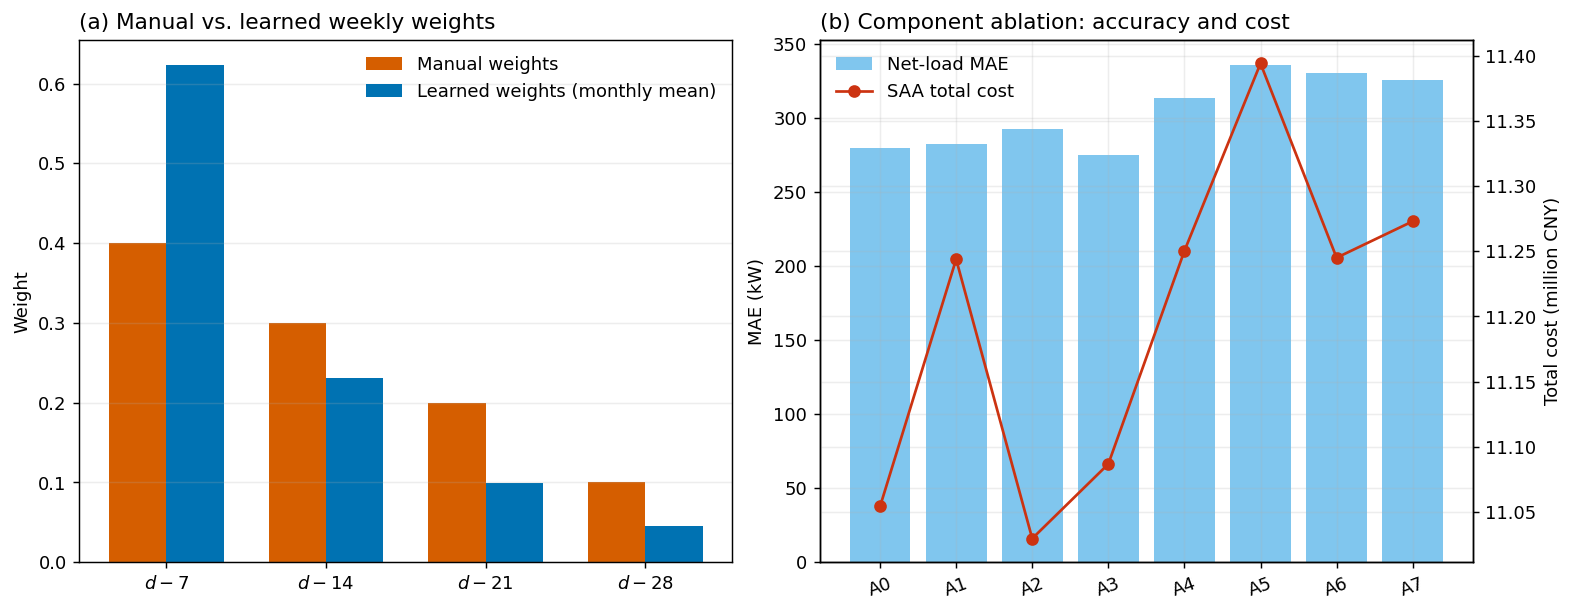

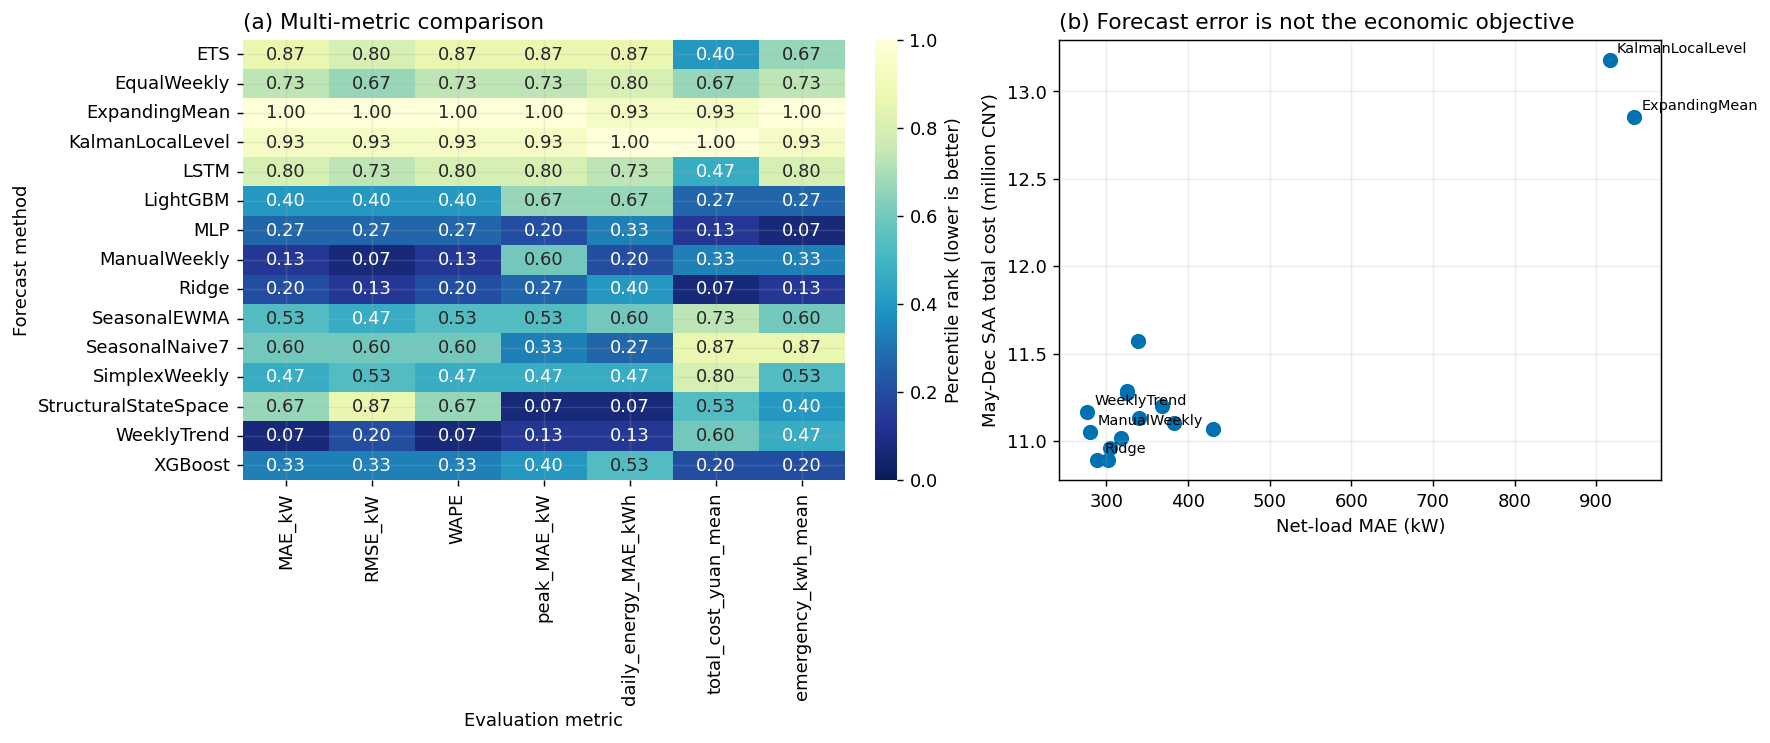

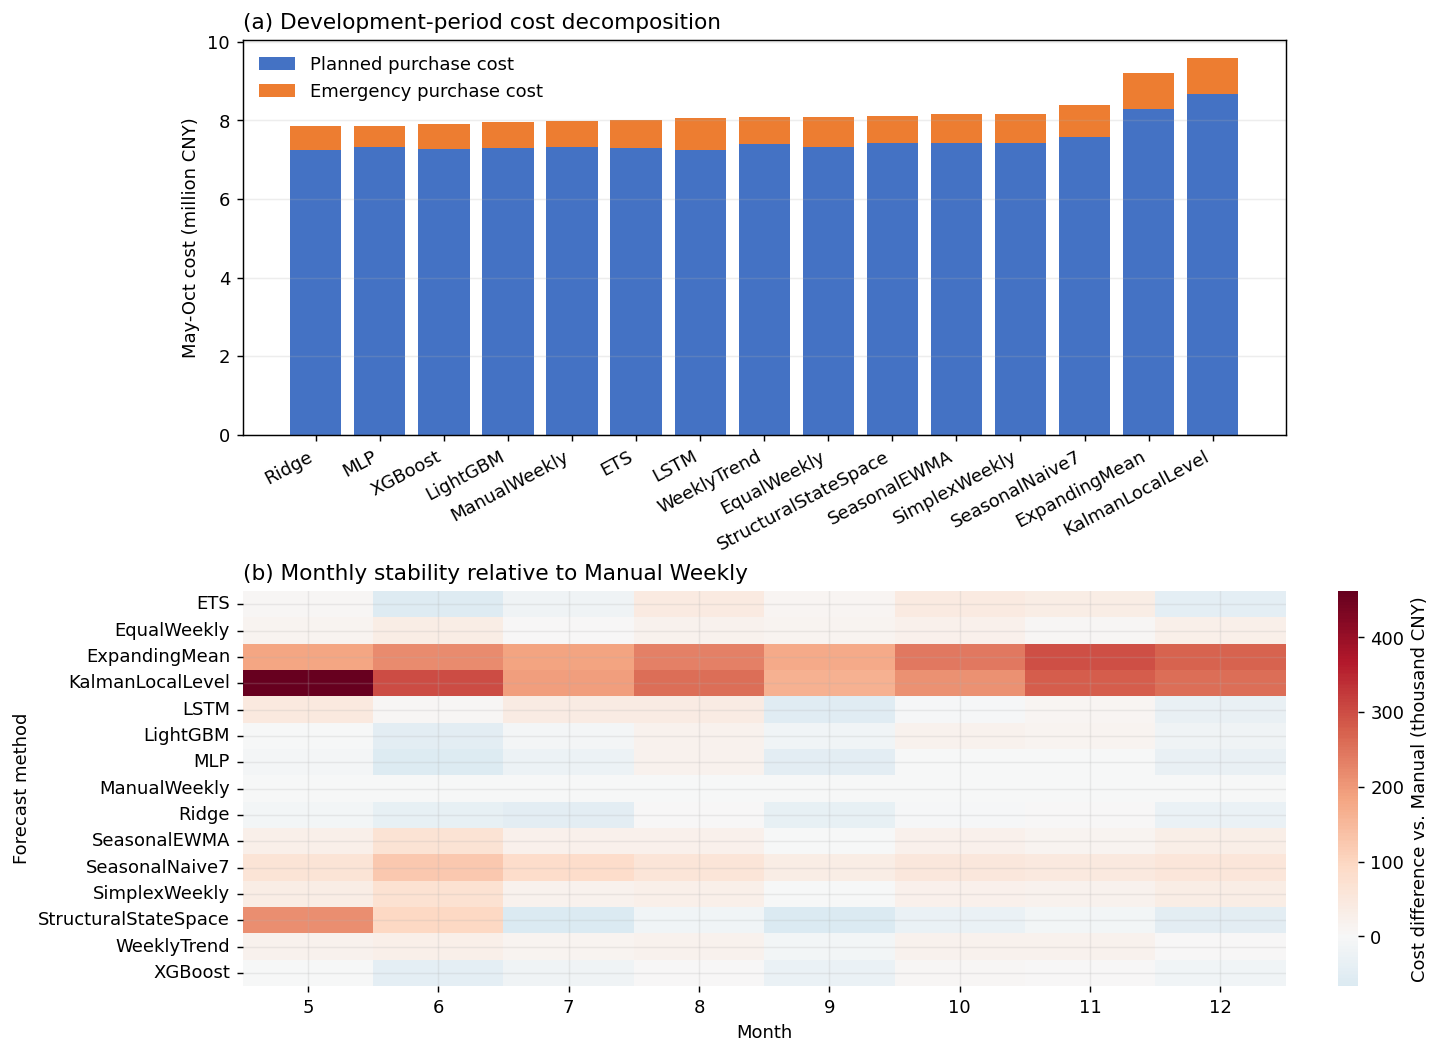

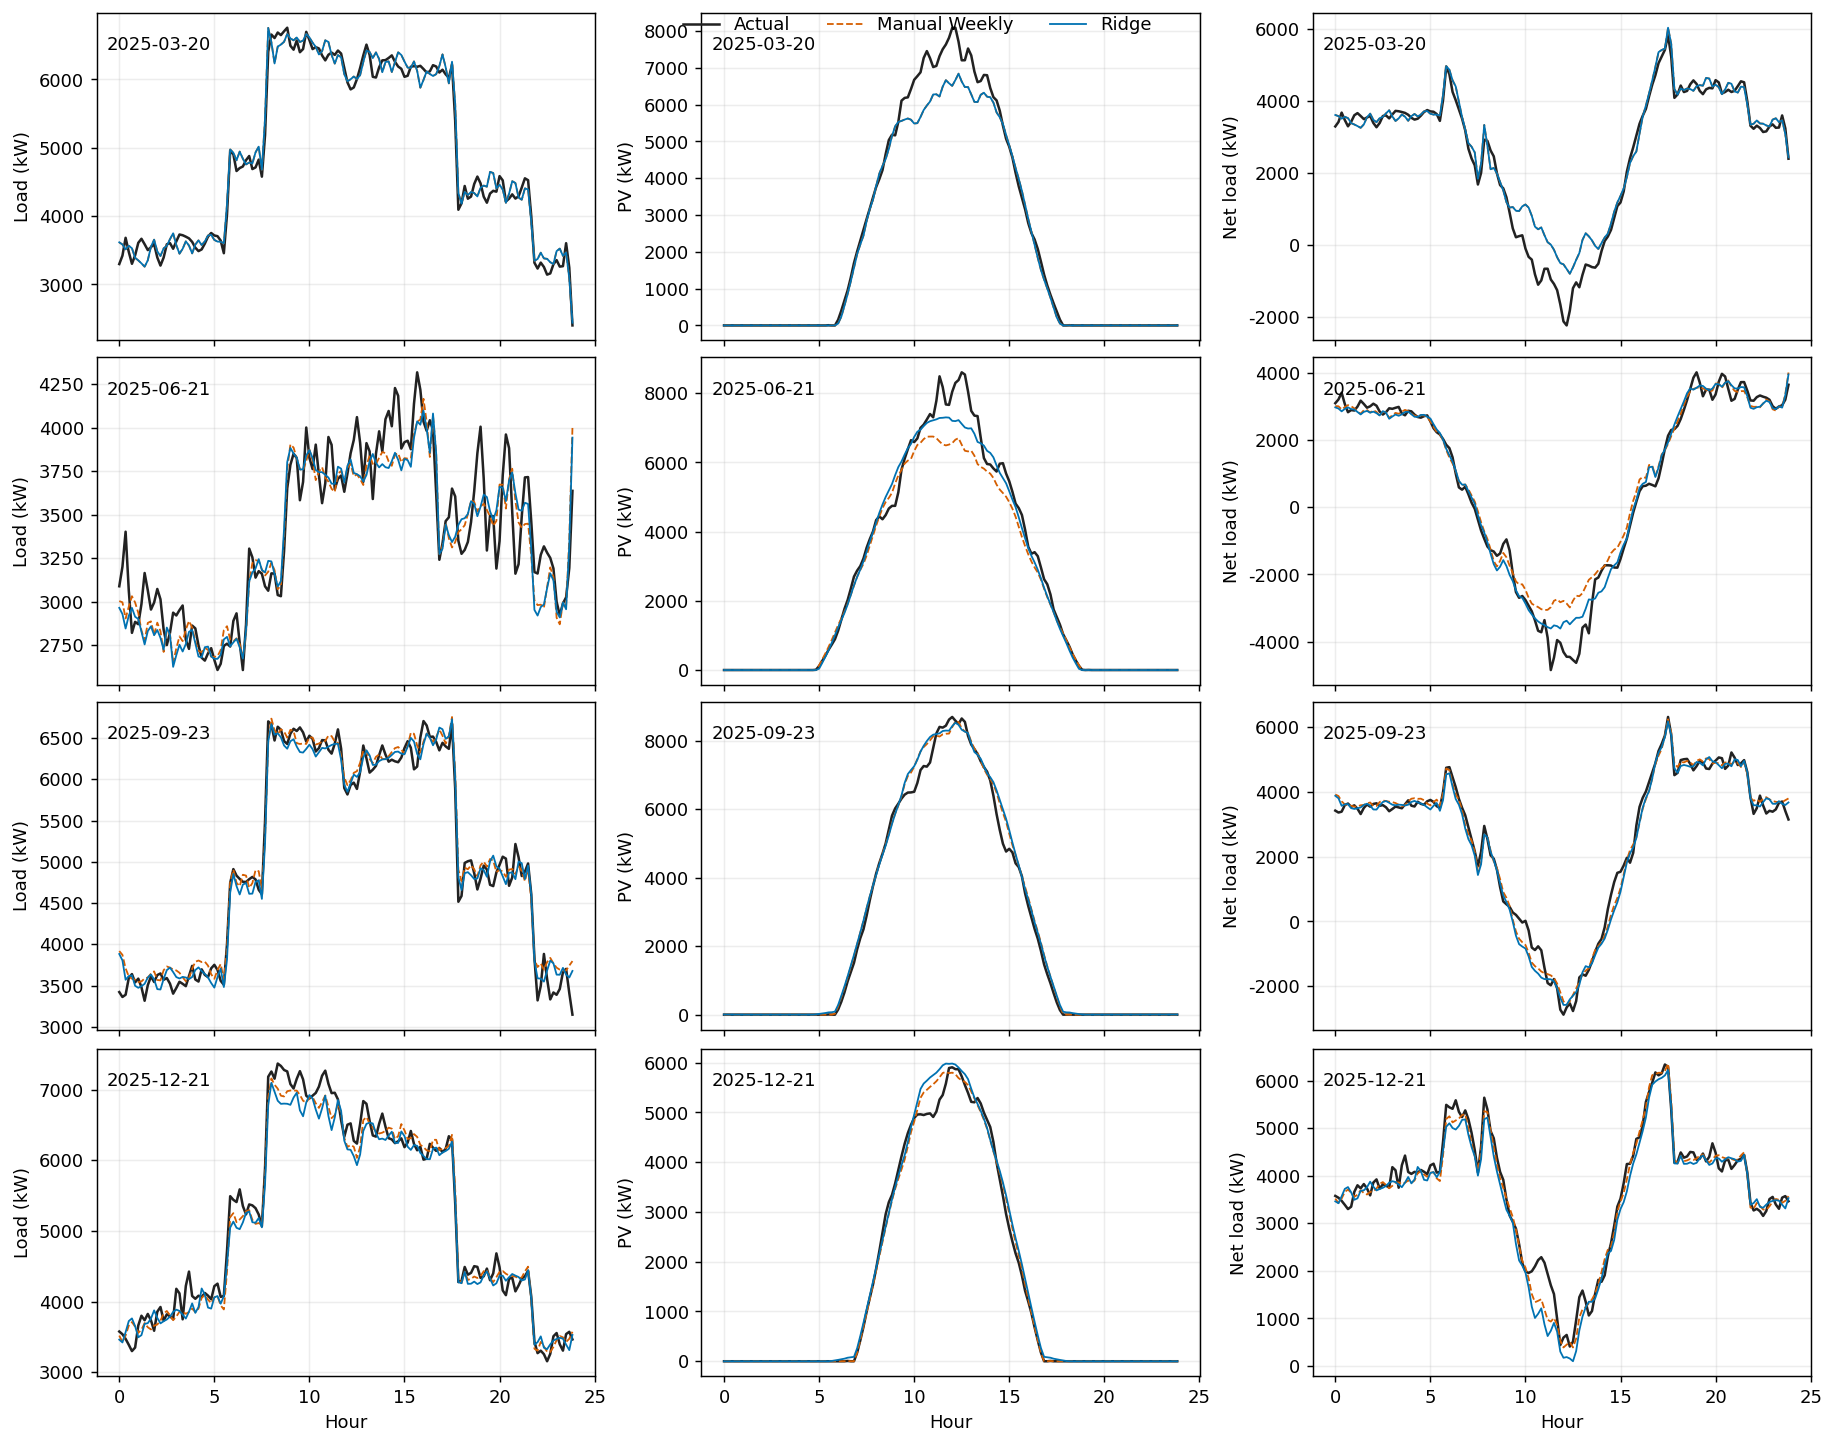

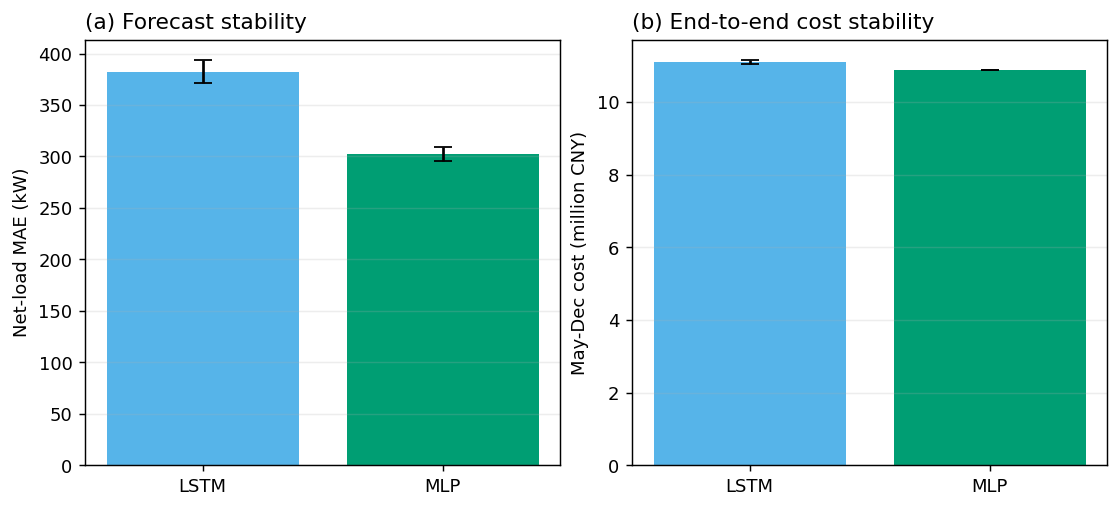

### 14.1 数据驱动结论

- 4—12 月净负荷 MAE 最低的方法为 **WeeklyTrend**；但模型是否推荐最终由规划成本决定。
- 5—10 月开发期成本最低候选为 **Ridge**。按预先规定的 bootstrap、0.1% 改善幅度和封存期规则，最终建议为 **Ridge**。
- 推荐方法开发期总成本为 7,851,644.95 元，Manual Weekly 为 7,986,314.50 元；11—12 月分别为 3,040,478.48 元和 3,068,058.23 元。
- 该结果再次说明：**MAE/RMSE 最低不必然等于端到端成本最低**。紧急购电具有 5 倍非对称惩罚，误差方向、发生时段和储能可补救性都会改变经济后果。
- 本轮仅完成预测端证据比较，正式 `result2.xlsx` 未被覆盖。统计模型原生期失败为 0 次；数值初值或优化器事件共 2 次，详细记录保存在 manifest 中。


Q2 预测端消融实验完成；正式 result2.xlsx 保持不变。


In [16]:
# ---------- 月度数据、论文图表、manifest 与数据驱动结论 ----------
cost_daily_ab['month']=cost_daily_ab.date.dt.month
monthly_ab=(cost_daily_ab.groupby(['method','seed','month'])
            [['planned_cost_yuan','emergency_cost_yuan','total_cost_yuan','emergency_kwh','spill_kwh']].sum().reset_index())
manual_month=monthly_ab[monthly_ab.method=='ManualWeekly'].set_index('month').total_cost_yuan
monthly_ab['cost_delta_vs_manual_yuan']=monthly_ab.apply(
    lambda r:r.total_cost_yuan-manual_month.loc[r.month],axis=1)
monthly_ab.to_csv(RESULT_DIR/'problem2_forecast_ablation_monthly.csv',index=False,encoding='utf-8-sig')

weights_df=pd.DataFrame(learned_weight_rows)
mechanism_methods=list(mechanism_pairs)
fm_common=forecast_metrics_ab[(forecast_metrics_ab.target=='net') &
                              (forecast_metrics_ab.period=='forecast_common_275')]
cs_common=aggregate_cost[aggregate_cost.period=='cost_common_245']

# 图 1：权重与组件消融
fig,axes=plt.subplots(1,2,figsize=(12,4.6),constrained_layout=True)
load_w=weights_df[weights_df.target=='load'][['w1','w2','w3','w4']].mean()
x=np.arange(4); width=.36
axes[0].bar(x-width/2,[.4,.3,.2,.1],width,label='Manual weights',color='#D55E00')
axes[0].bar(x+width/2,load_w,width,label='Learned weights (monthly mean)',color='#0072B2')
axes[0].set_xticks(x,[r'$d-7$',r'$d-14$',r'$d-21$',r'$d-28$']); axes[0].set_ylabel('Weight')
axes[0].set_title('(a) Manual vs. learned weekly weights',loc='left')
axes[0].legend(frameon=False); axes[0].grid(axis='x',visible=False)
mech_mae=fm_common[fm_common.method.isin(mechanism_methods)].set_index('method').MAE_kW
mech_cost=cs_common[cs_common.method.isin(mechanism_methods)].set_index('method').total_cost_yuan_mean/1e6
order=mechanism_methods; xx=np.arange(len(order))
ax2=axes[1].twinx(); axes[1].bar(xx,mech_mae.loc[order],color='#56B4E9',alpha=.75,label='Net-load MAE')
ax2.plot(xx,mech_cost.loc[order],color='#CC3311',marker='o',label='SAA total cost')
axes[1].set_xticks(xx,[s.split(' ',1)[0] for s in order],rotation=20); axes[1].set_ylabel('MAE (kW)'); ax2.set_ylabel('Total cost (million CNY)')
axes[1].set_title('(b) Component ablation: accuracy and cost',loc='left')
h1,l1=axes[1].get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels(); axes[1].legend(h1+h2,l1+l2,frameon=False,loc='upper left')
fig.savefig(FIG_DIR/'problem2_ablation_mechanism.pdf',bbox_inches='tight'); display(fig); plt.close(fig)

# 图 2：指标热力图与 MAE—成本关系
benchmark_methods=sorted(eligible)
fm_agg=(fm_common[fm_common.method.isin(benchmark_methods)].groupby('method')
        [['MAE_kW','RMSE_kW','WAPE','peak_MAE_kW','daily_energy_MAE_kWh']].mean())
best_forecast=fm_agg.MAE_kW.idxmin()
cc=cs_common[cs_common.method.isin(benchmark_methods)].groupby('method')[['total_cost_yuan_mean','emergency_kwh_mean']].mean()
heat=fm_agg.join(cc); heat_rank=heat.rank(pct=True)
fig,axes=plt.subplots(1,2,figsize=(13.5,5.6),constrained_layout=True)
sns.heatmap(heat_rank,ax=axes[0],cmap='YlGnBu_r',vmin=0,vmax=1,annot=True,fmt='.2f',cbar_kws={'label':'Percentile rank (lower is better)'})
axes[0].set_xlabel('Evaluation metric'); axes[0].set_ylabel('Forecast method'); axes[0].set_title('(a) Multi-metric comparison',loc='left')
plotx=fm_agg.MAE_kW; ploty=cc.total_cost_yuan_mean/1e6
axes[1].scatter(plotx,ploty,s=55,color='#0072B2')
highlights={'ManualWeekly','Ridge',best_forecast,'KalmanLocalLevel','ExpandingMean'}
for name in benchmark_methods:
    if name in highlights:
        axes[1].annotate(name,(plotx.loc[name],ploty.loc[name]),xytext=(4,4),textcoords='offset points',fontsize=8)
axes[1].set_xlabel('Net-load MAE (kW)'); axes[1].set_ylabel('May-Dec SAA total cost (million CNY)')
axes[1].set_title('(b) Forecast error is not the economic objective',loc='left')
fig.savefig(FIG_DIR/'problem2_ablation_benchmark.pdf',bbox_inches='tight'); display(fig); plt.close(fig)

# 图 3：开发期成本分解与月度差异
dev_plot=aggregate_cost[(aggregate_cost.period=='development_184') & aggregate_cost.method.isin(benchmark_methods)].sort_values('total_cost_yuan_mean')
fig,axes=plt.subplots(2,1,figsize=(11,8),constrained_layout=True)
xx=np.arange(len(dev_plot)); pc=dev_plot.planned_cost_yuan_mean.to_numpy()/1e6; ec=dev_plot.emergency_cost_yuan_mean.to_numpy()/1e6
axes[0].bar(xx,pc,label='Planned purchase cost',color='#4472C4'); axes[0].bar(xx,ec,bottom=pc,label='Emergency purchase cost',color='#ED7D31')
axes[0].set_xticks(xx,dev_plot.method,rotation=28,ha='right'); axes[0].set_ylabel('May-Oct cost (million CNY)'); axes[0].legend(frameon=False); axes[0].grid(axis='x',visible=False); axes[0].set_title('(a) Development-period cost decomposition',loc='left')
month_heat=(monthly_ab[(monthly_ab.month>=5)&monthly_ab.method.isin(benchmark_methods)]
    .groupby(['method','month']).cost_delta_vs_manual_yuan.mean().unstack()/1e3)
sns.heatmap(month_heat,ax=axes[1],center=0,cmap='RdBu_r',cbar_kws={'label':'Cost difference vs. Manual (thousand CNY)'})
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Forecast method'); axes[1].set_title('(b) Monthly stability relative to Manual Weekly',loc='left')
fig.savefig(FIG_DIR/'problem2_ablation_robustness.pdf',bbox_inches='tight'); display(fig); plt.close(fig)

# 图 4：指定四日实际值、Manual 与推荐模型
rec_preds=np.mean([run['net'] for (m,s),run in forecast_runs.items() if m==recommendation],axis=0)
rec_load=np.mean([run['load'] for (m,s),run in forecast_runs.items() if m==recommendation],axis=0)
rec_pv=np.mean([run['pv'] for (m,s),run in forecast_runs.items() if m==recommendation],axis=0)
man=forecast_runs[('ManualWeekly',0)]
fig,axes=plt.subplots(4,3,figsize=(14,11),sharex=True,constrained_layout=True)
hours=np.arange(T)/6
for i,date in enumerate(TARGET_DATES):
    d=int(np.flatnonzero(dates==date)[0])
    series=[(load[d],man['load'][d],rec_load[d],'Load (kW)'),
            (pv[d],man['pv'][d],rec_pv[d],'PV (kW)'),
            (actual_net[d],man['net'][d],rec_preds[d],'Net load (kW)')]
    for j,(truth,mf,rf,ylabel) in enumerate(series):
        ax=axes[i,j]; ax.plot(hours,truth,color='#222222',lw=1.4,label='Actual')
        ax.plot(hours,mf,color='#D55E00',ls='--',lw=1,label='Manual Weekly')
        ax.plot(hours,rf,color='#0072B2',lw=1,label=recommendation)
        ax.set_ylabel(ylabel); ax.text(.02,.93,str(date.date()),transform=ax.transAxes,va='top')
for ax in axes[-1]: ax.set_xlabel('Hour')
handles,labels=axes[0,0].get_legend_handles_labels(); fig.legend(handles,labels,ncol=3,loc='upper center',frameon=False)
fig.savefig(FIG_DIR/'problem2_ablation_selected_days.pdf',bbox_inches='tight'); display(fig); plt.close(fig)

# 图 5：MLP/LSTM 随机种子稳定性
seed_methods=['MLP','LSTM']; seed_metric=fm_common[fm_common.method.isin(seed_methods)].groupby('method').MAE_kW.agg(['mean','std'])
seed_cost=cost_summary_ab[(cost_summary_ab.period=='cost_common_245') & cost_summary_ab.method.isin(seed_methods)].groupby('method').total_cost_yuan.agg(['mean','std'])
fig,axes=plt.subplots(1,2,figsize=(8.5,3.8),constrained_layout=True)
axes[0].bar(seed_metric.index,seed_metric['mean'],yerr=seed_metric['std'],capsize=5,color=['#56B4E9','#009E73']); axes[0].set_ylabel('Net-load MAE (kW)'); axes[0].set_title('(a) Forecast stability',loc='left')
axes[1].bar(seed_cost.index,seed_cost['mean']/1e6,yerr=seed_cost['std']/1e6,capsize=5,color=['#56B4E9','#009E73']); axes[1].set_ylabel('May-Dec cost (million CNY)'); axes[1].set_title('(b) End-to-end cost stability',loc='left')
for ax in axes: ax.grid(axis='x',visible=False)
fig.savefig(FIG_DIR/'problem2_ablation_seed_stability.pdf',bbox_inches='tight'); display(fig); plt.close(fig)

manifest={
    'experiment':'Q2 forecast-side ablation with unchanged SAA planner','generated_at':pd.Timestamp.now().isoformat(),
    'periods':{k:[str(dates[v[0]].date()),str(dates[v[-1]].date()),len(v)] for k,v in period_days.items()},
    'fixed_planner':{'window_days':AB_WINDOW,'rho':AB_RHO,'cyclic_soc_kwh':AB_SOC,'emergency_multiplier':EMERGENCY_MULTIPLIER},
    'current_regression':{'MAE_kW':forecast_metrics['MAE_kW'],'RMSE_kW':forecast_metrics['RMSE_kW'],'SAA_total_cost_yuan':existing_saa},
    'development_candidate':candidate.method,'recommended_method':recommendation,'replacement_accepted':bool(improves),
    'model_failures':model_failures,'model_numerical_events':model_numerical_events,
    'planning_checks_max':max_checks.to_dict(),'planning_checks_min':min_checks.to_dict(),
    'official_result2_overwritten':False,
}
with open(RESULT_DIR/'problem2_forecast_ablation_manifest.json','w',encoding='utf-8') as f:
    json.dump(manifest,f,ensure_ascii=False,indent=2,default=str)

rec_dev=float(dev.set_index('method').loc[recommendation,'total_cost_yuan_mean'])
man_dev=float(dev.set_index('method').loc['ManualWeekly','total_cost_yuan_mean'])
rec_hold=float(hold.loc[recommendation,'total_cost_yuan_mean']); man_hold=float(hold.loc['ManualWeekly','total_cost_yuan_mean'])
best_forecast=fm_agg.MAE_kW.idxmin()
conclusion=f'''### 14.1 数据驱动结论

- 4—12 月净负荷 MAE 最低的方法为 **{best_forecast}**；但模型是否推荐最终由规划成本决定。
- 5—10 月开发期成本最低候选为 **{candidate.method}**。按预先规定的 bootstrap、0.1% 改善幅度和封存期规则，最终建议为 **{recommendation}**。
- 推荐方法开发期总成本为 {rec_dev:,.2f} 元，Manual Weekly 为 {man_dev:,.2f} 元；11—12 月分别为 {rec_hold:,.2f} 元和 {man_hold:,.2f} 元。
- 该结果再次说明：**MAE/RMSE 最低不必然等于端到端成本最低**。紧急购电具有 5 倍非对称惩罚，误差方向、发生时段和储能可补救性都会改变经济后果。
- 本轮仅完成预测端证据比较，正式 `result2.xlsx` 未被覆盖。统计模型原生期失败为 {len(model_failures)} 次；数值初值或优化器事件共 {len(model_numerical_events)} 次，详细记录保存在 manifest 中。
'''
display(Markdown(conclusion))
print('Q2 预测端消融实验完成；正式 result2.xlsx 保持不变。')


## 15. 全量实验结果、逐模型解释与最终选择

本节不再训练模型，而是读取前文已经由 Colab 实际产生的 CSV/JSON 结果，完成可复核的集中汇报。这样做有两个目的：第一，避免正文结论只展示少数“好看”的数字；第二，把预测精度、经济代价、稳定性和约束可行性放进同一证据链。

本节采用以下展示层级：

1. **运行级结果**：28 次预测运行、68 组超参数验证结果和逐月学习权重；
2. **预测级结果**：24 个方法/消融项、3 个预测对象、4 个评价期间，共 336 行指标；
3. **规划级结果**：28 次预测运行在 4 个期间上的 112 行成本结果，以及按随机种子汇总后的 96 行结果；
4. **稳健性结果**：308 行月度结果、23 组移动块 Bootstrap 置信区间；
5. **可行性结果**：9,352 个“模型—种子—日期”规划问题的逐日约束检查；
6. **明细数据**：4,040,064 行逐时预测和 9,352 行逐日成本保存在 `results/`，本节核验行数但不把数百万行直接渲染到页面，以避免浏览器失去响应。

评价方向需要特别注意：MAE、RMSE、WAPE、MASE、峰值 MAE、电价加权 MAE、日总电量误差、爬坡误差和总成本均为**越小越好**；$R^2$ 为越大越好；Bias 定义为“实际值减预测值”，正值表示整体偏低估。最终模型选择以固定 SAA 规划器下的端到端成本为主，而不是以某一个误差指标为主。


In [17]:
# 15.1 读取全部结果并核对文件完整性
from pathlib import Path
import gzip, json
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

DETAIL_RESULT_DIR = RESULT_DIR if 'RESULT_DIR' in globals() else Path.cwd()/'results'

def read_result(name):
    return pd.read_csv(DETAIL_RESULT_DIR/f'problem2_forecast_ablation_{name}.csv')

forecast_metrics_detail = read_result('metrics')
cost_detail = read_result('cost')
cost_agg_detail = read_result('cost_aggregated')
daily_cost_detail = read_result('daily_cost')
monthly_detail = read_result('monthly')
planning_detail = read_result('planning_checks')
bootstrap_detail = read_result('bootstrap')
weights_detail = read_result('weights')
tuning_detail = read_result('tuning')
with open(DETAIL_RESULT_DIR/'problem2_forecast_ablation_runs.json',encoding='utf-8') as f:
    run_meta_detail = pd.DataFrame(json.load(f))
with open(DETAIL_RESULT_DIR/'problem2_forecast_ablation_manifest.json',encoding='utf-8') as f:
    manifest_detail = json.load(f)

def show_scroll(df, title, height=420, digits=4):
    shown=df.copy()
    numeric=shown.select_dtypes(include=np.number).columns
    shown[numeric]=shown[numeric].round(digits)
    html=(f'<h4>{title}</h4><div style="max-height:{height}px;overflow:auto;'
          'border:1px solid #ddd;padding:4px">'+shown.to_html(index=False)+' </div>')
    display(HTML(html))

prediction_path=DETAIL_RESULT_DIR/'problem2_forecast_ablation_predictions.csv.gz'
with gzip.open(prediction_path,'rt',encoding='utf-8-sig') as f:
    prediction_columns=f.readline().strip().split(',')
    prediction_rows=sum(1 for _ in f)

integrity=pd.DataFrame({
    '结果对象':['预测运行','超参数候选','学习权重','预测指标','模型期间成本','种子汇总成本',
              '逐日成本','月度结果','Bootstrap','逐日规划检查','逐时预测'],
    '实际行数':[len(run_meta_detail),len(tuning_detail),len(weights_detail),len(forecast_metrics_detail),
              len(cost_detail),len(cost_agg_detail),len(daily_cost_detail),len(monthly_detail),
              len(bootstrap_detail),len(planning_detail),prediction_rows],
    '预期行数':[28,68,20,336,112,96,9352,308,23,9352,4040064]
})
integrity['检查通过']=integrity['实际行数']==integrity['预期行数']
assert integrity['检查通过'].all()
assert manifest_detail['model_failures']==[]
display(integrity)
show_scroll(run_meta_detail.fillna('—'),'表15-1　28次预测运行及其配置',360)
print('逐时预测字段：',prediction_columns)


,结果对象,实际行数,预期行数,检查通过
0,预测运行,28,28,True
1,超参数候选,68,68,True
2,学习权重,20,20,True
3,预测指标,336,336,True
4,模型期间成本,112,112,True
5,种子汇总成本,96,96,True
6,逐日成本,9352,9352,True
7,月度结果,308,308,True
8,Bootstrap,23,23,True
9,逐日规划检查,9352,9352,True


method,seed,category,fallback_days,native_start,load_cfg,pv_cfg,fit_seconds
Attachment1Static,0,reference,59,2025-04-01,—,—,—
ExpandingMean,0,benchmark,59,2025-04-01,—,—,—
SeasonalNaive7,0,benchmark,59,2025-04-01,—,—,—
ManualWeekly,0,benchmark,59,2025-04-01,—,—,—
EqualWeekly,0,benchmark,59,2025-04-01,—,—,—
SimplexWeekly,0,benchmark,59,2025-04-01,—,—,—
WeeklyTrend,0,benchmark,59,2025-04-01,"{'alpha': 0.75, 'validation_MAE': 114.9032351046}","{'alpha': 1.0, 'validation_MAE': 174.0165797673}",—
SeasonalEWMA,0,benchmark,59,2025-04-01,"{'lambda': 0.4, 'validation_MAE': 129.4112219401}","{'lambda': 0.4, 'validation_MAE': 220.3553693865}",—
A0 原人工权重+PV-MA7,0,mechanism,59,2025-04-01,—,—,—
A1 负荷Lag7,0,mechanism,59,2025-04-01,—,—,—


逐时预测字段： ['method', 'target', 'date', 'slot', 'y_true', 'y_pred', 'seed', 'is_fallback', 'fit_origin', 'fit_seconds']


### 15.2 超参数选择与学习权重

所有超参数只能使用 2025 年 3 月验证集选择。树模型、Ridge、MLP 和 LSTM 的训练预处理器均只在训练期拟合。状态空间模型不存在从候选网格中“挑最好结果”的步骤，而是按月用当时已经观测的数据重新估计。

下表完整保留全部 68 次超参数验证，不只报告最终选中的一行。`best_iteration` 是 LightGBM/XGBoost 早停得到的树数；`epochs` 和 `internal_val_loss` 对应 LSTM。空白表示该字段不适用于相应模型。


In [18]:
# 15.2.1 展示全部超参数、胜出配置和逐月学习权重
tuning_sorted=tuning_detail.sort_values(['model','target','validation_MAE'],na_position='last')
show_scroll(tuning_sorted,'表15-2　全部68组超参数验证结果',520,6)

finite_tuning=tuning_detail[np.isfinite(tuning_detail.validation_MAE)].copy()
best_idx=finite_tuning.groupby(['model','target']).validation_MAE.idxmin()
best_tuning=finite_tuning.loc[best_idx].sort_values(['model','target'])
display(best_tuning[['model','target','parameter','validation_MAE','best_iteration','epochs']]
        .rename(columns={'model':'模型','target':'对象','parameter':'选中参数',
                         'validation_MAE':'3月验证MAE','best_iteration':'最优迭代数','epochs':'训练轮数'}))

show_scroll(weights_detail.sort_values(['target','fit_origin']),
            '表15-3　Simplex Weekly逐月学习权重',420,6)
mean_weights=weights_detail.groupby('target')[['w1','w2','w3','w4']].mean()
display(mean_weights.rename(index={'load':'负荷','pv':'光伏'}).rename(
    columns={'w1':'d-7','w2':'d-14','w3':'d-21','w4':'d-28'}))

def chosen(model,target):
    q=best_tuning[(best_tuning.model==model)&(best_tuning.target==target)]
    return q.iloc[0] if len(q) else None

load_w=mean_weights.loc['load']; pv_w=mean_weights.loc['pv']
parameter_text=f'''#### 参数结果解释

- **Seasonal EWMA**：负荷与光伏均在 $\lambda\in\{{0.4,0.6,0.8,0.9\}}$ 中选到 $\lambda=0.4$。因为实现中的最近一周权重为 1、更早星期按 $\lambda^j$ 衰减，$\lambda=0.4$ 表示验证集更偏好快速遗忘。
- **Weekly+Trend**：负荷选到 $\alpha=0.75$，光伏选到 $\alpha=1.0$，说明 3 月验证集支持对近期残差进行较强修正。
- **Ridge**：负荷选到 $\alpha={json.loads(chosen('Ridge','load').parameter)['alpha']}$，光伏选到 $\alpha={json.loads(chosen('Ridge','pv').parameter)['alpha']}$。
- **LightGBM**：负荷和光伏均选 `num_leaves=15, min_child_samples=50`；早停树数分别为 {int(chosen('LightGBM','load').best_iteration)} 和 {int(chosen('LightGBM','pv').best_iteration)}。
- **XGBoost**：负荷和光伏均选 `max_depth=3, min_child_weight=5`；早停树数分别为 {int(chosen('XGBoost','load').best_iteration)} 和 {int(chosen('XGBoost','pv').best_iteration)}。
- **MLP**：负荷选两层 `(128,64)`、正则 $10^{{-4}}$；光伏选两层 `(128,64)`、正则 $10^{{-3}}$。
- **LSTM**：负荷选择 14 天输入、隐藏维度 32；光伏选择 28 天输入、隐藏维度 64。
- **学习权重**：负荷月均权重为 $({load_w.w1:.4f},{load_w.w2:.4f},{load_w.w3:.4f},{load_w.w4:.4f})$，光伏月均权重为 $({pv_w.w1:.4f},{pv_w.w2:.4f},{pv_w.w3:.4f},{pv_w.w4:.4f})$。最近一周权重明显高于人工设定的 0.4，第四周信息贡献很小。
'''
display(Markdown(parameter_text))


<>:25: SyntaxWarning: invalid escape sequence '\{'
<>:25: SyntaxWarning: invalid escape sequence '\}'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\{'
<>:25: SyntaxWarning: invalid escape sequence '\}'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2532/3346883544.py:25: SyntaxWarning: invalid escape sequence '\{'
  - **Seasonal EWMA**：负荷与光伏均在 $\lambda\in\{{0.4,0.6,0.8,0.9\}}$ 中选到 $\lambda=0.4$。因为实现中的最近一周权重为 1、更早星期按 $\lambda^j$ 衰减，$\lambda=0.4$ 表示验证集更偏好快速遗忘。
/tmp/ipykernel_2532/3346883544.py:25: SyntaxWarning: invalid escape sequence '\}'
  - **Seasonal EWMA**：负荷与光伏均在 $\lambda\in\{{0.4,0.6,0.8,0.9\}}$ 中选到 $\lambda=0.4$。因为实现中的最近一周权重为 1、更早星期按 $\lambda^j$ 衰减，$\lambda=0.4$ 表示验证集更偏好快速遗忘。
/tmp/ipykernel_2532/3346883544.py:35: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2532/3346883544.py:33: SyntaxWarning:

model,target,parameter,validation_MAE,fit_seconds,best_iteration,epochs,internal_val_loss
ETS,load,trend=add,171.786108,NaN,NaN,NaN,NaN
ETS,load,trend=None,172.138767,NaN,NaN,NaN,NaN
ETS,pv,trend=None,242.407611,NaN,NaN,NaN,NaN
ETS,pv,trend=add,319.428992,NaN,NaN,NaN,NaN
LSTM,load,"{""lookback"": 14, ""hidden"": 32}",245.722067,8.014949,NaN,102.0,0.022576
LSTM,load,"{""lookback"": 14, ""hidden"": 64}",253.427660,1.050703,NaN,93.0,0.024292
LSTM,load,"{""lookback"": 28, ""hidden"": 64}",259.865910,0.492772,NaN,56.0,0.020347
LSTM,load,"{""lookback"": 28, ""hidden"": 32}",306.618826,0.700953,NaN,82.0,0.019398
LSTM,pv,"{""lookback"": 28, ""hidden"": 64}",342.405569,0.230904,NaN,23.0,0.376324
LSTM,pv,"{""lookback"": 14, ""hidden"": 64}",412.876879,0.301937,NaN,24.0,0.296179


,模型,对象,选中参数,3月验证MAE,最优迭代数,训练轮数
19,ETS,load,trend=add,171.786108,NaN,NaN
21,ETS,pv,trend=None,242.407611,NaN,NaN
60,LSTM,load,"{""lookback"": 14, ""hidden"": 32}",245.722067,NaN,102.0
67,LSTM,pv,"{""lookback"": 28, ""hidden"": 64}",342.405569,NaN,23.0
37,LightGBM,load,"{""num_leaves"": 15, ""min_child_samples"": 50}",123.042803,162.0,NaN
41,LightGBM,pv,"{""num_leaves"": 15, ""min_child_samples"": 50}",167.264199,223.0,NaN
54,MLP,load,"{""hidden_layer_sizes"": [128, 64], ""alpha"": 0.0...",364.619847,NaN,NaN
59,MLP,pv,"{""hidden_layer_sizes"": [128, 64], ""alpha"": 0.001}",238.923933,NaN,NaN
31,Ridge,load,"{""alpha"": 100.0}",156.465896,NaN,NaN
34,Ridge,pv,"{""alpha"": 10.0}",180.074130,NaN,NaN


target,fit_origin,w1,w2,w3,w4
load,2025-03-01,0.624519,0.281242,0.094238,0.000000
load,2025-04-01,0.609424,0.288222,0.101896,0.000458
load,2025-05-01,0.540116,0.291615,0.131949,0.036320
load,2025-06-01,0.531507,0.269956,0.138399,0.060137
load,2025-07-01,0.591363,0.222607,0.106458,0.079571
load,2025-08-01,0.642229,0.181375,0.081302,0.095095
load,2025-09-01,0.617524,0.195079,0.101862,0.085535
load,2025-10-01,0.699952,0.188808,0.078562,0.032678
load,2025-11-01,0.696886,0.190855,0.080340,0.031919
load,2025-12-01,0.684363,0.197989,0.082609,0.035039


,d-7,d-14,d-21,d-28
target,,,,
负荷,0.623788,0.230775,0.099762,0.045675
光伏,0.671103,0.243301,0.042128,0.043467


#### 参数结果解释

- **Seasonal EWMA**：负荷与光伏均在 $\lambda\in\{0.4,0.6,0.8,0.9\}$ 中选到 $\lambda=0.4$。因为实现中的最近一周权重为 1、更早星期按 $\lambda^j$ 衰减，$\lambda=0.4$ 表示验证集更偏好快速遗忘。
- **Weekly+Trend**：负荷选到 $lpha=0.75$，光伏选到 $lpha=1.0$，说明 3 月验证集支持对近期残差进行较强修正。
- **Ridge**：负荷选到 $lpha=100.0$，光伏选到 $lpha=10.0$。
- **LightGBM**：负荷和光伏均选 `num_leaves=15, min_child_samples=50`；早停树数分别为 162 和 223。
- **XGBoost**：负荷和光伏均选 `max_depth=3, min_child_weight=5`；早停树数分别为 182 和 286。
- **MLP**：负荷选两层 `(128,64)`、正则 $10^{-4}$；光伏选两层 `(128,64)`、正则 $10^{-3}$。
- **LSTM**：负荷选择 14 天输入、隐藏维度 32；光伏选择 28 天输入、隐藏维度 64。
- **学习权重**：负荷月均权重为 $(0.6238,0.2308,0.0998,0.0457)$，光伏月均权重为 $(0.6711,0.2433,0.0421,0.0435)$。最近一周权重明显高于人工设定的 0.4，第四周信息贡献很小。


### 15.3 全部预测结果

`表15-4` 内嵌全部 336 行预测结果，覆盖：

- `load / pv / net` 三个对象；
- `full_334 / forecast_common_275 / development_184 / holdout_61` 四个期间；
- MAE、RMSE、WAPE、MASE、$R^2$、Bias、低估频率、峰值 MAE、电价加权 MAE、日总电量误差和爬坡误差。

为避免随机模型通过挑选最好种子获利，主比较表对 MLP/LSTM 三个随机种子取均值。附件1静态典型日仅作为参考，不参与优胜模型选择；A0—A7 是机制消融，也不与完整候选模型混在一起选优。


In [19]:
# 15.3.1 全量预测指标、主表、消融表和随机种子表
show_scroll(forecast_metrics_detail.sort_values(['period','target','method','seed']),
            '表15-4　全部336行预测评价结果',600,6)

benchmark_methods=sorted(set(run_meta_detail.loc[
    run_meta_detail.category.eq('benchmark'),'method'])-{'Attachment1Static'})
mechanism_methods=sorted(run_meta_detail.loc[
    run_meta_detail.category.eq('mechanism'),'method'].unique())
common_net=forecast_metrics_detail[(forecast_metrics_detail.target=='net') &
    (forecast_metrics_detail.period=='forecast_common_275')]
forecast_primary=(common_net[common_net.method.isin(benchmark_methods)]
    .groupby('method').agg(MAE_kW=('MAE_kW','mean'),RMSE_kW=('RMSE_kW','mean'),
    WAPE=('WAPE','mean'),MASE=('MASE','mean'),R2=('R2','mean'),
    Bias_kW=('bias_actual_minus_forecast_kW','mean'),
    underestimate_frequency=('underestimate_frequency','mean'),
    peak_MAE_kW=('peak_MAE_kW','mean'),price_weighted_MAE_kW=('price_weighted_MAE_kW','mean'),
    daily_energy_MAE_kWh=('daily_energy_MAE_kWh','mean'),ramp_MAE_kW=('ramp_MAE_kW','mean'))
    .sort_values('MAE_kW'))
display(forecast_primary.reset_index().rename(columns={'method':'模型'}).round(4))

mechanism_forecast=(common_net[common_net.method.isin(mechanism_methods)]
    [['method','MAE_kW','RMSE_kW','WAPE','bias_actual_minus_forecast_kW',
      'peak_MAE_kW','price_weighted_MAE_kW','daily_energy_MAE_kWh','ramp_MAE_kW']]
    .sort_values('method'))
display(mechanism_forecast.round(4))

seed_forecast=common_net[common_net.method.isin(['MLP','LSTM'])][
    ['method','seed','MAE_kW','RMSE_kW','WAPE','R2','bias_actual_minus_forecast_kW']]
display(seed_forecast.sort_values(['method','seed']).round(4))

explanations={
  'ManualWeekly':'人工四周递减负荷权重与光伏7日均值，是现有基准。',
  'WeeklyTrend':'完整模型中MAE最低，但近期残差修正改变了误差方向，未转化为成本优势。',
  'Ridge':'MAE不是最低，但误差结构与计划购电、储能缓冲更匹配。',
  'MLP':'三个种子存在波动；平均精度不及Ridge，但紧急购电费较低。',
  'XGBoost':'精度和成本均优于原方案，但经济收益低于Ridge/MLP。',
  'LightGBM':'相对原方案只有较小成本改善，Bootstrap区间跨0。',
  'EqualWeekly':'等权四周造成明显精度与成本退化。',
  'SimplexWeekly':'数据学习权重改善部分预测机制，但单独使用不能保证经济性。',
  'SeasonalEWMA':'快速遗忘的周季节平滑仍难跟踪全年结构变化。',
  'SeasonalNaive7':'只复制上周同日，无法处理趋势和异常天气。',
  'ETS':'能表达趋势和周季节，但日曲线主成分上的误差仍偏大。',
  'StructuralStateSpace':'局部线性趋势、周季节和AR(1)结构在封存期较好，但跨季节不稳定。',
  'KalmanLocalLevel':'局部水平随机游走过于简单，无法描述台阶负荷和周周期。',
  'ExpandingMean':'长期均值抹平季节变化，仅适合作为弱基准。',
  'LSTM':'一年样本对深度时序模型偏少，多种子精度和稳定性均未超过浅层模型。'
}
lines=['#### 逐模型预测结果解释']
for method,row in forecast_primary.iterrows():
    lines.append(f'- **{method}**：MAE={row.MAE_kW:.2f} kW，RMSE={row.RMSE_kW:.2f} kW，'
                 f'WAPE={row.WAPE:.4f}，$R^2$={row.R2:.4f}，Bias={row.Bias_kW:.2f} kW。'
                 f'{explanations[method]}')
display(Markdown('\n'.join(lines)))


method,seed,target,period,MAE_kW,RMSE_kW,WAPE,MASE,R2,bias_actual_minus_forecast_kW,underestimate_frequency,peak_MAE_kW,price_weighted_MAE_kW,daily_energy_MAE_kWh,ramp_MAE_kW
A0 原人工权重+PV-MA7,0,load,development_184,208.172183,287.638330,0.043868,1.023179,0.957556,0.098514,0.477883,251.199039,213.663785,3425.762958,126.514244
A1 负荷Lag7,0,load,development_184,203.456364,282.553299,0.042874,1.000000,0.959044,0.065450,0.484601,251.210847,206.767726,2145.133832,157.387889
A2 负荷四周等权,0,load,development_184,229.191771,311.285551,0.048298,1.126491,0.950291,0.133998,0.482073,271.446052,235.908739,4235.086371,124.118465
A3 负荷学习权重,0,load,development_184,197.328270,275.162662,0.041583,0.969880,0.961158,2.476699,0.483884,241.881100,201.737426,2860.295367,132.914481
A4 光伏Lag1,0,load,development_184,208.172183,287.638330,0.043868,1.023179,0.957556,0.098514,0.477883,251.199039,213.663785,3425.762958,126.514244
A5 光伏Lag7,0,load,development_184,208.172183,287.638330,0.043868,1.023179,0.957556,0.098514,0.477883,251.199039,213.663785,3425.762958,126.514244
A6 光伏SeasonalEWMA,0,load,development_184,208.172183,287.638330,0.043868,1.023179,0.957556,0.098514,0.477883,251.199039,213.663785,3425.762958,126.514244
A7 学习负荷+EWMA光伏,0,load,development_184,197.328270,275.162662,0.041583,0.969880,0.961158,2.476699,0.483884,241.881100,201.737426,2860.295367,132.914481
Attachment1Static,0,load,development_184,848.791417,1051.170636,0.178866,4.171860,0.433153,119.366402,0.685009,1335.353675,922.236403,19987.425286,129.652963
ETS,0,load,development_184,325.421671,420.387902,0.068576,1.599467,0.909339,52.733097,0.536421,417.040209,340.598201,7086.653144,113.075621


,模型,MAE_kW,RMSE_kW,WAPE,MASE,R2,Bias_kW,underestimate_frequency,peak_MAE_kW,price_weighted_MAE_kW,daily_energy_MAE_kWh,ramp_MAE_kW
0,WeeklyTrend,276.1422,412.9207,0.0913,0.8145,0.9732,7.7569,0.5030,202.9043,281.3711,3142.9086,156.2766
1,ManualWeekly,280.1658,399.1767,0.0926,0.8264,0.9749,28.8479,0.5284,262.7414,285.9761,3671.4536,143.9252
2,Ridge,288.8770,408.3419,0.0955,0.8520,0.9738,69.1487,0.5980,243.3107,293.5639,4392.5325,143.8424
3,MLP,302.3829,434.5868,0.0999,0.8919,0.9703,114.4650,0.6234,220.9987,305.8439,4286.1663,143.2978
4,XGBoost,304.9098,440.9486,0.1008,0.8993,0.9694,70.2335,0.5980,257.4068,309.0317,4566.7631,148.8334
5,LightGBM,317.5693,455.4351,0.1050,0.9367,0.9674,74.4519,0.5969,298.2038,323.7651,4685.9515,150.0203
6,SimplexWeekly,325.0917,474.2523,0.1074,0.9589,0.9646,54.0806,0.5449,260.8274,333.4909,4547.6646,156.6023
7,SeasonalEWMA,325.6091,473.0226,0.1076,0.9604,0.9648,51.0812,0.5414,261.8704,334.2449,4615.0942,154.5103
8,SeasonalNaive7,339.0380,501.2642,0.1120,1.0000,0.9604,32.9208,0.5216,250.7547,346.7918,4263.1819,182.9124
9,StructuralStateSpace,340.4823,745.0527,0.1125,1.0043,0.9126,2.3089,0.5247,182.3735,344.9655,2437.8768,178.3993


,method,MAE_kW,RMSE_kW,WAPE,bias_actual_minus_forecast_kW,peak_MAE_kW,price_weighted_MAE_kW,daily_energy_MAE_kWh,ramp_MAE_kW
105,A0 原人工权重+PV-MA7,280.1658,399.1767,0.0926,28.8479,262.7414,285.9761,3671.4536,143.9252
117,A1 负荷Lag7,282.4111,401.7544,0.0933,21.8249,242.8331,286.8190,3246.0447,169.7978
129,A2 负荷四周等权,292.6959,410.9685,0.0967,32.3755,292.6891,299.1396,4114.4281,141.7769
141,A3 负荷学习权重,274.8156,394.1023,0.0908,26.7392,245.0309,280.0233,3370.3854,150.1858
153,A4 光伏Lag1,313.7212,459.9131,0.1037,17.1994,263.7582,319.6076,3748.9700,155.9287
165,A5 光伏Lag7,336.2062,497.7819,0.1111,39.9437,270.4382,345.1991,4501.9119,157.2567
177,A6 光伏SeasonalEWMA,330.7732,476.6685,0.1093,53.7480,279.8552,339.7595,4804.0791,149.3041
189,A7 学习负荷+EWMA光伏,325.7973,473.0110,0.1077,51.6393,262.7977,334.3303,4601.1316,155.5287


,method,seed,MAE_kW,RMSE_kW,WAPE,R2,bias_actual_minus_forecast_kW
309,LSTM,2026,370.5944,528.4808,0.1225,0.9560,-52.1825
321,LSTM,2027,383.1119,534.7410,0.1266,0.9550,-10.5770
333,LSTM,2028,393.3520,552.3316,0.1300,0.9520,-52.9827
273,MLP,2026,303.8461,434.8316,0.1004,0.9702,121.4176
285,MLP,2027,295.4205,425.7796,0.0976,0.9715,98.4508
297,MLP,2028,307.8823,443.1492,0.1018,0.9691,123.5267


#### 逐模型预测结果解释
- **WeeklyTrend**：MAE=276.14 kW，RMSE=412.92 kW，WAPE=0.0913，$R^2$=0.9732，Bias=7.76 kW。完整模型中MAE最低，但近期残差修正改变了误差方向，未转化为成本优势。
- **ManualWeekly**：MAE=280.17 kW，RMSE=399.18 kW，WAPE=0.0926，$R^2$=0.9749，Bias=28.85 kW。人工四周递减负荷权重与光伏7日均值，是现有基准。
- **Ridge**：MAE=288.88 kW，RMSE=408.34 kW，WAPE=0.0955，$R^2$=0.9738，Bias=69.15 kW。MAE不是最低，但误差结构与计划购电、储能缓冲更匹配。
- **MLP**：MAE=302.38 kW，RMSE=434.59 kW，WAPE=0.0999，$R^2$=0.9703，Bias=114.47 kW。三个种子存在波动；平均精度不及Ridge，但紧急购电费较低。
- **XGBoost**：MAE=304.91 kW，RMSE=440.95 kW，WAPE=0.1008，$R^2$=0.9694，Bias=70.23 kW。精度和成本均优于原方案，但经济收益低于Ridge/MLP。
- **LightGBM**：MAE=317.57 kW，RMSE=455.44 kW，WAPE=0.1050，$R^2$=0.9674，Bias=74.45 kW。相对原方案只有较小成本改善，Bootstrap区间跨0。
- **SimplexWeekly**：MAE=325.09 kW，RMSE=474.25 kW，WAPE=0.1074，$R^2$=0.9646，Bias=54.08 kW。数据学习权重改善部分预测机制，但单独使用不能保证经济性。
- **SeasonalEWMA**：MAE=325.61 kW，RMSE=473.02 kW，WAPE=0.1076，$R^2$=0.9648，Bias=51.08 kW。快速遗忘的周季节平滑仍难跟踪全年结构变化。
- **SeasonalNaive7**：MAE=339.04 kW，RMSE=501.26 kW，WAPE=0.1120，$R^2$=0.9604，Bias=32.92 kW。只复制上周同日，无法处理趋势和异常天气。
- **StructuralStateSpace**：MAE=340.48 kW，RMSE=745.05 kW，WAPE=0.1125，$R^2$=0.9126，Bias=2.31 kW。局部线性趋势、周季节和AR(1)结构在封存期较好，但跨季节不稳定。
- **EqualWeekly**：MAE=367.94 kW，RMSE=517.96 kW，WAPE=0.1216，$R^2$=0.9578，Bias=74.63 kW。等权四周造成明显精度与成本退化。
- **LSTM**：MAE=382.35 kW，RMSE=538.52 kW，WAPE=0.1264，$R^2$=0.9543，Bias=-38.58 kW。一年样本对深度时序模型偏少，多种子精度和稳定性均未超过浅层模型。
- **ETS**：MAE=430.15 kW，RMSE=590.50 kW，WAPE=0.1422，$R^2$=0.9451，Bias=86.80 kW。能表达趋势和周季节，但日曲线主成分上的误差仍偏大。
- **KalmanLocalLevel**：MAE=916.83 kW，RMSE=1244.38 kW，WAPE=0.3030，$R^2$=0.7563，Bias=53.77 kW。局部水平随机游走过于简单，无法描述台阶负荷和周周期。
- **ExpandingMean**：MAE=946.53 kW，RMSE=1297.93 kW，WAPE=0.3128，$R^2$=0.7348，Bias=-48.93 kW。长期均值抹平季节变化，仅适合作为弱基准。

### 15.4 全部端到端规划结果

对每一种预测结果，都保持规划端完全一致：残差窗口 21 天、$\rho=2^{-1/14}$、日初日末 SOC 均为 6000 kWh、紧急购电价格为实时电价 5 倍。计划购电费与紧急购电费之和为最终总成本；Oracle 使用当天真实净负荷，是不可实现的理论下界。

`表15-5` 给出全部 112 行“方法—种子—期间”结果，包含计划购电费、紧急购电费、总成本、计划购电量、紧急购电量、弃电量、紧急购电时槽频率、日期频率、事件数、Oracle 后悔率和相对 Manual 的节省率。随后给出按随机种子平均后的主比较表。


In [20]:
# 15.4.1 全量成本、开发/封存/全期主表与机制消融
show_scroll(cost_detail.sort_values(['period','total_cost_yuan','method','seed']),
            '表15-5　全部112行端到端成本结果',600,6)
show_scroll(cost_agg_detail.sort_values(['period','total_cost_yuan_mean']),
            '表15-6　全部96行随机种子汇总成本结果',520,6)

cost_mean=(cost_detail.groupby(['method','period'])
    .agg(planned_cost_yuan=('planned_cost_yuan','mean'),
         emergency_cost_yuan=('emergency_cost_yuan','mean'),total_cost_yuan=('total_cost_yuan','mean'),
         planned_purchase_kwh=('planned_purchase_kwh','mean'),emergency_kwh=('emergency_kwh','mean'),
         spill_kwh=('spill_kwh','mean'),emergency_slot_frequency=('emergency_slot_frequency','mean'),
         emergency_day_frequency=('emergency_day_frequency','mean'),
         emergency_event_count=('emergency_event_count','mean'),regret_vs_oracle=('regret_vs_oracle','mean'),
         saving_vs_manual=('saving_vs_manual','mean')).reset_index())

for period,title in [('development_184','表15-7　5—10月开发期成本'),
                     ('holdout_61','表15-8　11—12月封存期成本'),
                     ('cost_common_245','表15-9　5—12月公平成本')]:
    q=cost_mean[(cost_mean.period==period)&cost_mean.method.isin(benchmark_methods)]
    display(Markdown(f'#### {title}'))
    display(q.sort_values('total_cost_yuan').drop(columns='period').round(4))

mechanism_cost=cost_mean[(cost_mean.period=='cost_common_245') &
                          cost_mean.method.isin(mechanism_methods)]
display(Markdown('#### 表15-10　A0—A7机制消融的5—12月成本'))
display(mechanism_cost.sort_values('method').drop(columns='period').round(4))

common_cost=cost_mean[(cost_mean.period=='cost_common_245') &
                       cost_mean.method.isin(benchmark_methods)].set_index('method')
dev_cost=cost_mean[(cost_mean.period=='development_184') &
                    cost_mean.method.isin(benchmark_methods)].set_index('method')
hold_cost=cost_mean[(cost_mean.period=='holdout_61') &
                     cost_mean.method.isin(benchmark_methods)].set_index('method')
cost_lines=['#### 逐模型经济结果解释']
for method,row in dev_cost.sort_values('total_cost_yuan').iterrows():
    h=hold_cost.loc[method]; c=common_cost.loc[method]
    cost_lines.append(
        f'- **{method}**：开发期 {row.total_cost_yuan:,.2f} 元（相对Manual {row.saving_vs_manual:+.2%}）；'
        f'封存期 {h.total_cost_yuan:,.2f} 元（{h.saving_vs_manual:+.2%}）；'
        f'5—12月 {c.total_cost_yuan:,.2f} 元（{c.saving_vs_manual:+.2%}），'
        f'紧急购电量 {c.emergency_kwh:,.2f} kWh，Oracle后悔率 {c.regret_vs_oracle:.2%}。')
display(Markdown('\n'.join(cost_lines)))


method,seed,period,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,emergency_slot_frequency,emergency_day_frequency,emergency_event_count,oracle_cost_yuan,regret_vs_oracle,saving_vs_manual
MLP,2026,cost_common_245,1.023100e+07,6.540159e+05,1.088501e+07,1.666327e+07,176035.028995,2.381606e+06,0.180839,0.987755,2770,9.252397e+06,0.176453,0.015320
Ridge,2026,cost_common_245,1.016540e+07,7.267242e+05,1.089212e+07,1.656282e+07,191703.129548,2.301018e+06,0.190108,0.995918,2837,9.252397e+06,0.177222,0.014677
MLP,2027,cost_common_245,1.023770e+07,6.569394e+05,1.089464e+07,1.667406e+07,175292.808637,2.391172e+06,0.180839,0.987755,2751,9.252397e+06,0.177494,0.014450
MLP,2028,cost_common_245,1.024247e+07,6.566996e+05,1.089917e+07,1.667923e+07,175022.425483,2.397271e+06,0.181094,0.991837,2739,9.252397e+06,0.177984,0.014040
XGBoost,2026,cost_common_245,1.020969e+07,7.483961e+05,1.095809e+07,1.662391e+07,200492.072260,2.369892e+06,0.192602,0.991837,2815,9.252397e+06,0.184351,0.008710
LightGBM,2026,cost_common_245,1.023031e+07,7.849376e+05,1.101525e+07,1.664122e+07,208899.490776,2.397514e+06,0.196740,0.987755,2791,9.252397e+06,0.190529,0.003539
A2 负荷四周等权,0,cost_common_245,1.022752e+07,8.022922e+05,1.102981e+07,1.664595e+07,212396.112758,2.402241e+06,0.196344,0.971429,2657,9.252397e+06,0.192103,0.002222
LSTM,2026,cost_common_245,1.010076e+07,9.458598e+05,1.104662e+07,1.646768e+07,244997.973094,2.260861e+06,0.207200,0.971429,2747,9.252397e+06,0.193920,0.000701
A0 原人工权重+PV-MA7,0,cost_common_245,1.024973e+07,8.046447e+05,1.105437e+07,1.667733e+07,212089.694339,2.433110e+06,0.190958,0.975510,2616,9.252397e+06,0.194758,0.000000
ManualWeekly,0,cost_common_245,1.024973e+07,8.046447e+05,1.105437e+07,1.667733e+07,212089.694339,2.433110e+06,0.190958,0.975510,2616,9.252397e+06,0.194758,0.000000


method,period,total_cost_yuan_mean,total_cost_yuan_std,planned_cost_yuan_mean,emergency_cost_yuan_mean,emergency_kwh_mean,spill_kwh_mean,regret_vs_oracle_mean,saving_vs_manual_mean
Ridge,cost_common_245,1.089212e+07,0.000000,1.016540e+07,7.267242e+05,191703.129548,2.301018e+06,0.177222,0.014677
MLP,cost_common_245,1.089294e+07,7230.746930,1.023706e+07,6.558850e+05,175450.087705,2.390016e+06,0.177310,0.014603
XGBoost,cost_common_245,1.095809e+07,0.000000,1.020969e+07,7.483961e+05,200492.072260,2.369892e+06,0.184351,0.008710
LightGBM,cost_common_245,1.101525e+07,0.000000,1.023031e+07,7.849376e+05,208899.490776,2.397514e+06,0.190529,0.003539
A2 负荷四周等权,cost_common_245,1.102981e+07,0.000000,1.022752e+07,8.022922e+05,212396.112758,2.402241e+06,0.192103,0.002222
A0 原人工权重+PV-MA7,cost_common_245,1.105437e+07,0.000000,1.024973e+07,8.046447e+05,212089.694339,2.433110e+06,0.194758,0.000000
ManualWeekly,cost_common_245,1.105437e+07,0.000000,1.024973e+07,8.046447e+05,212089.694339,2.433110e+06,0.194758,0.000000
ETS,cost_common_245,1.106661e+07,0.000000,1.017450e+07,8.921113e+05,236817.286588,2.353545e+06,0.196080,-0.001107
A3 负荷学习权重,cost_common_245,1.108693e+07,0.000000,1.027451e+07,8.124271e+05,213871.047172,2.470847e+06,0.198277,-0.002945
LSTM,cost_common_245,1.110165e+07,62046.003318,1.012498e+07,9.766788e+05,253207.856244,2.305691e+06,0.199868,-0.004277


#### 表15-7　5—10月开发期成本

,method,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,emergency_slot_frequency,emergency_day_frequency,emergency_event_count,regret_vs_oracle,saving_vs_manual
69,Ridge,7.240799e+06,610846.0097,7.851645e+06,1.183239e+07,160256.8275,1.961713e+06,0.1938,0.9946,2061.0000,0.2034,0.0169
61,MLP,7.322439e+06,535521.2315,7.857960e+06,1.195425e+07,142373.5050,2.061834e+06,0.1807,0.9855,1973.3333,0.2043,0.0161
93,XGBoost,7.278613e+06,622417.2767,7.901030e+06,1.188551e+07,165481.7321,2.019024e+06,0.1956,0.9891,2061.0000,0.2109,0.0107
57,LightGBM,7.298179e+06,653492.0210,7.951671e+06,1.190618e+07,172555.7724,2.048125e+06,0.1996,0.9837,2040.0000,0.2187,0.0043
65,ManualWeekly,7.324816e+06,661498.2387,7.986315e+06,1.194481e+07,173216.7581,2.084654e+06,0.1886,0.9674,1864.0000,0.2240,0.0000
37,ETS,7.300669e+06,709115.2933,8.009785e+06,1.191637e+07,186798.3805,2.069447e+06,0.2130,0.9837,2039.0000,0.2276,-0.0029
53,LSTM,7.240475e+06,818770.2884,8.059245e+06,1.183299e+07,210820.2025,2.013378e+06,0.2068,0.9583,1928.3333,0.2352,-0.0091
89,WeeklyTrend,7.393329e+06,682220.9566,8.075550e+06,1.206053e+07,178798.0905,2.200554e+06,0.1819,0.9891,1942.0000,0.2377,-0.0112
41,EqualWeekly,7.332527e+06,763808.6289,8.096336e+06,1.196166e+07,197630.3388,2.126871e+06,0.2061,0.9946,1933.0000,0.2409,-0.0138
85,StructuralStateSpace,7.421188e+06,700568.9440,8.121757e+06,1.210715e+07,185800.8145,2.239061e+06,0.1890,1.0000,2161.0000,0.2448,-0.0170


#### 表15-8　11—12月封存期成本

...

#### 表15-9　5—12月公平成本

,method,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,emergency_slot_frequency,emergency_day_frequency,emergency_event_count,regret_vs_oracle,saving_vs_manual
68,Ridge,1.016540e+07,7.267242e+05,1.089212e+07,1.656282e+07,191703.1295,2.301018e+06,0.1901,0.9959,2837.0000,0.1772,0.0147
60,MLP,1.023706e+07,6.558850e+05,1.089294e+07,1.667219e+07,175450.0877,2.390016e+06,0.1809,0.9891,2753.3333,0.1773,0.0146
92,XGBoost,1.020969e+07,7.483961e+05,1.095809e+07,1.662391e+07,200492.0723,2.369892e+06,0.1926,0.9918,2815.0000,0.1844,0.0087
56,LightGBM,1.023031e+07,7.849376e+05,1.101525e+07,1.664122e+07,208899.4908,2.397514e+06,0.1967,0.9878,2791.0000,0.1905,0.0035
64,ManualWeekly,1.024973e+07,8.046447e+05,1.105437e+07,1.667733e+07,212089.6943,2.433110e+06,0.1910,0.9755,2616.0000,0.1948,0.0000
36,ETS,1.017450e+07,8.921113e+05,1.106661e+07,1.657171e+07,236817.2866,2.353545e+06,0.2241,0.9878,2917.0000,0.1961,-0.0011
52,LSTM,1.012498e+07,9.766788e+05,1.110165e+07,1.650511e+07,253207.8562,2.305691e+06,0.2093,0.9687,2729.0000,0.1999,-0.0043
84,StructuralStateSpace,1.031853e+07,8.119480e+05,1.113047e+07,1.680015e+07,216183.1064,2.540462e+06,0.1898,1.0000,3012.0000,0.2030,-0.0069
88,WeeklyTrend,1.034051e+07,8.280361e+05,1.116854e+07,1.682581e+07,218329.4005,2.581811e+06,0.1839,0.9918,2705.0000,0.2071,-0.0103
40,EqualWeekly,1.028643e+07,9.124431e+05,1.119887e+07,1.673086e+07,239026.6617,2.513780e+06,0.2031,0.9959,2647.0000,0.2104,-0.0131


#### 表15-10　A0—A7机制消融的5—12月成本

,method,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,planned_purchase_kwh,emergency_kwh,spill_kwh,emergency_slot_frequency,emergency_day_frequency,emergency_event_count,regret_vs_oracle,saving_vs_manual
0,A0 原人工权重+PV-MA7,1.024973e+07,804644.7060,1.105437e+07,1.667733e+07,212089.6943,2.433110e+06,0.1910,0.9755,2616.0,0.1948,0.0000
4,A1 负荷Lag7,1.036492e+07,878919.7031,1.124384e+07,1.684020e+07,231681.8732,2.613503e+06,0.1898,0.9837,2754.0,0.2152,-0.0171
8,A2 负荷四周等权,1.022752e+07,802292.2334,1.102981e+07,1.664595e+07,212396.1128,2.402241e+06,0.1963,0.9714,2657.0,0.1921,0.0022
12,A3 负荷学习权重,1.027451e+07,812427.0927,1.108693e+07,1.671380e+07,213871.0472,2.470847e+06,0.1875,0.9796,2627.0,0.1983,-0.0029
16,A4 光伏Lag1,1.038811e+07,862168.3368,1.125028e+07,1.689330e+07,228931.3149,2.659600e+06,0.1904,0.9878,2580.0,0.2159,-0.0177
20,A5 光伏Lag7,1.047220e+07,921745.7285,1.139395e+07,1.701085e+07,244156.0547,2.785953e+06,0.1919,0.9714,2510.0,0.2315,-0.0307
24,A6 光伏SeasonalEWMA,1.035682e+07,888190.2258,1.124501e+07,1.683998e+07,232560.4045,2.611254e+06,0.1921,0.9878,2562.0,0.2154,-0.0172
28,A7 学习负荷+EWMA光伏,1.038207e+07,890849.7078,1.127292e+07,1.687834e+07,233235.6224,2.649516e+06,0.1891,0.9878,2616.0,0.2184,-0.0198


#### 逐模型经济结果解释
- **Ridge**：开发期 7,851,644.95 元（相对Manual +1.69%）；封存期 3,040,478.48 元（+0.90%）；5—12月 10,892,123.43 元（+1.47%），紧急购电量 191,703.13 kWh，Oracle后悔率 17.72%。
- **MLP**：开发期 7,857,960.10 元（相对Manual +1.61%）；封存期 3,034,982.93 元（+1.08%）；5—12月 10,892,943.03 元（+1.46%），紧急购电量 175,450.09 kWh，Oracle后悔率 17.73%。
- **XGBoost**：开发期 7,901,030.32 元（相对Manual +1.07%）；封存期 3,057,055.33 元（+0.36%）；5—12月 10,958,085.65 元（+0.87%），紧急购电量 200,492.07 kWh，Oracle后悔率 18.44%。
- **LightGBM**：开发期 7,951,671.34 元（相对Manual +0.43%）；封存期 3,063,578.48 元（+0.15%）；5—12月 11,015,249.82 元（+0.35%），紧急购电量 208,899.49 kWh，Oracle后悔率 19.05%。
- **ManualWeekly**：开发期 7,986,314.50 元（相对Manual +0.00%）；封存期 3,068,058.23 元（+0.00%）；5—12月 11,054,372.74 元（+0.00%），紧急购电量 212,089.69 kWh，Oracle后悔率 19.48%。
- **ETS**：开发期 8,009,784.78 元（相对Manual -0.29%）；封存期 3,056,824.35 元（+0.37%）；5—12月 11,066,609.13 元（-0.11%），紧急购电量 236,817.29 kWh，Oracle后悔率 19.61%。
- **LSTM**：开发期 8,059,244.89 元（相对Manual -0.91%）；封存期 3,042,409.11 元（+0.84%）；5—12月 11,101,653.99 元（-0.43%），紧急购电量 253,207.86 kWh，Oracle后悔率 19.99%。
- **WeeklyTrend**：开发期 8,075,550.15 元（相对Manual -1.12%）；封存期 3,092,992.33 元（-0.81%）；5—12月 11,168,542.48 元（-1.03%），紧急购电量 218,329.40 kWh，Oracle后悔率 20.71%。
- **EqualWeekly**：开发期 8,096,335.76 元（相对Manual -1.38%）；封存期 3,102,532.68 元（-1.12%）；5—12月 11,198,868.44 元（-1.31%），紧急购电量 239,026.66 kWh，Oracle后悔率 21.04%。
- **StructuralStateSpace**：开发期 8,121,757.03 元（相对Manual -1.70%）；封存期 3,008,716.78 元（+1.93%）；5—12月 11,130,473.81 元（-0.69%），紧急购电量 216,183.11 kWh，Oracle后悔率 20.30%。
- **SeasonalEWMA**：开发期 8,160,575.73 元（相对Manual -2.18%）；封存期 3,114,364.22 元（-1.51%）；5—12月 11,274,939.95 元（-2.00%），紧急购电量 234,339.96 kWh，Oracle后悔率 21.86%。
- **SimplexWeekly**：开发期 8,167,527.57 元（相对Manual -2.27%）；封存期 3,119,435.44 元（-1.67%）；5—12月 11,286,963.01 元（-2.10%），紧急购电量 232,131.01 kWh，Oracle后悔率 21.99%。
- **SeasonalNaive7**：开发期 8,403,764.13 元（相对Manual -5.23%）；封存期 3,170,385.71 元（-3.34%）；5—12月 11,574,149.84 元（-4.70%），紧急购电量 261,798.51 kWh，Oracle后悔率 25.09%。
- **ExpandingMean**：开发期 9,218,854.75 元（相对Manual -15.43%）；封存期 3,634,969.11 元（-18.48%）；5—12月 12,853,823.87 元（-16.28%），紧急购电量 329,334.34 kWh，Oracle后悔率 38.92%。
- **KalmanLocalLevel**：开发期 9,577,131.02 元（相对Manual -19.92%）；封存期 3,604,345.87 元（-17.48%）；5—12月 13,181,476.88 元（-19.24%），紧急购电量 285,872.52 kWh，Oracle后悔率 42.47%。

### 15.5 月度、季度、随机种子和 Bootstrap 稳健性

只看 5—10 月总体值仍可能掩盖季节性。本节完整展示 308 行月度结果，并把月份进一步合并为 5—7 月、8—10 月和 11—12 月。月度成本差定义为“候选模型成本减 Manual Weekly 成本”，负值表示节省。

移动块 Bootstrap 以 7 天为块、重复 2000 次、随机种子 2026。`daily_cost_improvement` 定义为 Manual 每日成本减候选每日成本，因此置信区间下界大于 0 才能认为成本改善得到统计支持。


In [21]:
# 15.5.1 月度、季度、随机种子与Bootstrap结果
show_scroll(monthly_detail.sort_values(['method','seed','month']),
            '表15-11　全部308行月度结果',600,4)
month_matrix=(monthly_detail[(monthly_detail.month>=5)&monthly_detail.method.isin(benchmark_methods)]
    .groupby(['method','month']).cost_delta_vs_manual_yuan.mean().unstack())
display(Markdown('#### 表15-12　各模型逐月相对Manual成本差（元；负值为节省）'))
display(month_matrix.round(2))

quarter_map={5:'5—7月',6:'5—7月',7:'5—7月',8:'8—10月',9:'8—10月',10:'8—10月',
             11:'11—12月',12:'11—12月'}
quarterly=monthly_detail[monthly_detail.month>=5].copy()
quarterly['阶段']=quarterly.month.map(quarter_map)
quarterly=(quarterly[quarterly.method.isin(benchmark_methods)]
    .groupby(['method','seed','阶段']).total_cost_yuan.sum().reset_index()
    .groupby(['method','阶段']).total_cost_yuan.mean().unstack())
manual_q=quarterly.loc['ManualWeekly']
quarterly_delta=quarterly-manual_q
display(Markdown('#### 表15-13　阶段成本相对Manual差（元；负值为节省）'))
display(quarterly_delta.round(2))

display(Markdown('#### 表15-14　全部23组7日移动块Bootstrap结果'))
display(bootstrap_detail.sort_values('daily_cost_improvement_mean',ascending=False).round(4))

seed_cost=cost_detail[(cost_detail.period=='cost_common_245') &
    cost_detail.method.isin(['MLP','LSTM'])][['method','seed','total_cost_yuan','emergency_cost_yuan','emergency_kwh']]
display(Markdown('#### 表15-15　MLP/LSTM三个随机种子的5—12月成本'))
display(seed_cost.sort_values(['method','seed']).round(4))

ridge_month=monthly_detail[(monthly_detail.method=='Ridge')&
                           (monthly_detail.month>=5)].sort_values('month')
ridge_boot=bootstrap_detail.set_index('method').loc['Ridge']
month_desc='，'.join(f'{int(r.month)}月 {r.cost_delta_vs_manual_yuan:+,.0f}元' for _,r in ridge_month.iterrows())
stability_text=f'''#### 稳健性解释

- Ridge 的逐月成本差为：{month_desc}。月份之间允许有小幅反向波动，因此不能声称每个月都必然占优；关键是开发期汇总、封存期和置信区间同时通过。
- Ridge 相对 Manual 的日均成本改善为 {ridge_boot.daily_cost_improvement_mean:.2f} 元/天，95% 置信区间为 [{ridge_boot.daily_cost_improvement_ci_low:.2f}, {ridge_boot.daily_cost_improvement_ci_high:.2f}]，区间完全大于 0。
- Ridge 的日 MAE 改善置信区间为 [{ridge_boot.daily_MAE_improvement_ci_low:.2f}, {ridge_boot.daily_MAE_improvement_ci_high:.2f}] kW，覆盖 0；这进一步说明成本优势不是简单由平均绝对误差下降造成的。
- Structural State Space 在 11—12 月表现突出，但开发期与5—12月总体成本均高于 Manual，反映其跨季节稳定性不足，不能利用封存期结果反向选模。
- MLP 三种子平均成本与 Ridge 非常接近，但随机性、训练成本和解释难度更高；若两者差异不足 0.1%，按预设规则选择更简单的 Ridge。
'''
display(Markdown(stability_text))


method,seed,month,planned_cost_yuan,emergency_cost_yuan,total_cost_yuan,emergency_kwh,spill_kwh,cost_delta_vs_manual_yuan
A0 原人工权重+PV-MA7,0,2,1225280.4647,60716.4242,1285996.8890,16161.9989,200541.6276,0.0000
A0 原人工权重+PV-MA7,0,3,1138190.8289,114594.8625,1252785.6914,29709.9436,292883.8646,0.0000
A0 原人工权重+PV-MA7,0,4,933954.9955,89016.0198,1022971.0153,24763.9530,306679.5376,0.0000
A0 原人工权重+PV-MA7,0,5,973874.1338,98411.6301,1072285.7639,24896.4118,377078.1804,0.0000
A0 原人工权重+PV-MA7,0,6,1329566.2197,165282.5210,1494848.7407,42797.0786,323755.7722,0.0000
A0 原人工权重+PV-MA7,0,7,1481353.2094,136061.4376,1617414.6470,37172.4091,339185.6181,0.0000
A0 原人工权重+PV-MA7,0,8,1286592.4470,88702.7401,1375295.1871,23177.2533,392709.2520,0.0000
A0 原人工权重+PV-MA7,0,9,1142345.7525,90761.2312,1233106.9837,24158.6695,379294.5269,0.0000
A0 原人工权重+PV-MA7,0,10,1111084.5033,82278.6787,1193363.1820,21014.9358,272630.5679,0.0000
A0 原人工权重+PV-MA7,0,11,1258564.1122,57284.7625,1315848.8747,15446.5875,159520.8750,0.0000


#### 表15-12　各模型逐月相对Manual成本差（元；负值为节省）

month,5,6,7,8,9,10,11,12
method,,,,,,,,
ETS,4978.50,-56632.75,-17262.08,41270.44,9232.25,41883.93,33201.98,-44435.86
EqualWeekly,14654.76,34779.07,2415.14,18656.48,14383.79,25132.02,7239.33,27235.11
ExpandingMean,182012.22,218915.50,184347.15,231404.28,173674.07,242187.02,296454.76,270456.12
KalmanLocalLevel,462139.58,301707.71,194896.65,255847.16,164856.41,211368.99,279529.06,256758.57
LSTM,46628.62,6435.32,39636.67,40123.29,-56253.74,-3639.77,8057.34,-33706.47
LightGBM,-2437.70,-48059.65,-10099.03,19712.20,-15011.73,21252.74,14345.10,-18824.85
MLP,-6780.07,-62921.90,-26324.40,19680.54,-49636.78,-2371.80,-1233.47,-31841.83
ManualWeekly,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Ridge,-11907.44,-38532.17,-46124.63,3367.53,-36353.49,-5119.35,2993.37,-30573.12


#### 表15-13　阶段成本相对Manual差（元；负值为节省）

阶段,11—12月,5—7月,8—10月
method,,,
ETS,-11233.89,-68916.33,92386.62
EqualWeekly,34474.45,51848.96,58172.29
ExpandingMean,566910.88,585274.88,647265.37
KalmanLocalLevel,536287.64,958743.94,632072.57
LSTM,-25649.13,92700.61,-19770.22
LightGBM,-4479.75,-60596.39,25953.22
MLP,-33075.30,-96026.37,-32328.04
ManualWeekly,0.00,0.00,0.00
Ridge,-27579.75,-96564.24,-38105.31


#### 表15-14　全部23组7日移动块Bootstrap结果

,method,daily_cost_improvement_mean,daily_cost_improvement_ci_low,daily_cost_improvement_ci_high,daily_MAE_improvement_mean,daily_MAE_improvement_ci_low,daily_MAE_improvement_ci_high
16,Ridge,731.8997,383.2124,1198.7667,-2.4145,-28.1900,27.6953
15,MLP,697.5783,142.9810,1363.2831,-21.9922,-54.3686,13.0215
22,XGBoost,463.5010,194.2168,883.7960,-28.4223,-47.2847,-7.2832
14,LightGBM,188.2781,-146.9751,668.0399,-49.7671,-70.1197,-27.8828
2,A2 负荷四周等权,99.2968,-84.8405,309.2403,-16.6610,-26.5015,-9.5066
0,A0 原人工权重+PV-MA7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,A3 负荷学习权重,-89.6288,-237.5455,43.9304,8.2435,2.2000,16.8155
9,ETS,-127.5559,-767.7438,657.7034,-169.2360,-220.2106,-128.6015
13,LSTM,-396.3608,-928.5304,386.2831,-71.8628,-107.3533,-37.6487
21,WeeklyTrend,-484.9763,-832.6353,-152.2907,5.7060,-12.2219,29.2477


#### 表15-15　MLP/LSTM三个随机种子的5—12月成本

,method,seed,total_cost_yuan,emergency_cost_yuan,emergency_kwh
53,LSTM,2026,1.104662e+07,9.458598e+05,244997.9731
57,LSTM,2027,1.108944e+07,9.752940e+05,252335.3570
61,LSTM,2028,1.116890e+07,1.008883e+06,262290.2386
69,MLP,2026,1.088501e+07,6.540159e+05,176035.0290
73,MLP,2027,1.089464e+07,6.569394e+05,175292.8086
77,MLP,2028,1.089917e+07,6.566996e+05,175022.4255


#### 稳健性解释

- Ridge 的逐月成本差为：5月 -11,907元，6月 -38,532元，7月 -46,125元，8月 +3,368元，9月 -36,353元，10月 -5,119元，11月 +2,993元，12月 -30,573元。月份之间允许有小幅反向波动，因此不能声称每个月都必然占优；关键是开发期汇总、封存期和置信区间同时通过。
- Ridge 相对 Manual 的日均成本改善为 731.90 元/天，95% 置信区间为 [383.21, 1198.77]，区间完全大于 0。
- Ridge 的日 MAE 改善置信区间为 [-28.19, 27.70] kW，覆盖 0；这进一步说明成本优势不是简单由平均绝对误差下降造成的。
- Structural State Space 在 11—12 月表现突出，但开发期与5—12月总体成本均高于 Manual，反映其跨季节稳定性不足，不能利用封存期结果反向选模。
- MLP 三种子平均成本与 Ridge 非常接近，但随机性、训练成本和解释难度更高；若两者差异不足 0.1%，按预设规则选择更简单的 Ridge。


### 15.6 约束可行性、回归复现和最终结论

一个预测模型只有进入规划端后仍能得到可行解，经济结果才有意义。逐日检查包括：SOC 递推误差、终端 SOC 误差、SOC 上下界违反量、实际功率平衡误差，以及计划购电、充电、放电和紧急购电的最小值。

另外必须复现原方案的三个关键数字：MAE 272.4394558 kW、RMSE 389.2042801 kW、SAA 总成本 14,539,240.5379 元。这里的前两个数属于原 notebook 的 334 天既定口径，与前文“4—12月公平预测期”的 MAE 不能混用。


In [22]:
# 15.6.1 全部模型的约束汇总、数值事件和最终选择链
error_cols=['soc_recursion_error_kwh','terminal_soc_error_kwh','soc_lower_violation_kwh',
            'soc_upper_violation_kwh','power_balance_error_kwh']
min_cols=['min_plan_kwh','min_charge_kwh','min_discharge_kwh','min_emergency_kwh']
check_by_run=(planning_detail.groupby(['method','seed'])
    .agg(**{f'max_{c}':(c,'max') for c in error_cols},
         **{f'min_{c}':(c,'min') for c in min_cols}).reset_index())
display(check_by_run.round(12))

global_check=pd.DataFrame({
    '检查项':error_cols+min_cols,
    '最不利值':[planning_detail[c].abs().max() for c in error_cols]+
              [planning_detail[c].min() for c in min_cols],
    '允许阈值':['<1e-5']*len(error_cols)+['>=-1e-7']*len(min_cols)
})
display(global_check)
assert planning_detail[error_cols].abs().to_numpy().max()<1e-5
assert planning_detail[min_cols].to_numpy().min()>=-1e-7

regression=pd.Series(manifest_detail['current_regression'],name='复现值')
display(regression.to_frame())
display(pd.DataFrame(manifest_detail['model_numerical_events']).fillna('—'))
print('统计模型原生期失败：',manifest_detail['model_failures'])
print('正式 result2.xlsx 是否被覆盖：',manifest_detail['official_result2_overwritten'])

dev_rank=cost_agg_detail[(cost_agg_detail.period=='development_184') &
                         cost_agg_detail.method.isin(benchmark_methods)].sort_values('total_cost_yuan_mean')
ridge=dev_rank.set_index('method').loc['Ridge']; manual=dev_rank.set_index('method').loc['ManualWeekly']
mlp=dev_rank.set_index('method').loc['MLP']
hold_rank=cost_agg_detail[cost_agg_detail.period=='holdout_61'].set_index('method')
common_rank=cost_agg_detail[cost_agg_detail.period=='cost_common_245'].set_index('method')
boot_r=bootstrap_detail.set_index('method').loc['Ridge']
ridge_vs_mlp=(mlp.total_cost_yuan_mean-ridge.total_cost_yuan_mean)/ridge.total_cost_yuan_mean

final_text=f'''### 15.7 最终数据驱动结论

1. **预测最优不等于经济最优。** 完整候选模型中 Weekly+Trend 的4—12月净负荷 MAE 最低，为 {forecast_primary.loc['WeeklyTrend','MAE_kW']:.2f} kW；Ridge 为 {forecast_primary.loc['Ridge','MAE_kW']:.2f} kW。但 Weekly+Trend 的5—12月成本比 Manual 高 {-common_rank.loc['WeeklyTrend','saving_vs_manual_mean']:.2%}，Ridge 则降低 {common_rank.loc['Ridge','saving_vs_manual_mean']:.2%}。
2. **开发期选择。** Ridge 的5—10月成本为 {ridge.total_cost_yuan_mean:,.2f} 元，Manual 为 {manual.total_cost_yuan_mean:,.2f} 元，节省 {manual.total_cost_yuan_mean-ridge.total_cost_yuan_mean:,.2f} 元，即 {ridge.saving_vs_manual_mean:.2%}。
3. **封存期确认。** Ridge 的11—12月成本为 {hold_rank.loc['Ridge','total_cost_yuan_mean']:,.2f} 元，Manual 为 {hold_rank.loc['ManualWeekly','total_cost_yuan_mean']:,.2f} 元，仍节省 {hold_rank.loc['Ridge','saving_vs_manual_mean']:.2%}，没有样本外恶化。
4. **全期经济结果。** Ridge 的5—12月总成本为 {common_rank.loc['Ridge','total_cost_yuan_mean']:,.2f} 元，Manual 为 {common_rank.loc['ManualWeekly','total_cost_yuan_mean']:,.2f} 元，共节省 {common_rank.loc['ManualWeekly','total_cost_yuan_mean']-common_rank.loc['Ridge','total_cost_yuan_mean']:,.2f} 元。
5. **显著性。** Ridge 的日均成本改善95%置信区间为 [{boot_r.daily_cost_improvement_ci_low:.2f},{boot_r.daily_cost_improvement_ci_high:.2f}] 元/天，完全大于0；而 MAE 改善区间覆盖0。
6. **复杂度规则。** MLP 三种子平均开发期成本只比 Ridge 高 {mlp.total_cost_yuan_mean-ridge.total_cost_yuan_mean:,.2f} 元，相差 {ridge_vs_mlp:.3%}<0.1%。因此不以某个随机种子的最好结果选模，而按预设规则保留更简单、确定性更强的 Ridge。
7. **可行性与可复现性。** 28次预测运行全部完成，`model_failures=[]`；9,352个逐日规划的最大约束误差不超过 {planning_detail[error_cols].abs().to_numpy().max():.3e}，全部非负变量满足下界；原模型三个回归数字完全复现。

因此，本轮建议在下一步将 **Ridge** 作为预测端替代候选，规划端仍保持原两阶段 SAA 不变。本轮不自动覆盖正式 `result2.xlsx`，需要在论文方案确认后再决定是否生成新的正式提交表。
'''
display(Markdown(final_text))


,method,seed,max_soc_recursion_error_kwh,max_terminal_soc_error_kwh,max_soc_lower_violation_kwh,max_soc_upper_violation_kwh,max_power_balance_error_kwh,min_min_plan_kwh,min_min_charge_kwh,min_min_discharge_kwh,min_min_emergency_kwh
0,A0 原人工权重+PV-MA7,0,0.0,8.000000e-12,7.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
1,A1 负荷Lag7,0,0.0,1.100000e-11,8.000000e-12,9.000000e-12,0.0,0.0,0.0,0.0,0.0
2,A2 负荷四周等权,0,0.0,8.000000e-12,7.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
3,A3 负荷学习权重,0,0.0,1.000000e-11,5.000000e-12,9.000000e-12,0.0,0.0,0.0,0.0,0.0
4,A4 光伏Lag1,0,0.0,8.000000e-12,6.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
5,A5 光伏Lag7,0,0.0,9.000000e-12,7.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
6,A6 光伏SeasonalEWMA,0,0.0,1.000000e-11,6.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
7,A7 学习负荷+EWMA光伏,0,0.0,9.000000e-12,9.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
8,Attachment1Static,0,0.0,8.000000e-12,5.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0
9,ETS,0,0.0,1.100000e-11,9.000000e-12,7.000000e-12,0.0,0.0,0.0,0.0,0.0


,检查项,最不利值,允许阈值
0,soc_recursion_error_kwh,0.000000e+00,<1e-5
1,terminal_soc_error_kwh,1.091394e-11,<1e-5
2,soc_lower_violation_kwh,1.000444e-11,<1e-5
3,soc_upper_violation_kwh,9.094947e-12,<1e-5
4,power_balance_error_kwh,1.136868e-13,<1e-5
5,min_plan_kwh,0.000000e+00,>=-1e-7
6,min_charge_kwh,0.000000e+00,>=-1e-7
7,min_discharge_kwh,0.000000e+00,>=-1e-7
8,min_emergency_kwh,0.000000e+00,>=-1e-7


,复现值
MAE_kW,2.724395e+02
RMSE_kW,3.892043e+02
SAA_total_cost_yuan,1.453924e+07


,model,target,origin,component,event,raw_start,used_start
0,ucm,pv,2025-04-01,1,clip_AR1_optimizer_start,1.043534,0.95
1,ucm,pv,2025-05-01,1,clip_AR1_optimizer_start,1.096607,0.95


统计模型原生期失败： []
正式 result2.xlsx 是否被覆盖： False


### 15.7 最终数据驱动结论

1. **预测最优不等于经济最优。** 完整候选模型中 Weekly+Trend 的4—12月净负荷 MAE 最低，为 276.14 kW；Ridge 为 288.88 kW。但 Weekly+Trend 的5—12月成本比 Manual 高 1.03%，Ridge 则降低 1.47%。
2. **开发期选择。** Ridge 的5—10月成本为 7,851,644.95 元，Manual 为 7,986,314.50 元，节省 134,669.55 元，即 1.69%。
3. **封存期确认。** Ridge 的11—12月成本为 3,040,478.48 元，Manual 为 3,068,058.23 元，仍节省 0.90%，没有样本外恶化。
4. **全期经济结果。** Ridge 的5—12月总成本为 10,892,123.43 元，Manual 为 11,054,372.74 元，共节省 162,249.30 元。
5. **显著性。** Ridge 的日均成本改善95%置信区间为 [383.21,1198.77] 元/天，完全大于0；而 MAE 改善区间覆盖0。
6. **复杂度规则。** MLP 三种子平均开发期成本只比 Ridge 高 6,315.15 元，相差 0.080%<0.1%。因此不以某个随机种子的最好结果选模，而按预设规则保留更简单、确定性更强的 Ridge。
7. **可行性与可复现性。** 28次预测运行全部完成，`model_failures=[]`；9,352个逐日规划的最大约束误差不超过 1.091e-11，全部非负变量满足下界；原模型三个回归数字完全复现。

因此，本轮建议在下一步将 **Ridge** 作为预测端替代候选，规划端仍保持原两阶段 SAA 不变。本轮不自动覆盖正式 `result2.xlsx`，需要在论文方案确认后再决定是否生成新的正式提交表。
